# Experiment 4: Amplitude-, Frequency-, Phase-Modulation
## Experimentalpraktikum A, Universität Innsbruck, WS 2025/26
### Zarah Aigner 

### In the following code cell libraries are imported, however not all may be need in that code. For briefty reasons the same code cell is included in each data analysis of the laboratory, whereas some libraries may not be needed in that particular data analysis

In [1]:
# importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import configparser
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
import pandas as pd
from scipy.constants import e, c, h, nano
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from scipy.special import wofz
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, t as tdist

font1 = {'family':'sans-serif','color':'black','size':12}
font2 = {'family':'sans-serif','color':'black','size':20}

plt.rcParams['text.usetex'] = True #LaTeX

## 1. Exercise: Three Amplitude Modulation Time Traces and FFTs with different Modulation Indices

### Modulation Index: 50 %

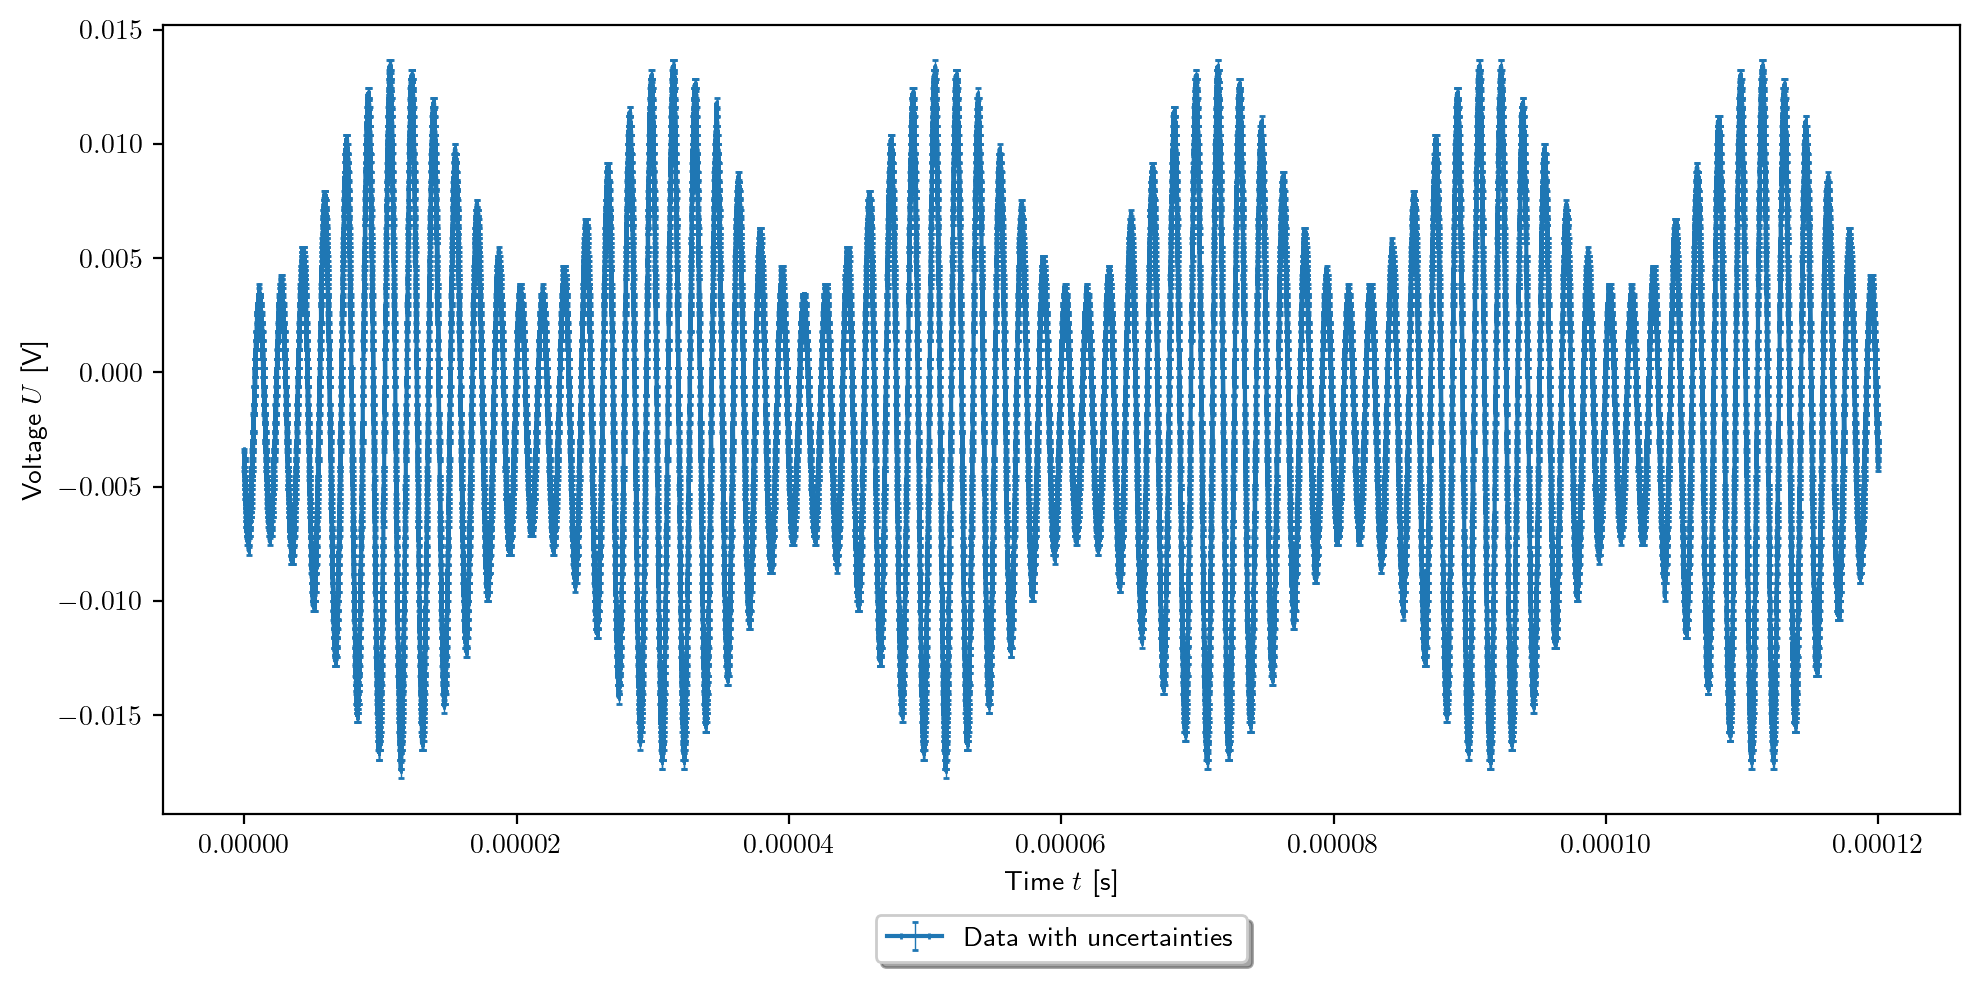

In [2]:
A1_50_V = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_07.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A1_50_V, header=None, skiprows=1, names=["time", "CH1"])
time = data["time"]
time = time - time[0]
ch1 = data["CH1"]
time_err = time * 50e-6      # 50 ppm absolute -> for error
ch1_err = 0.02 * np.abs(ch1) 

plt.figure(figsize=(10,5), dpi=200) #dpi used for better visability can be adjusted as well as the size of the figure

plt.errorbar(
    time,
    ch1,
    xerr=time_err,
    yerr=ch1_err,
    #fmt='-',
    markersize=1,
    elinewidth=0.5,
    capsize=1,
    label=r"Data with uncertainties"
)

plt.xlabel(r"Time $t$ [s]")
plt.ylabel(r"Voltage $U$ [V]")
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.11), fancybox=True, shadow=True, ncol=2)
plt.tight_layout()
plt.savefig("A1_50_V.pdf")
plt.show()

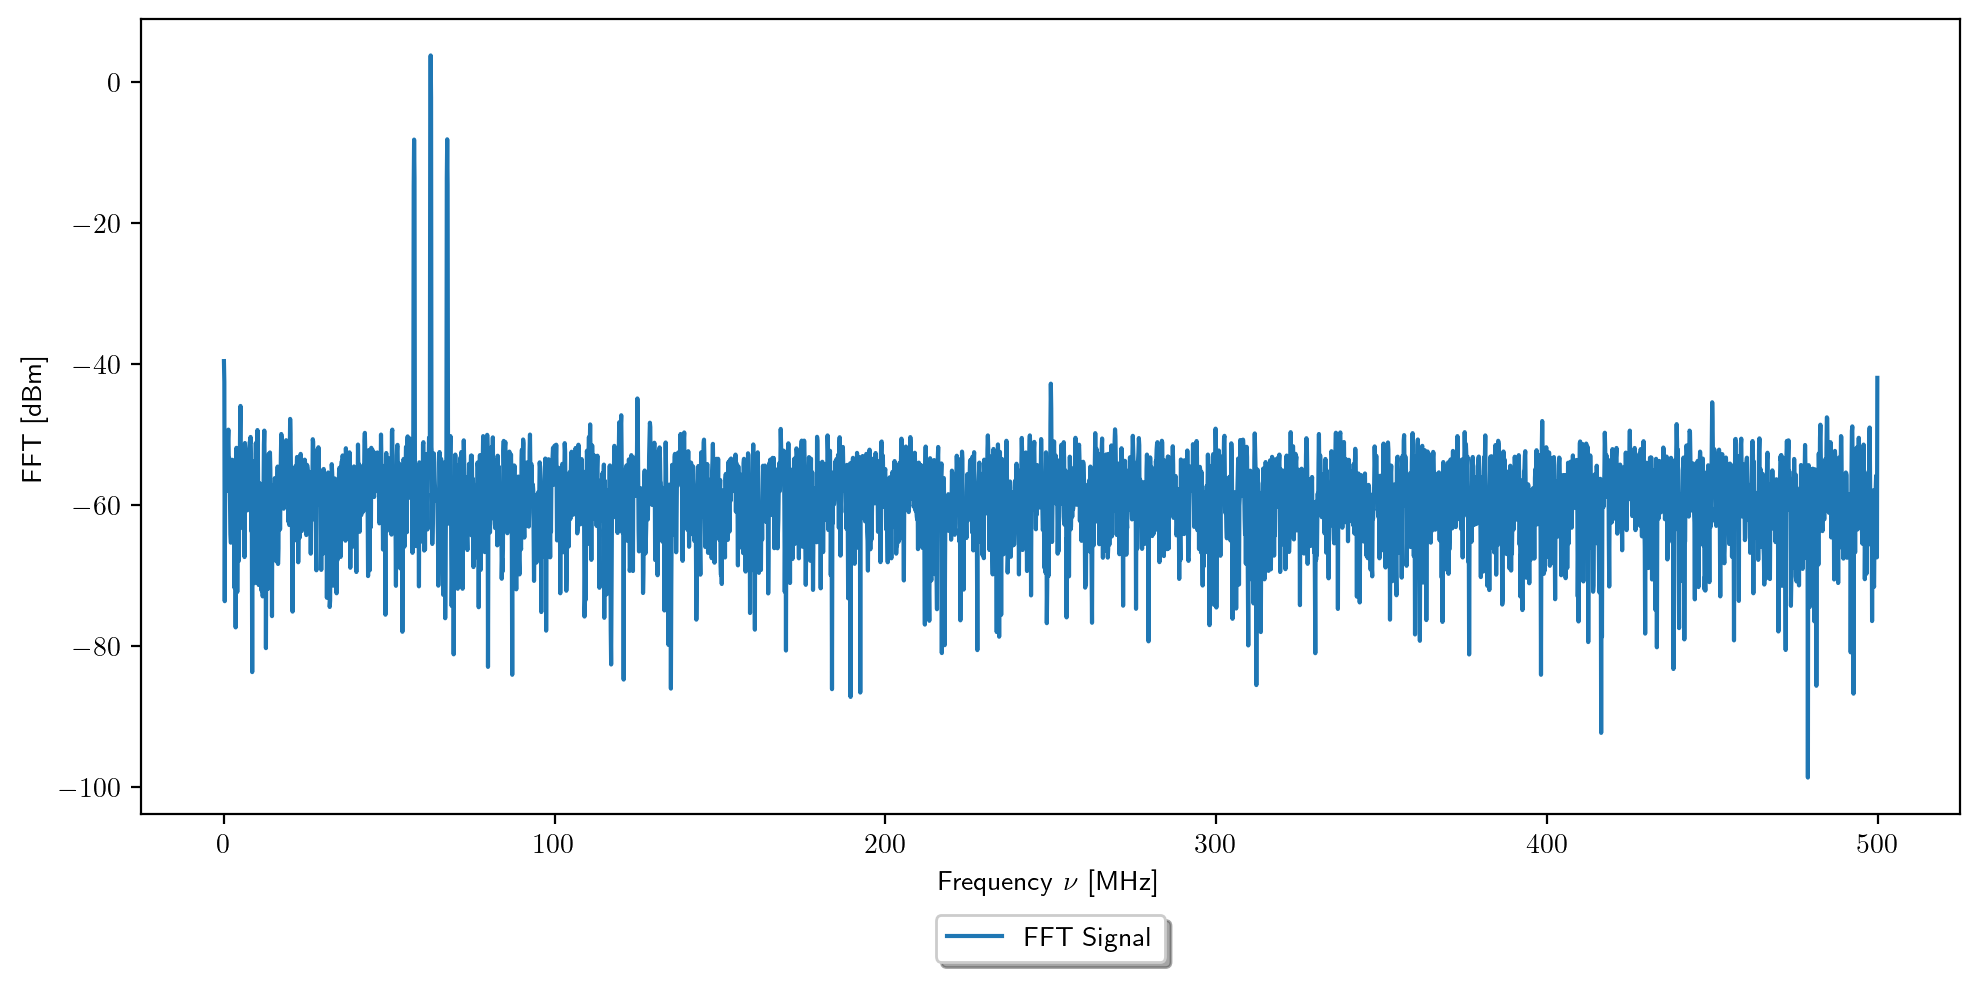

In [3]:
A1_50_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG01/FFT_05.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A1_50_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]
plt.figure(figsize=(10,5), dpi=200)

plt.plot(freq, ch1, label=r"FFT Signal")
plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.11), fancybox=True, shadow=True, ncol=2)
plt.tight_layout()
plt.savefig("A1_50_FFT.pdf")
plt.show()

### Fitting three different fit functions on the data to determine the best fit function: Voigt Lorentz and Gaussia fit function

### Investigate which function is the best -> Gaussian fit function

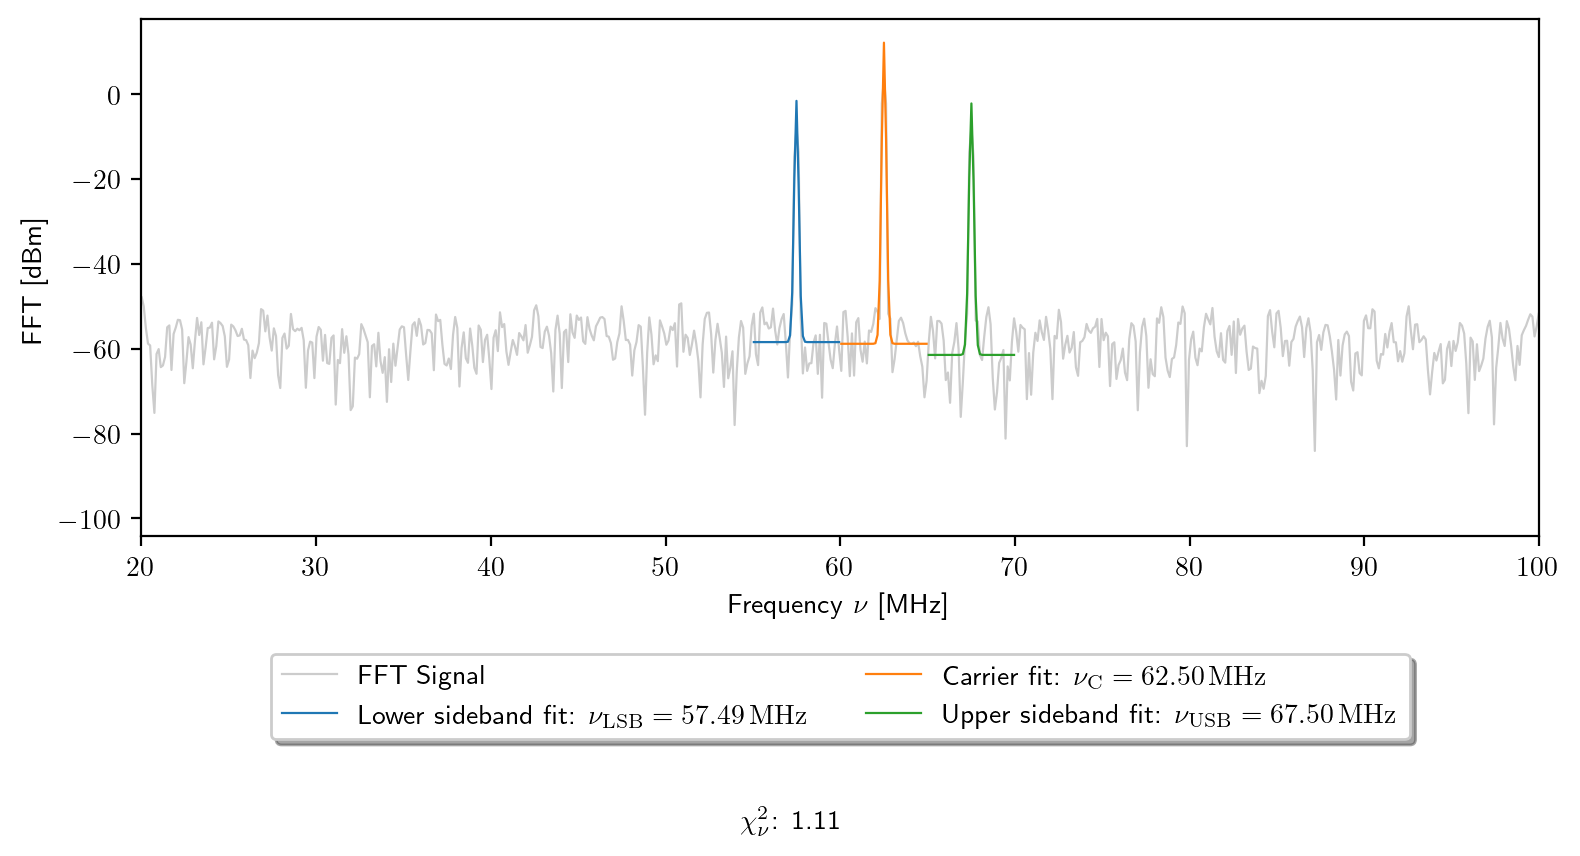

In [4]:
A1_50_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG01/FFT_05.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A1_50_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"].to_numpy()
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"].to_numpy()

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def lorentz(f, A, f0, gamma, C):
    return A / (1 + ((f - f0)/gamma)**2) + C

def voigt(f, A, f0, sigma, gamma, C):
    profile = voigt_profile(f - f0, sigma, gamma)
    profile /= np.max(profile)
    return A * profile + C

def fit_peak(freq, amp, fmin, fmax, model):
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, chi2_red

fmin_lower, fmax_lower = 55, 60
fmin_carrier, fmax_carrier = 60, 65
fmin_upper, fmax_upper = 65, 70


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l, func_l, popt_l, chi2_l = fit_peak(freq, ch1, fmin_lower, fmax_lower, "gauss")
f_c, func_c, popt_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u, func_u, popt_u, chi2_u = fit_peak(freq, ch1, fmin_upper, fmax_upper, "gauss")

plt.plot(f_l, func_l(f_l, *popt_l), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB}}}}={popt_l[1]:.2f}\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}={popt_c[1]:.2f}\,$$\mathrm{{MHz}}$")
plt.plot(f_u, func_u(f_u, *popt_u), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB}}}}={popt_u[1]:.2f}\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)

plt.figtext(
    0.5, -0.05,
    rf"$\chi^2_\nu$: {chi2_l:.2f}",
    ha="center"
)

plt.tight_layout()
plt.savefig("A1_50_FFT_Fit_Gauss.pdf", bbox_inches="tight")


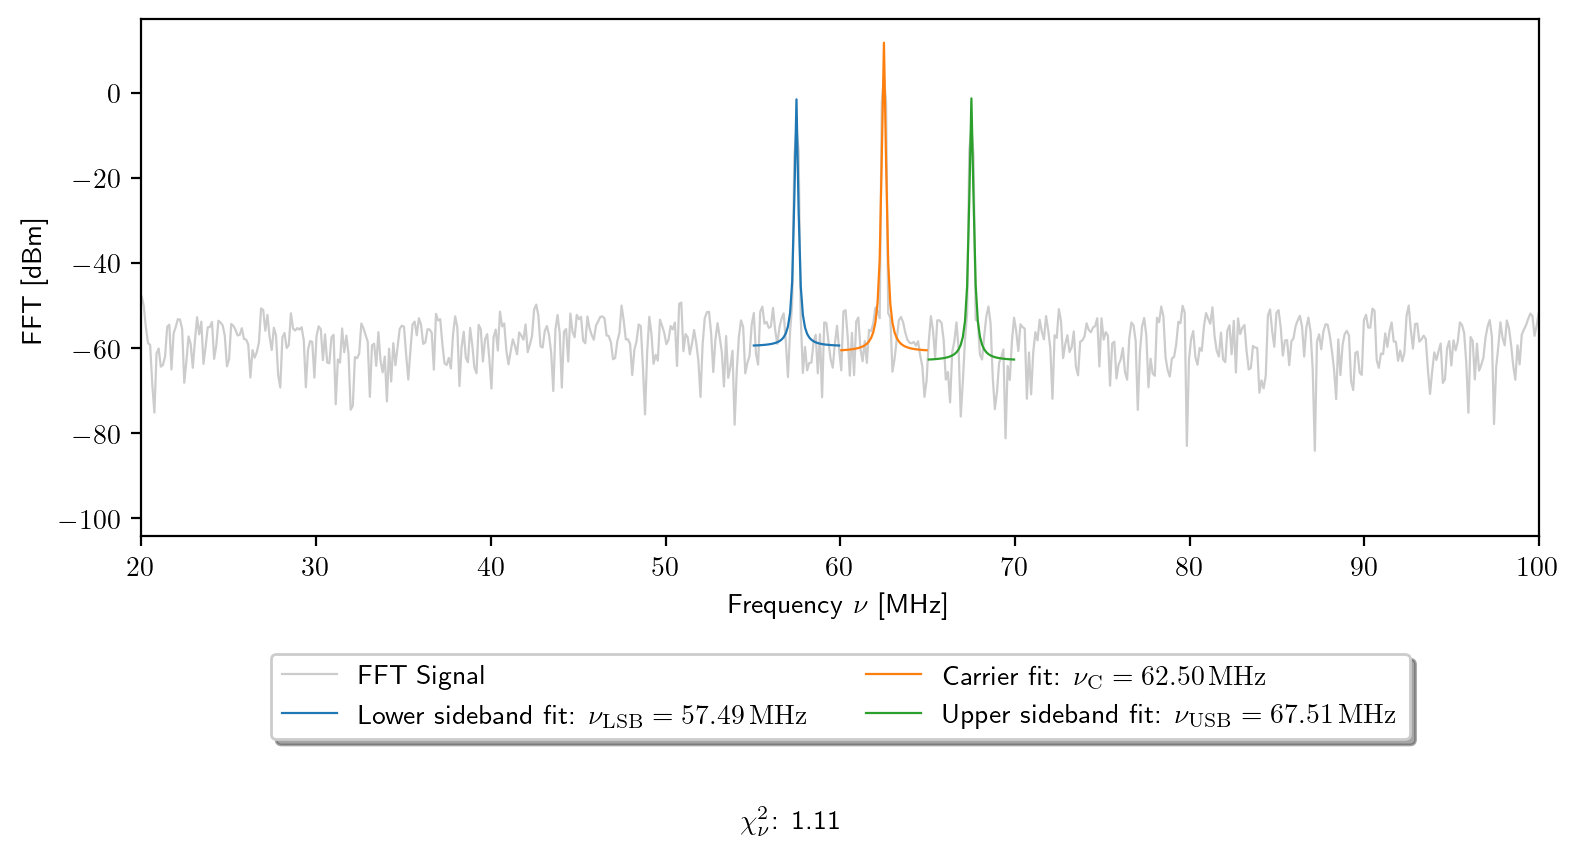

In [170]:
plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l, func_l, popt_l, chi2_l = fit_peak(freq, ch1, fmin_lower, fmax_lower, "lorentz")
f_c, func_c, popt_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "lorentz")
f_u, func_u, popt_u, chi2_u = fit_peak(freq, ch1, fmin_upper, fmax_upper, "lorentz")

plt.plot(f_l, func_l(f_l, *popt_l), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB}}}}={popt_l[1]:.2f}\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}={popt_c[1]:.2f}\,$$\mathrm{{MHz}}$")
plt.plot(f_u, func_u(f_u, *popt_u), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB}}}}={popt_u[1]:.2f}\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Lorentzian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)

plt.figtext(
    0.5, -0.05,
    rf"$\chi^2_\nu$: {chi2_l:.2f}",
    ha="center"
)
plt.tight_layout()
plt.savefig("A1_50_FFT_Fit_Lorentz.pdf", bbox_inches="tight")


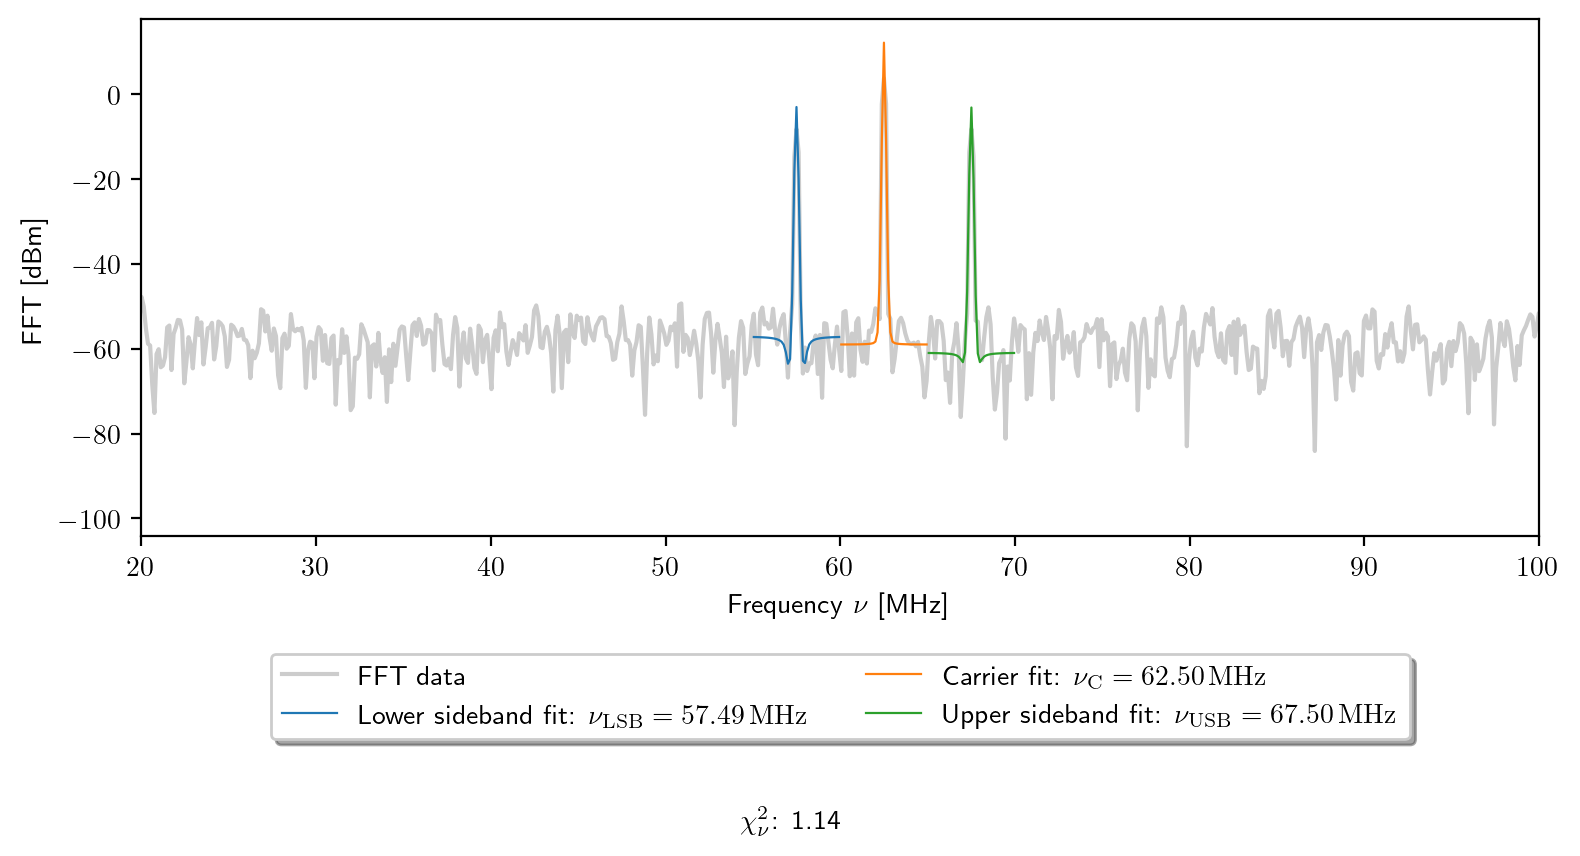

In [6]:
def fit_peak(freq, amp, fmin, fmax, model):
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5
    else:
        raise ValueError("Unknown model")

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=20000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit) / sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, chi2_red

f_l, func_l, popt_l, chi2_l = fit_peak(freq, ch1, fmin_lower, fmax_lower, "voigt")
f_c, func_c, popt_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "voigt")
f_u, func_u, popt_u, chi2_u = fit_peak(freq, ch1, fmin_upper, fmax_upper, "voigt")


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, label=r"FFT data")
plt.plot(f_l, func_l(f_l, *popt_l), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB}}}}={popt_l[1]:.2f}\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}={popt_c[1]:.2f}\,$$\mathrm{{MHz}}$")
plt.plot(f_u, func_u(f_u, *popt_u), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB}}}}={popt_u[1]:.2f}\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)

plt.figtext(
    0.5, -0.05,
    rf"$\chi^2_\nu$: {chi2_l:.2f}",
    ha="center"
)
plt.tight_layout()
plt.savefig("A1_50_FFT_Fit_Voigt.pdf", bbox_inches="tight")


### Analyizing the actual task and computing the modulation index

Peak amplitudes (from Gaussian fits):
LSB: P = -1.58 ± 4.90 dBm
C:   P = 12.12 ± 5.18 dBm
USB: P = -2.20 ± 6.36 dBm

Modulation index:
k_AM,obt1 (LSB) = 41.3 ± 33.9 %
k_AM,obt2 (USB) = 38.5 ± 36.3 %

Peak positions (Gaussian fit):
LSB: f0 = 57.4921 ± 0.0135 MHz
C:   f0 = 62.5005 ± 0.0116 MHz
USB: f0 = 67.5033 ± 0.0179 MHz

Modulation frequency:
fm (USB-C) = 5.0028 ± 0.0213 MHz
fm (C-LSB) = 5.0083 ± 0.0178 MHz
fm (sym)   = 5.0056 ± 0.0112 MHz


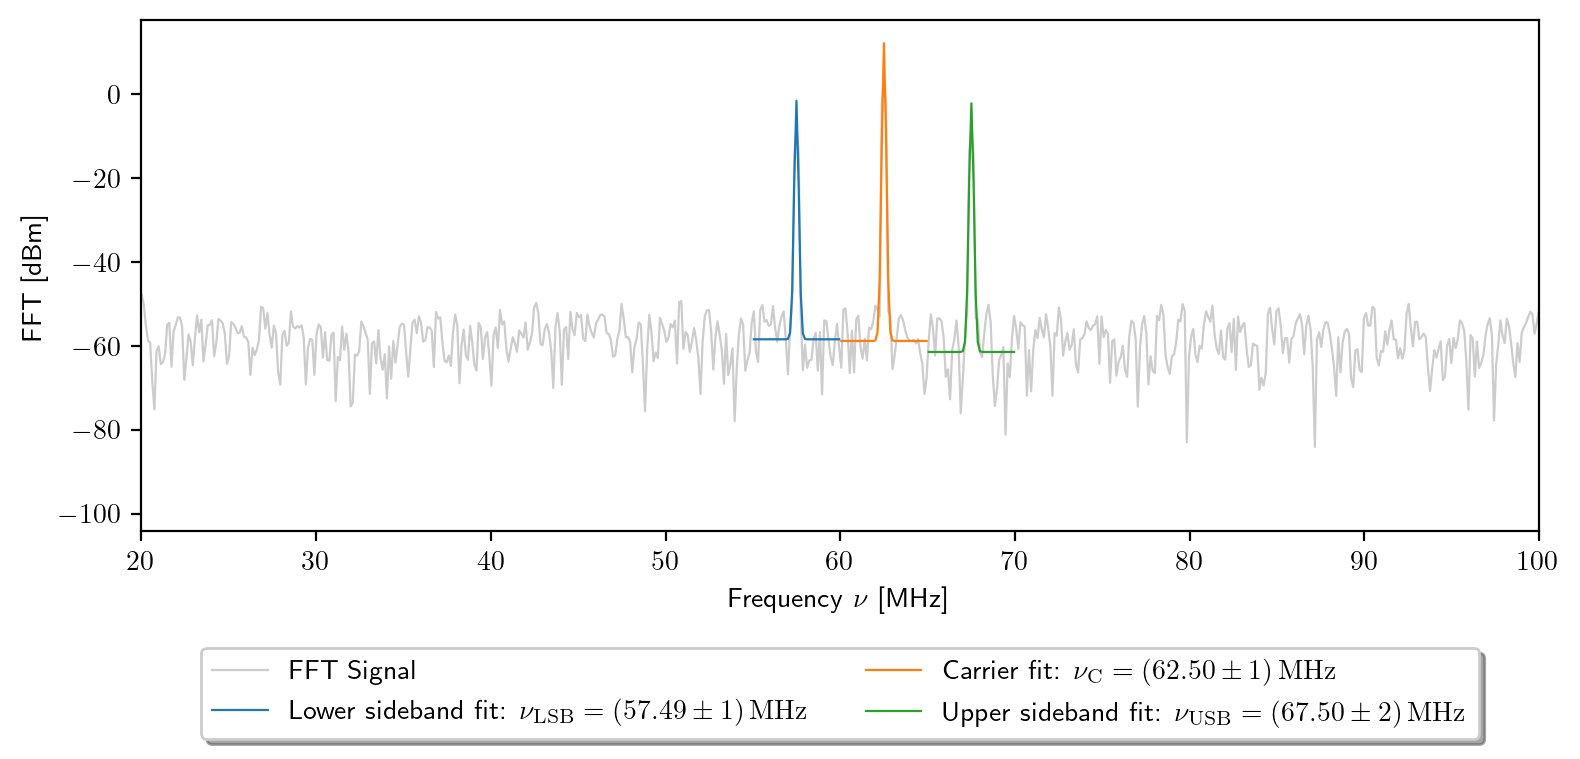

In [7]:
A1_50_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG01/FFT_05.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A1_50_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"].to_numpy()
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"].to_numpy()

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def lorentz(f, A, f0, gamma, C):
    return A / (1 + ((f - f0)/gamma)**2) + C

def voigt(f, A, f0, sigma, gamma, C):
    profile = voigt_profile(f - f0, sigma, gamma)
    profile /= np.max(profile)
    return A * profile + C

def fit_peak(freq, amp, fmin, fmax, model):
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower, fmax_lower = 55, 60
fmin_carrier, fmax_carrier = 60, 65
fmin_upper, fmax_upper = 65, 70

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l, func_l, popt_l, pcov_l, chi2_l = fit_peak(freq, ch1, fmin_lower, fmax_lower, "gauss")
f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u, func_u, popt_u, pcov_u, chi2_u = fit_peak(freq, ch1, fmin_upper, fmax_upper, "gauss")

plt.plot(f_l, func_l(f_l, *popt_l), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB}}}}=({popt_l[1]:.2f}\pm 1)\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm 1)\,$$\mathrm{{MHz}}$")
plt.plot(f_u, func_u(f_u, *popt_u), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB}}}}=({popt_u[1]:.2f}\pm 2)\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A1_50_FFT_final.pdf", bbox_inches="tight")

"""
Computation modulation index --------------------------------------------------------------
"""
P_LSB_dBm, sP_LSB_dBm = peak_dBm_and_sigma_from_gauss(popt_l, pcov_l)
P_C_dBm,   sP_C_dBm   = peak_dBm_and_sigma_from_gauss(popt_c, pcov_c)
P_USB_dBm, sP_USB_dBm = peak_dBm_and_sigma_from_gauss(popt_u, pcov_u)

# absolute peak heights in dBm 
A_LSB, sA_LSB = dBm_to_lin_and_sigma(P_LSB_dBm, sP_LSB_dBm)
A_C,   sA_C   = dBm_to_lin_and_sigma(P_C_dBm,   sP_C_dBm)
A_USB, sA_USB = dBm_to_lin_and_sigma(P_USB_dBm, sP_USB_dBm)

k_LSB, sk_LSB = kAM_and_sigma(A_LSB, sA_LSB, A_C, sA_C)
k_USB, sk_USB = kAM_and_sigma(A_USB, sA_USB, A_C, sA_C)


print("Peak amplitudes (from Gaussian fits):")
print(f"LSB: P = {P_LSB_dBm:.2f} ± {sP_LSB_dBm:.2f} dBm")
print(f"C:   P = {P_C_dBm:.2f} ± {sP_C_dBm:.2f} dBm")
print(f"USB: P = {P_USB_dBm:.2f} ± {sP_USB_dBm:.2f} dBm\n")

print("Modulation index:")
print(f"k_AM,obt1 (LSB) = {100*k_LSB:.1f} ± {100*sk_LSB:.1f} %")
print(f"k_AM,obt2 (USB) = {100*k_USB:.1f} ± {100*sk_USB:.1f} %")

# --- peak positions and uncertainties from covariance matrix ---
f0_LSB = popt_l[1]
sf0_LSB = np.sqrt(pcov_l[1,1])

f0_C = popt_c[1]
sf0_C = np.sqrt(pcov_c[1,1])

f0_USB = popt_u[1]
sf0_USB = np.sqrt(pcov_u[1,1])

print("\nPeak positions (Gaussian fit):")
print(f"LSB: f0 = {f0_LSB:.4f} ± {sf0_LSB:.4f} MHz")
print(f"C:   f0 = {f0_C:.4f} ± {sf0_C:.4f} MHz")
print(f"USB: f0 = {f0_USB:.4f} ± {sf0_USB:.4f} MHz")

fm_USB = f0_USB - f0_C
sfm_USB = np.sqrt(sf0_USB**2 + sf0_C**2)

fm_LSB = f0_C - f0_LSB
sfm_LSB = np.sqrt(sf0_C**2 + sf0_LSB**2)

fm_sym = (f0_USB - f0_LSB)/2
sfm_sym = 0.5 * np.sqrt(sf0_USB**2 + sf0_LSB**2)

print("\nModulation frequency:")
print(f"fm (USB-C) = {fm_USB:.4f} ± {sfm_USB:.4f} MHz")
print(f"fm (C-LSB) = {fm_LSB:.4f} ± {sfm_LSB:.4f} MHz")
print(f"fm (sym)   = {fm_sym:.4f} ± {sfm_sym:.4f} MHz")


### Modulation index 70 %

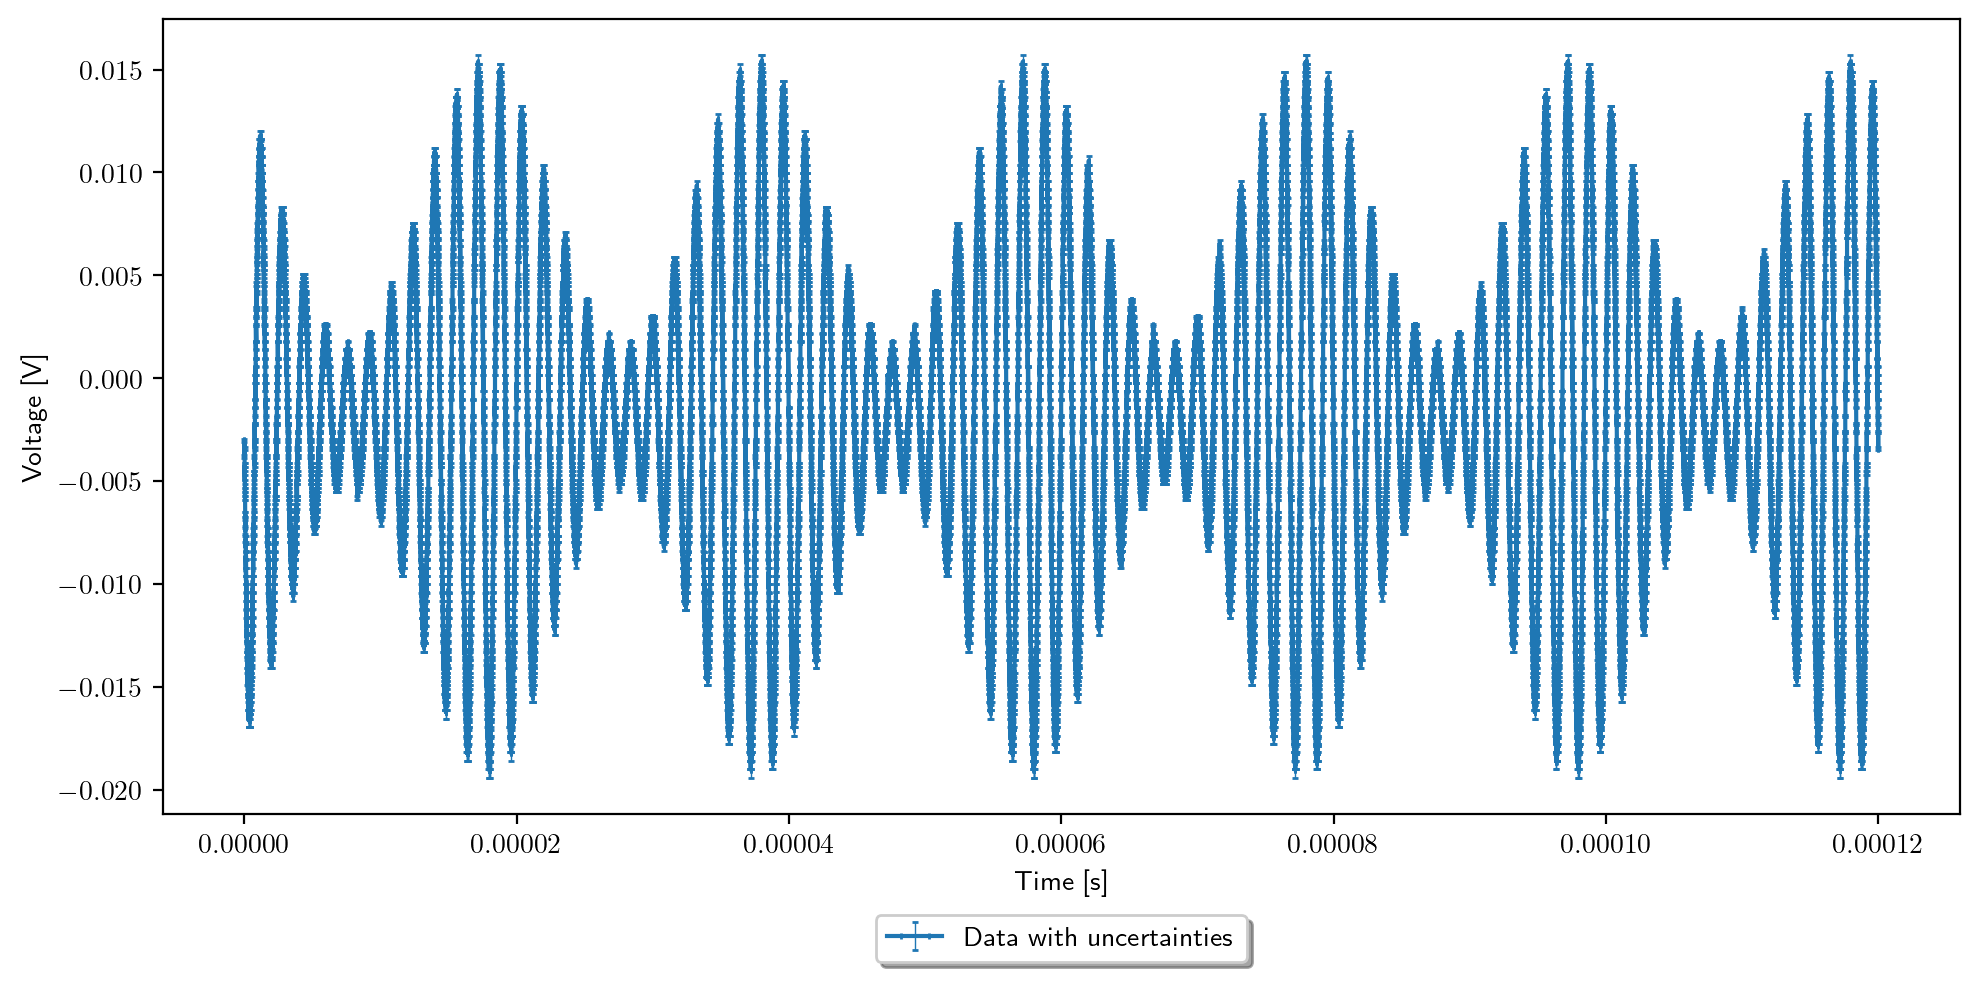

In [8]:
A1_70_V = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_08.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A1_70_V, header=None, skiprows=1, names=["time", "CH1"])
time = data["time"]
time = time - time[0]
ch1 = data["CH1"]
time_err = time * 50e-6      # 50 ppm absolute
ch1_err = 0.02 * np.abs(ch1) 
plt.figure(figsize=(10,5), dpi=200)



plt.errorbar(
    time,
    ch1,
    xerr=time_err,
    yerr=ch1_err,
    #fmt='-',
    markersize=1,
    elinewidth=0.5,
    capsize=1,
    label=r"Data with uncertainties"
)


plt.xlabel(r"Time [s]")
plt.ylabel(r"Voltage [V]")
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.11), fancybox=True, shadow=True, ncol=2)
plt.tight_layout()
plt.savefig("A1_70_V.pdf")
plt.show()

Peak amplitudes (from Gaussian fits):
LSB: P = 1.26 ± 6.21 dBm
C:   P = 13.90 ± 5.23 dBm
USB: P = 0.66 ± 4.34 dBm

Modulation index:
k_AM,obt1 (LSB) = 46.7 ± 43.6 %
k_AM,obt2 (USB) = 43.6 ± 34.1 %

Peak positions (Gaussian fit):
LSB: f0 = 57.5007 ± 0.0170 MHz
C:   f0 = 62.5025 ± 0.0107 MHz
USB: f0 = 67.4984 ± 0.0121 MHz

Modulation frequency:
fm (USB-C) = 4.9959 ± 0.0161 MHz
fm (C-LSB) = 5.0018 ± 0.0201 MHz
fm (sym)   = 4.9989 ± 0.0104 MHz


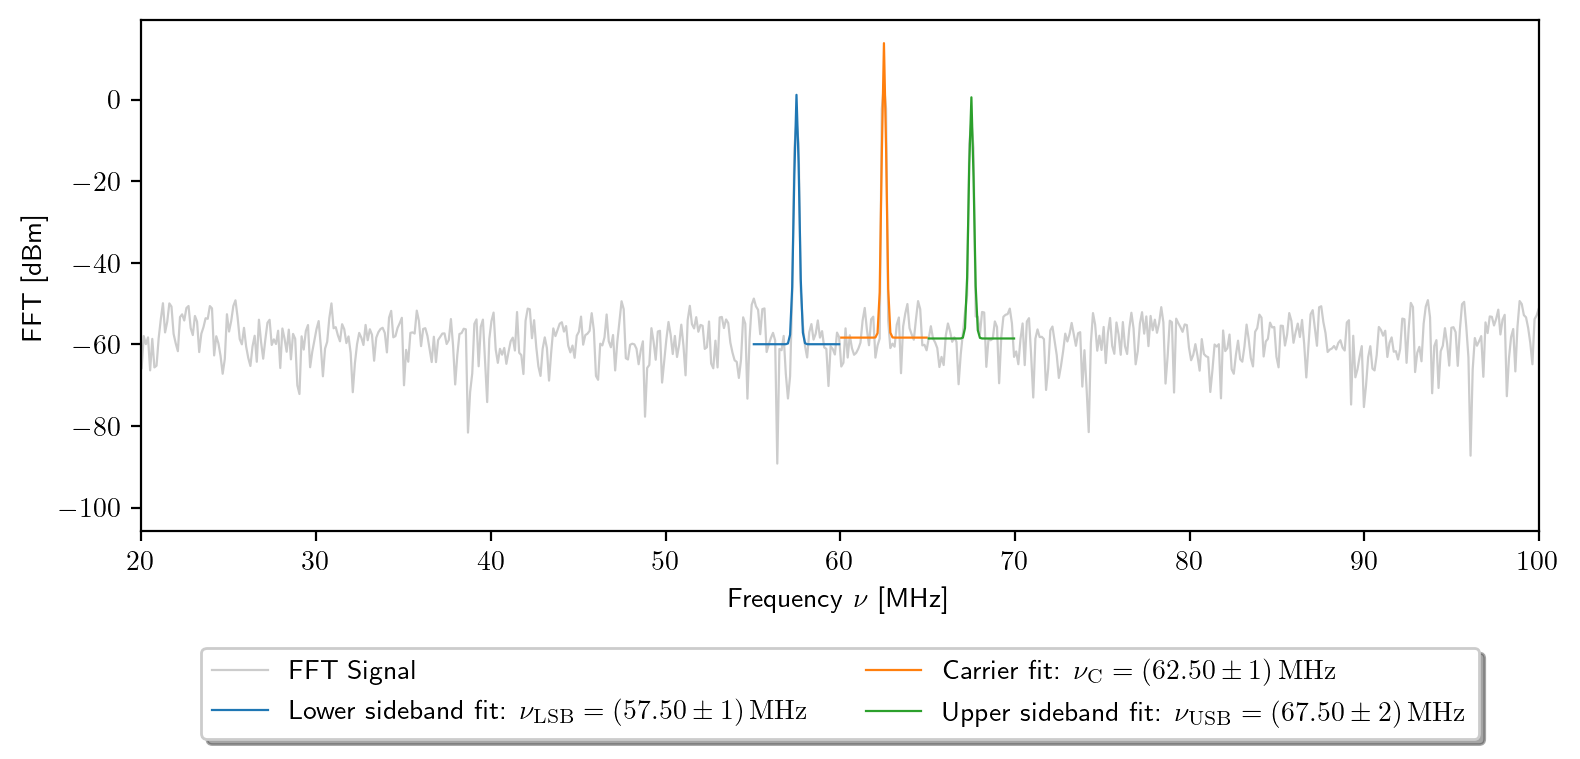

In [9]:
A1_70_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG01/FFT_07.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A1_70_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"].to_numpy()
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"].to_numpy()

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def lorentz(f, A, f0, gamma, C):
    return A / (1 + ((f - f0)/gamma)**2) + C

def voigt(f, A, f0, sigma, gamma, C):
    profile = voigt_profile(f - f0, sigma, gamma)
    profile /= np.max(profile)
    return A * profile + C

def fit_peak(freq, amp, fmin, fmax, model):
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower, fmax_lower = 55, 60
fmin_carrier, fmax_carrier = 60, 65
fmin_upper, fmax_upper = 65, 70

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l, func_l, popt_l, pcov_l, chi2_l = fit_peak(freq, ch1, fmin_lower, fmax_lower, "gauss")
f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u, func_u, popt_u, pcov_u, chi2_u = fit_peak(freq, ch1, fmin_upper, fmax_upper, "gauss")

plt.plot(f_l, func_l(f_l, *popt_l), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB}}}}=({popt_l[1]:.2f}\pm 1)\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm 1)\,$$\mathrm{{MHz}}$")
plt.plot(f_u, func_u(f_u, *popt_u), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB}}}}=({popt_u[1]:.2f}\pm 2)\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A1_70_FFT_final.pdf", bbox_inches="tight")

"""
computation modulation index --------------------------------------------------------------
"""
P_LSB_dBm, sP_LSB_dBm = peak_dBm_and_sigma_from_gauss(popt_l, pcov_l)
P_C_dBm,   sP_C_dBm   = peak_dBm_and_sigma_from_gauss(popt_c, pcov_c)
P_USB_dBm, sP_USB_dBm = peak_dBm_and_sigma_from_gauss(popt_u, pcov_u)

# absolute peak heights in dBm 
A_LSB, sA_LSB = dBm_to_lin_and_sigma(P_LSB_dBm, sP_LSB_dBm)
A_C,   sA_C   = dBm_to_lin_and_sigma(P_C_dBm,   sP_C_dBm)
A_USB, sA_USB = dBm_to_lin_and_sigma(P_USB_dBm, sP_USB_dBm)

k_LSB, sk_LSB = kAM_and_sigma(A_LSB, sA_LSB, A_C, sA_C)
k_USB, sk_USB = kAM_and_sigma(A_USB, sA_USB, A_C, sA_C)


print("Peak amplitudes (from Gaussian fits):")
print(f"LSB: P = {P_LSB_dBm:.2f} ± {sP_LSB_dBm:.2f} dBm")
print(f"C:   P = {P_C_dBm:.2f} ± {sP_C_dBm:.2f} dBm")
print(f"USB: P = {P_USB_dBm:.2f} ± {sP_USB_dBm:.2f} dBm\n")

print("Modulation index:")
print(f"k_AM,obt1 (LSB) = {100*k_LSB:.1f} ± {100*sk_LSB:.1f} %")
print(f"k_AM,obt2 (USB) = {100*k_USB:.1f} ± {100*sk_USB:.1f} %")

# --- peak positions and uncertainties from covariance matrix ---
f0_LSB = popt_l[1]
sf0_LSB = np.sqrt(pcov_l[1,1])

f0_C = popt_c[1]
sf0_C = np.sqrt(pcov_c[1,1])

f0_USB = popt_u[1]
sf0_USB = np.sqrt(pcov_u[1,1])

print("\nPeak positions (Gaussian fit):")
print(f"LSB: f0 = {f0_LSB:.4f} ± {sf0_LSB:.4f} MHz")
print(f"C:   f0 = {f0_C:.4f} ± {sf0_C:.4f} MHz")
print(f"USB: f0 = {f0_USB:.4f} ± {sf0_USB:.4f} MHz")

fm_USB = f0_USB - f0_C
sfm_USB = np.sqrt(sf0_USB**2 + sf0_C**2)

fm_LSB = f0_C - f0_LSB
sfm_LSB = np.sqrt(sf0_C**2 + sf0_LSB**2)

fm_sym = (f0_USB - f0_LSB)/2
sfm_sym = 0.5 * np.sqrt(sf0_USB**2 + sf0_LSB**2)

print("\nModulation frequency:")
print(f"fm (USB-C) = {fm_USB:.4f} ± {sfm_USB:.4f} MHz")
print(f"fm (C-LSB) = {fm_LSB:.4f} ± {sfm_LSB:.4f} MHz")
print(f"fm (sym)   = {fm_sym:.4f} ± {sfm_sym:.4f} MHz")


### Modulation Index = 100 %

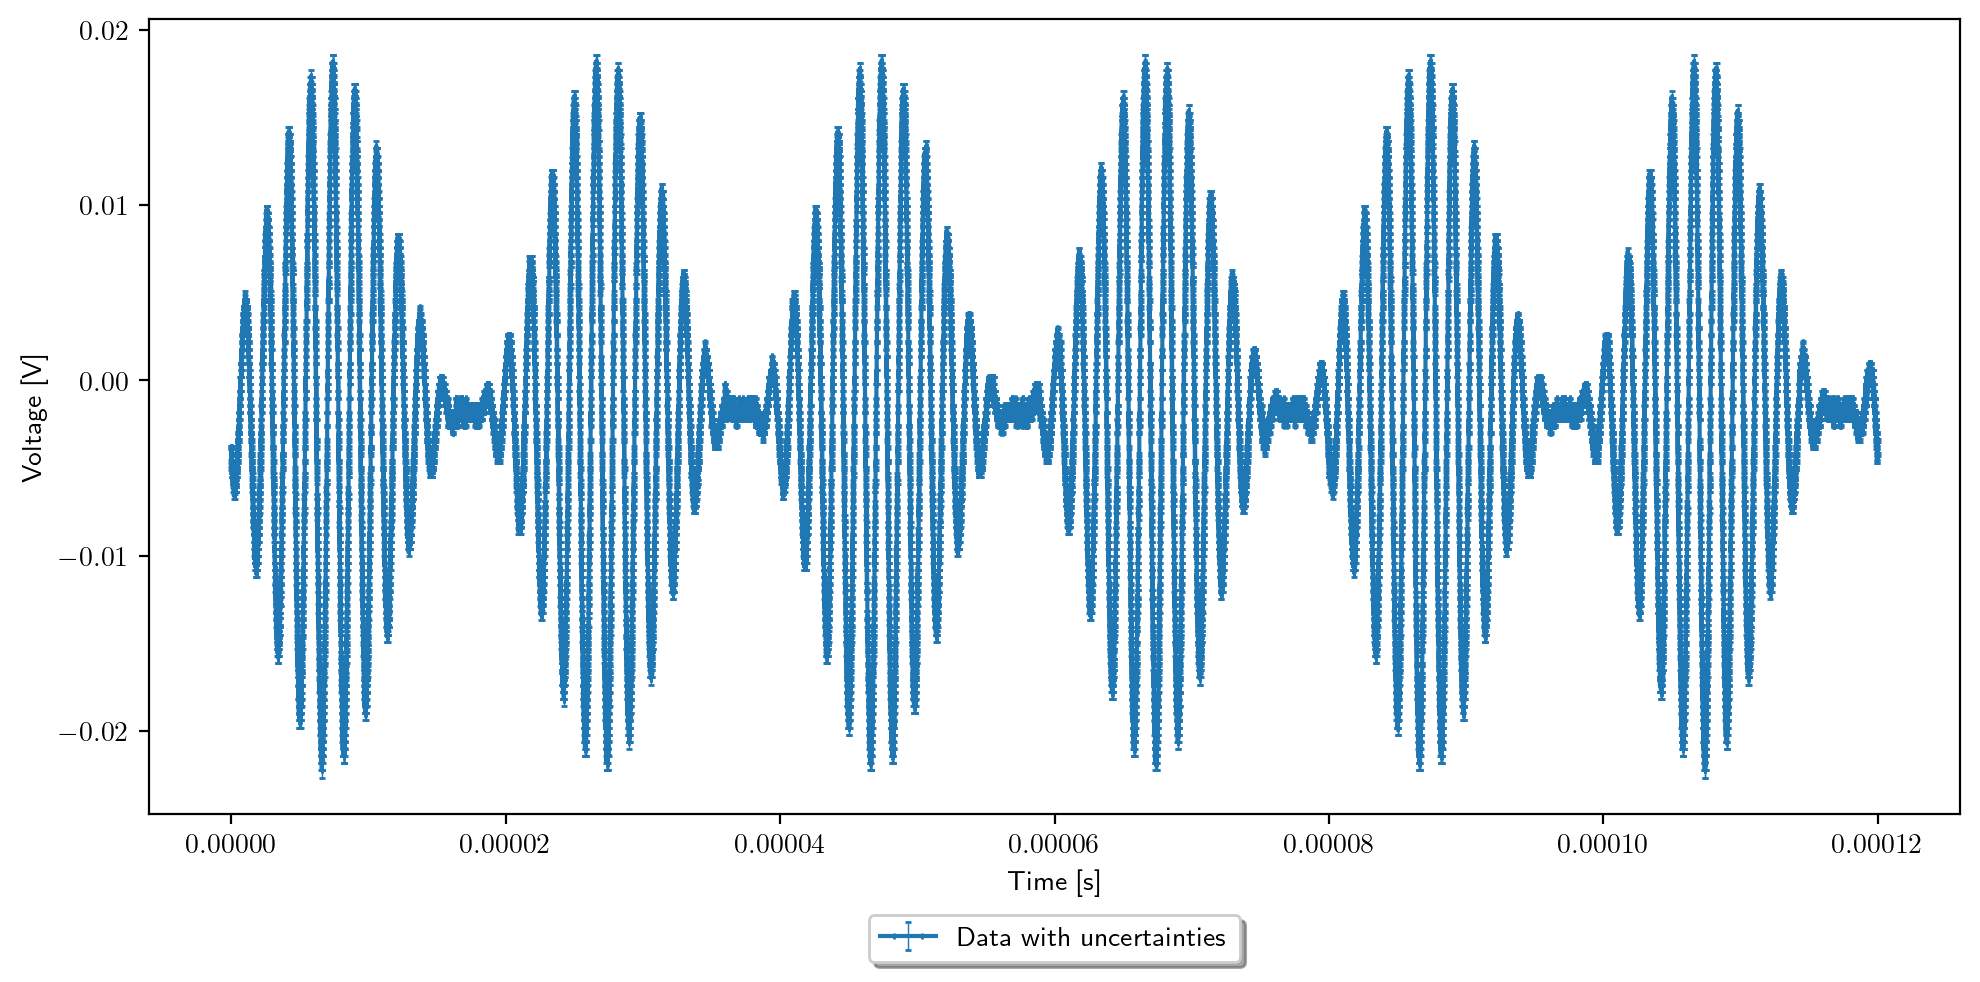

In [10]:
A1_100_V = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_09.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A1_100_V, header=None, skiprows=1, names=["time", "CH1"])
time = data["time"]
time = time - time[0]
ch1 = data["CH1"]
time_err = time * 50e-6      # 50 ppm absolute
ch1_err = 0.02 * np.abs(ch1) 
plt.figure(figsize=(10,5), dpi=200)



plt.errorbar(
    time,
    ch1,
    xerr=time_err,
    yerr=ch1_err,
    #fmt='-',
    markersize=1,
    elinewidth=0.5,
    capsize=1,
    label=r"Data with uncertainties"
)


plt.xlabel(r"Time [s]")
#plt.xlim(10000,2000000)
plt.ylabel(r"Voltage [V]")
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.11), fancybox=True, shadow=True, ncol=2)
plt.tight_layout()
plt.savefig("A1_100_V.pdf")
plt.show()

Peak amplitudes (from Gaussian fits):
LSB: P = 3.34 ± 4.63 dBm
C:   P = 14.18 ± 5.70 dBm
USB: P = 2.94 ± 4.41 dBm

Modulation index:
k_AM,obt1 (LSB) = 57.4 ± 48.5 %
k_AM,obt2 (USB) = 54.8 ± 45.5 %

Peak positions (Gaussian fit):
LSB: f0 = 57.4970 ± 0.0129 MHz
C:   f0 = 62.5025 ± 0.0114 MHz
USB: f0 = 67.5024 ± 0.0129 MHz

Modulation frequency:
fm (USB-C) = 4.9999 ± 0.0172 MHz
fm (C-LSB) = 5.0055 ± 0.0172 MHz
fm (sym)   = 5.0027 ± 0.0091 MHz


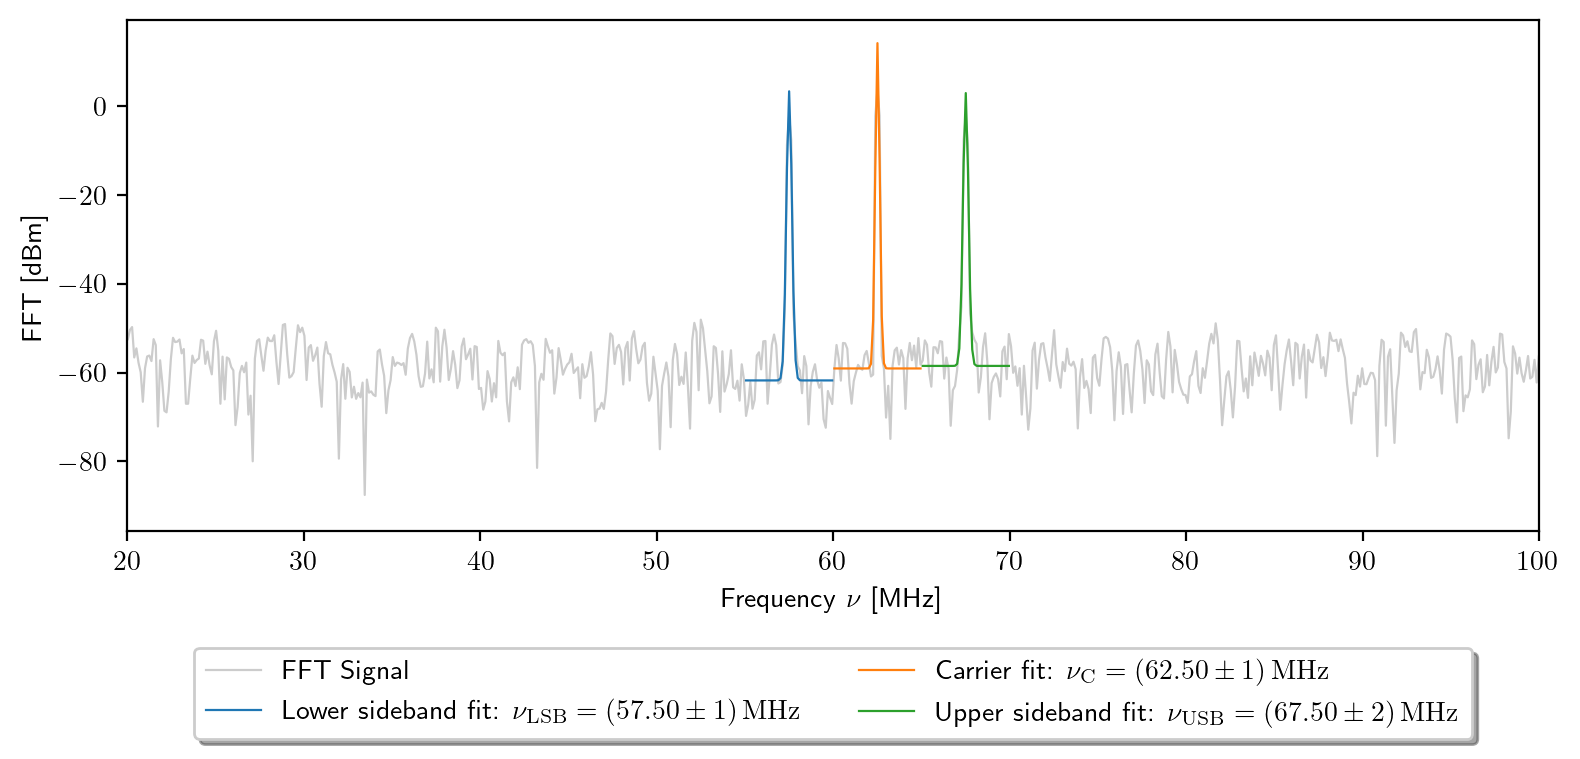

In [11]:
A1_100_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG01/FFT_10.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A1_100_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"].to_numpy()
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"].to_numpy()

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def lorentz(f, A, f0, gamma, C):
    return A / (1 + ((f - f0)/gamma)**2) + C

def voigt(f, A, f0, sigma, gamma, C):
    profile = voigt_profile(f - f0, sigma, gamma)
    profile /= np.max(profile)
    return A * profile + C

def fit_peak(freq, amp, fmin, fmax, model):
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower, fmax_lower = 55, 60
fmin_carrier, fmax_carrier = 60, 65
fmin_upper, fmax_upper = 65, 70

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l, func_l, popt_l, pcov_l, chi2_l = fit_peak(freq, ch1, fmin_lower, fmax_lower, "gauss")
f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u, func_u, popt_u, pcov_u, chi2_u = fit_peak(freq, ch1, fmin_upper, fmax_upper, "gauss")

plt.plot(f_l, func_l(f_l, *popt_l), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB}}}}=({popt_l[1]:.2f}\pm 1)\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm 1)\,$$\mathrm{{MHz}}$")
plt.plot(f_u, func_u(f_u, *popt_u), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB}}}}=({popt_u[1]:.2f}\pm 2)\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A1_100_FFT_final.pdf", bbox_inches="tight")

"""
compuataion of Modulations Index --------------------------------------------------------------
"""
P_LSB_dBm, sP_LSB_dBm = peak_dBm_and_sigma_from_gauss(popt_l, pcov_l)
P_C_dBm,   sP_C_dBm   = peak_dBm_and_sigma_from_gauss(popt_c, pcov_c)
P_USB_dBm, sP_USB_dBm = peak_dBm_and_sigma_from_gauss(popt_u, pcov_u)

# absolute peak heights in dBm 
A_LSB, sA_LSB = dBm_to_lin_and_sigma(P_LSB_dBm, sP_LSB_dBm)
A_C,   sA_C   = dBm_to_lin_and_sigma(P_C_dBm,   sP_C_dBm)
A_USB, sA_USB = dBm_to_lin_and_sigma(P_USB_dBm, sP_USB_dBm)

k_LSB, sk_LSB = kAM_and_sigma(A_LSB, sA_LSB, A_C, sA_C)
k_USB, sk_USB = kAM_and_sigma(A_USB, sA_USB, A_C, sA_C)


print("Peak amplitudes (from Gaussian fits):")
print(f"LSB: P = {P_LSB_dBm:.2f} ± {sP_LSB_dBm:.2f} dBm")
print(f"C:   P = {P_C_dBm:.2f} ± {sP_C_dBm:.2f} dBm")
print(f"USB: P = {P_USB_dBm:.2f} ± {sP_USB_dBm:.2f} dBm\n")

print("Modulation index:")
print(f"k_AM,obt1 (LSB) = {100*k_LSB:.1f} ± {100*sk_LSB:.1f} %")
print(f"k_AM,obt2 (USB) = {100*k_USB:.1f} ± {100*sk_USB:.1f} %")

# --- peak positions and uncertainties from covariance matrix ---
f0_LSB = popt_l[1]
sf0_LSB = np.sqrt(pcov_l[1,1])

f0_C = popt_c[1]
sf0_C = np.sqrt(pcov_c[1,1])

f0_USB = popt_u[1]
sf0_USB = np.sqrt(pcov_u[1,1])

print("\nPeak positions (Gaussian fit):")
print(f"LSB: f0 = {f0_LSB:.4f} ± {sf0_LSB:.4f} MHz")
print(f"C:   f0 = {f0_C:.4f} ± {sf0_C:.4f} MHz")
print(f"USB: f0 = {f0_USB:.4f} ± {sf0_USB:.4f} MHz")

fm_USB = f0_USB - f0_C
sfm_USB = np.sqrt(sf0_USB**2 + sf0_C**2)

fm_LSB = f0_C - f0_LSB
sfm_LSB = np.sqrt(sf0_C**2 + sf0_LSB**2)

fm_sym = (f0_USB - f0_LSB)/2
sfm_sym = 0.5 * np.sqrt(sf0_USB**2 + sf0_LSB**2)

print("\nModulation frequency:")
print(f"fm (USB-C) = {fm_USB:.4f} ± {sfm_USB:.4f} MHz")
print(f"fm (C-LSB) = {fm_LSB:.4f} ± {sfm_LSB:.4f} MHz")
print(f"fm (sym)   = {fm_sym:.4f} ± {sfm_sym:.4f} MHz")


## 2. Exercise: Frequency Modulation TIme Trace

Gefundene Peaks: 75 (Threshold > 0.018 V)
dt ~ 5.000e-09 s, min distance ~ 40 samples
Tmin = (1.180 ± 0.007) µs
Tmax = (2.400 ± 0.007) µs


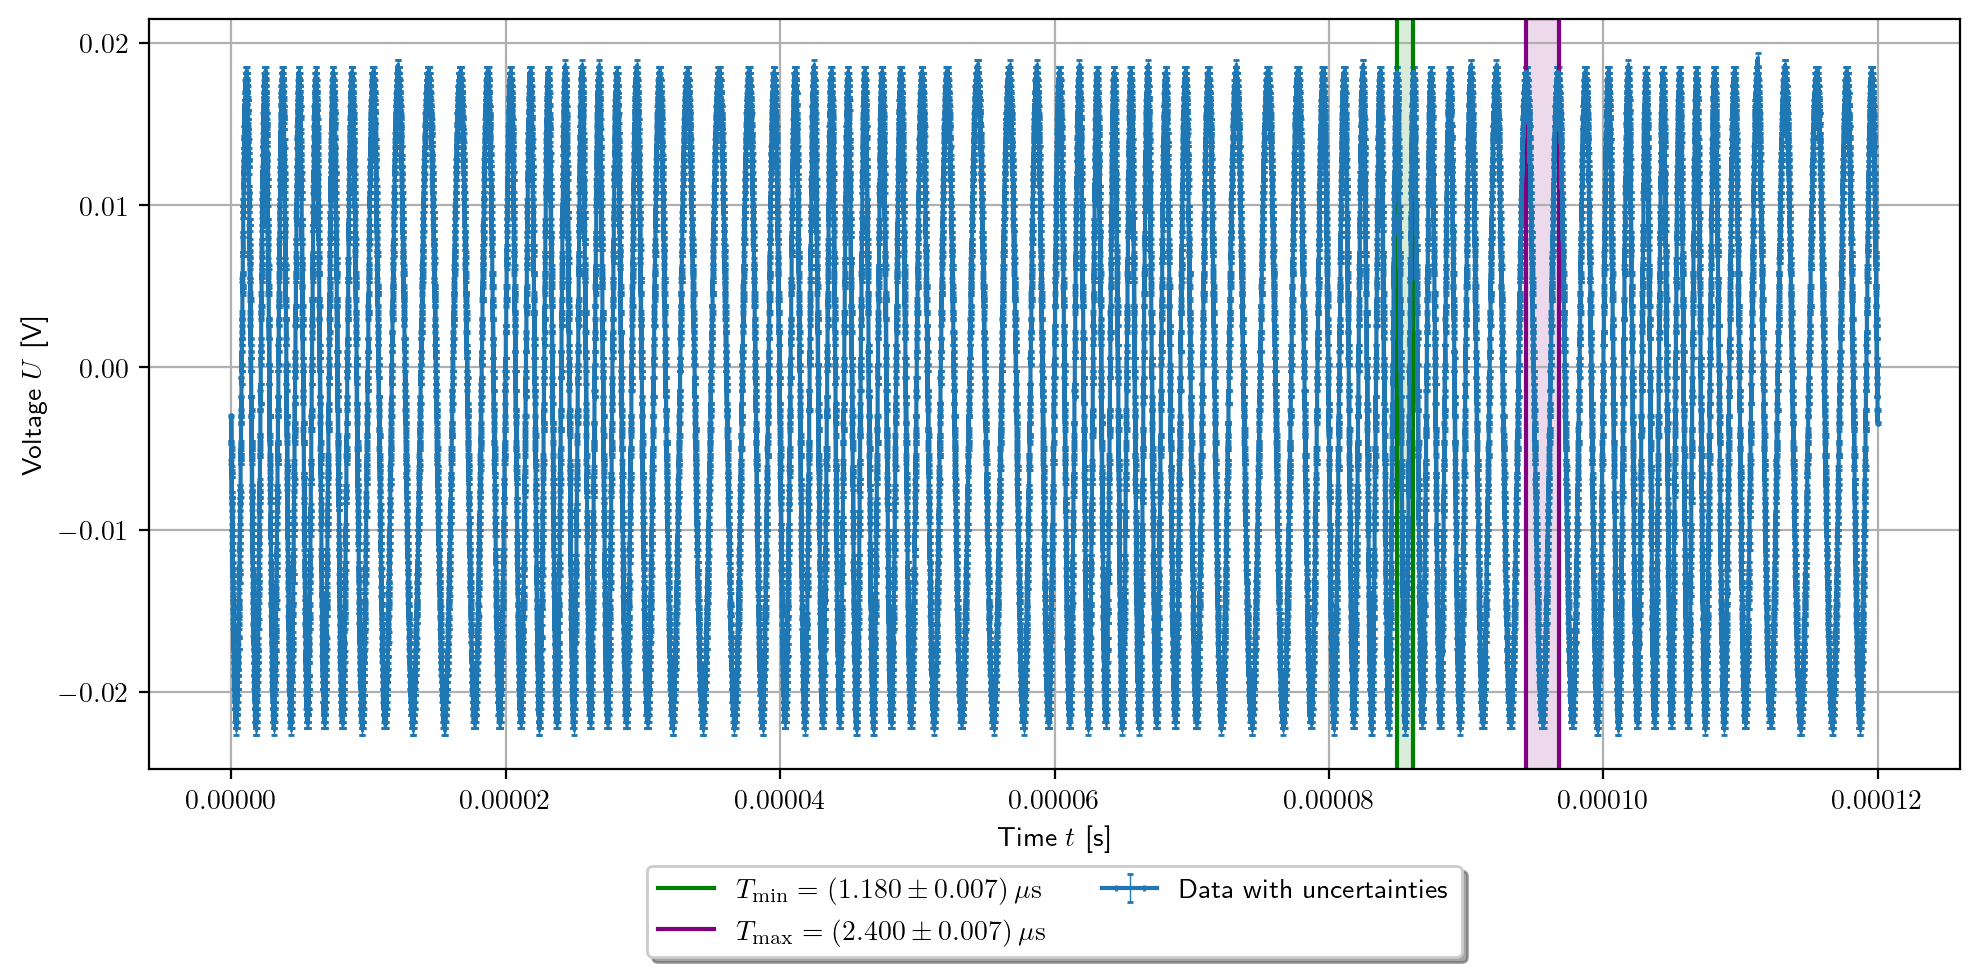

847457.6271186449
416666.66666666593


In [12]:
A2_V = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_10.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A2_V, header=None, skiprows=1, names=["time", "CH1"])
time = data["time"]
time = time - time[0]
ch1 = data["CH1"]
time_err = time * 50e-6      # 50 ppm absolute
ch1_err = 0.02 * np.abs(ch1) 
plt.figure(figsize=(10,5), dpi=200)

threshold = 0.018
dt = np.mean(np.diff(time))
min_peak_distance_seconds = 0.2e-6  # anpassen, falls nötig
min_peak_distance_samples = max(1, int(min_peak_distance_seconds / dt))

peaks, props = find_peaks(
    ch1,
    height=threshold,
    distance=min_peak_distance_samples
)

t_peaks = time[peaks].to_numpy()

print(f"Gefundene Peaks: {len(peaks)} (Threshold > {threshold} V)")
print(f"dt ~ {dt:.3e} s, min distance ~ {min_peak_distance_samples} samples")

# computing the periods
T = np.diff(t_peaks)               # time of periods
Tmin = np.min(T)
Tmax = np.max(T)

Tmin_us = Tmin * 1e6
Tmax_us = Tmax * 1e6


T_err = np.sqrt(2) * dt

print(f"Tmin = ({Tmin_us:.3f} ± {T_err*1e6:.3f}) µs")
print(f"Tmax = ({Tmax_us:.3f} ± {T_err*1e6:.3f}) µs")

idx_Tmin = np.argmin(T)
idx_Tmax = np.argmax(T)

# peak times
tmin_1 = t_peaks[idx_Tmin]
tmin_2 = t_peaks[idx_Tmin + 1]

tmax_1 = t_peaks[idx_Tmax]
tmax_2 = t_peaks[idx_Tmax + 1]


plt.errorbar(
    time,
    ch1,
    xerr=time_err,
    yerr=ch1_err,
    #fmt='-',
    markersize=1,
    elinewidth=0.5,
    capsize=1,
    label=r"Data with uncertainties"
)
#plt.plot(t_peaks, ch1.iloc[peaks], "r.", label="Detected peaks")
# --- Tmin ---
plt.axvline(tmin_1, color="green", linestyle="-", linewidth=1.5, label=r"$T_{\mathrm{min}}=(1.180\pm0.007)\:\mathrm{\mu s}$")
plt.axvline(tmin_2, color="green", linestyle="-", linewidth=1.5)

# --- Tmax ---
plt.axvline(tmax_1, color="purple", linestyle="-", linewidth=1.5, label=r"$T_{\mathrm{max}}=(2.400\pm 0.007)\:\mathrm{\mu s}$")
plt.axvline(tmax_2, color="purple", linestyle="-", linewidth=1.5)
plt.axvspan(tmin_1, tmin_2, color="green", alpha=0.15)
plt.axvspan(tmax_1, tmax_2, color="purple", alpha=0.15)

plt.xlabel(r"Time $t$ [s]")
#plt.xlim(10000,2000000)
plt.ylabel(r"Voltage $U$ [V]")
#plt.xlim(0.2,1*10e5)#,2*10e5)
#plt.title("Signalverlauf")
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.11), fancybox=True, shadow=True, ncol=2)
plt.tight_layout()
plt.savefig("A2_V.pdf")
plt.show()

f_max = 1 / Tmin
f_min = 1 / Tmax

# error propagation
f_max_err = T_err / Tmin**2
f_min_err = T_err / Tmax**2
print(f_max)
print(f_min)

## 3. Exercise: Frequency Modulation FFTs for different Modulation Indices

### Modulation index = 1, Number of Sidebands = 2 (k_FM + 1) = 4 -> fitting 5 peaks

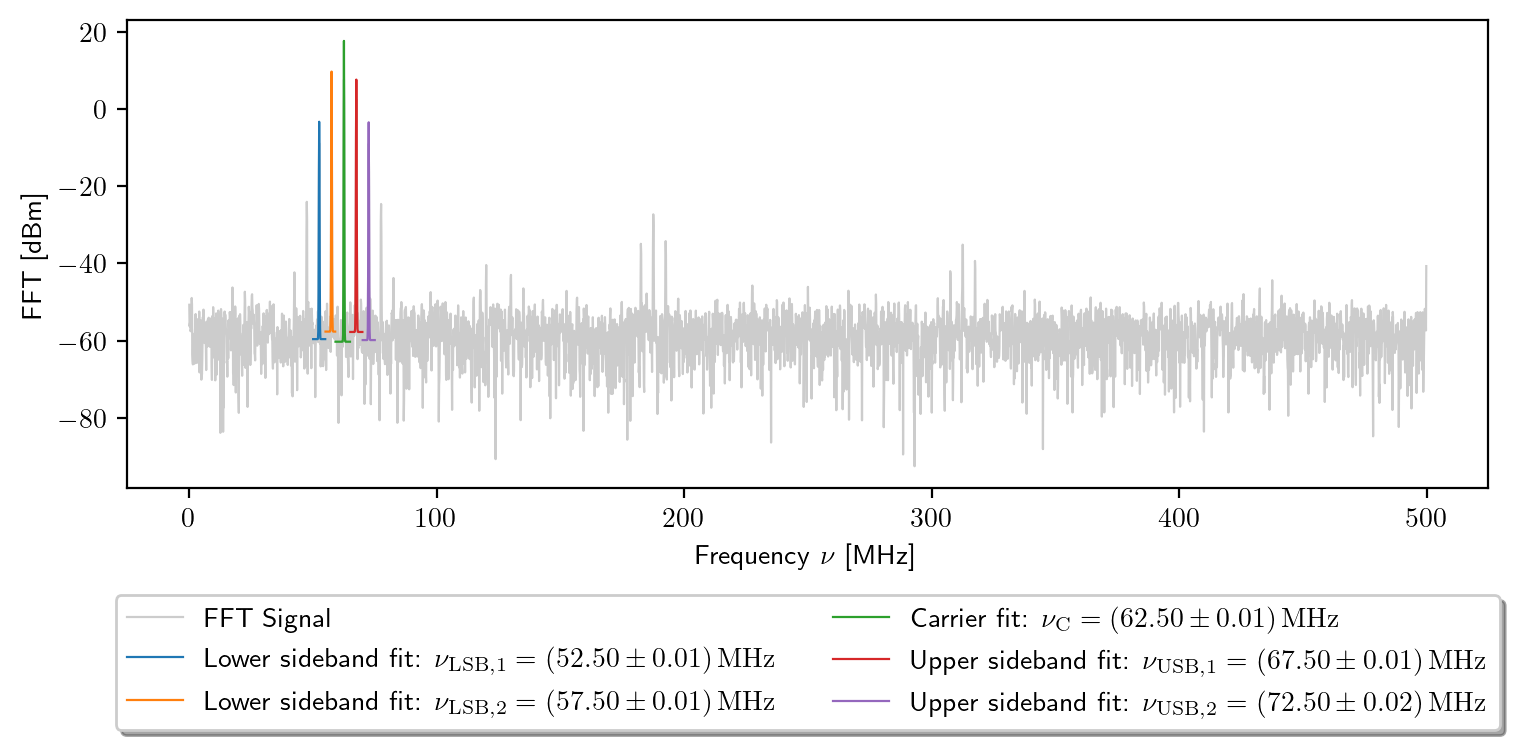

In [13]:
A3_50_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_11.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_50_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]


def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower_1, fmax_lower_1 = 50, 55
fmin_lower_2, fmax_lower_2 = 55, 59
fmin_carrier, fmax_carrier = 59, 65
fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")

plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
#plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A3_50_FFT.pdf", bbox_inches="tight")


### Modulation Index = 40/50=0.8 -> Sidebands = 2 (k_FM +1 ) approx 5 bands 

kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean
0.8  1  0.4358  0.309(0.276)  0.267(0.233)  0.288(0.180)
0.8  2  0.0896  0.046(0.041)  0.041(0.039)  0.044(0.029)


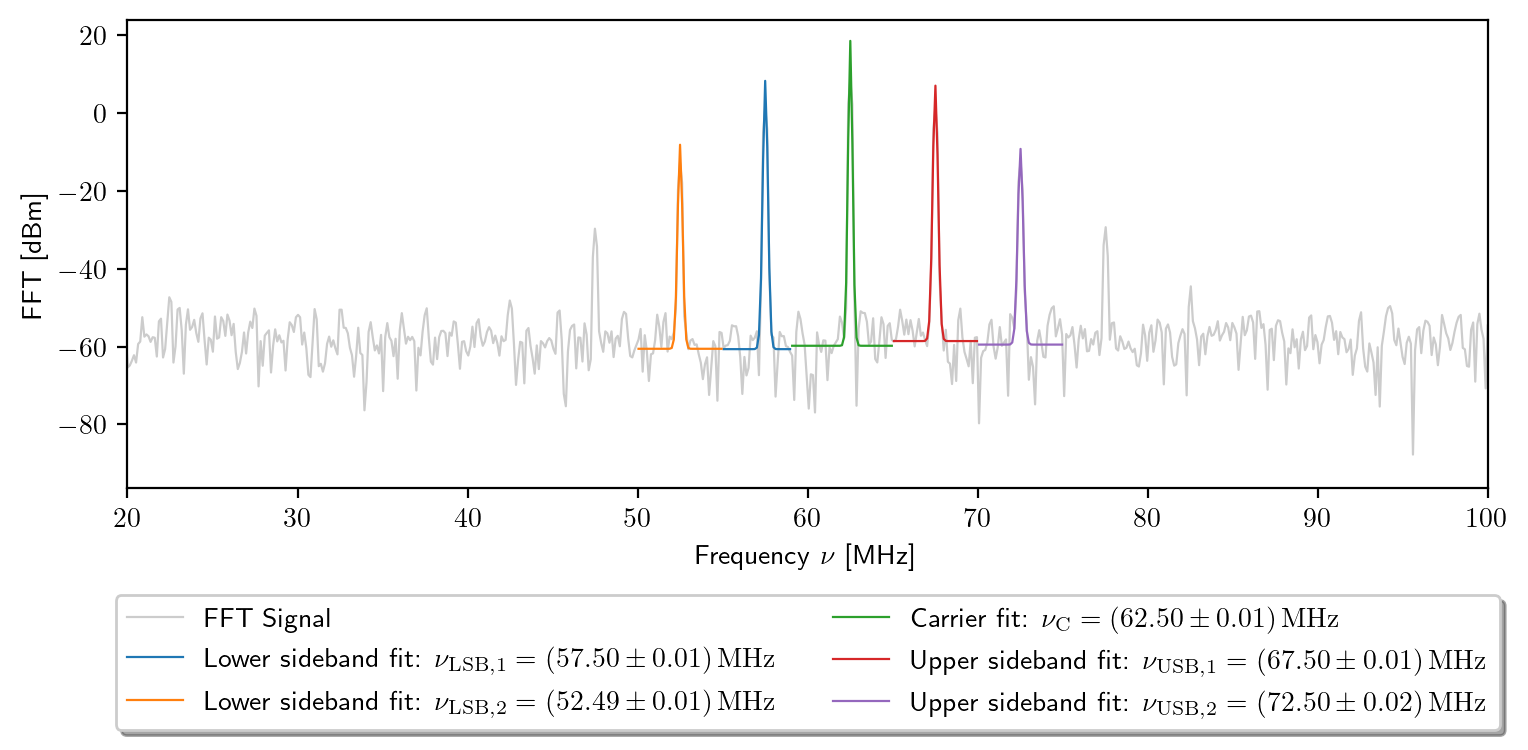

In [14]:
A3_40_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_12.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_40_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower_2, fmax_lower_2 = 50, 55
fmin_lower_1, fmax_lower_1 = 55, 59
fmin_carrier, fmax_carrier = 59, 65
fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")

plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A3_40_FFT.pdf", bbox_inches="tight")


from scipy.special import jv

kFM = 0.8

A_theo_1 = jv(1, kFM) / jv(0, kFM)
A_theo_2 = jv(2, kFM) / jv(0, kFM)

# Peak amplitudes
P_LSB1, sP_LSB1 = peak_dBm_and_sigma_from_gauss(popt_l_1, pcov_l_1)
P_C,    sP_C    = peak_dBm_and_sigma_from_gauss(popt_c,   pcov_c)
P_USB1, sP_USB1 = peak_dBm_and_sigma_from_gauss(popt_u_1, pcov_u_1)

# dBm -> linear
A_LSB1, sA_LSB1 = dBm_to_lin_and_sigma(P_LSB1, sP_LSB1)
A_C,    sA_C    = dBm_to_lin_and_sigma(P_C,    sP_C)
A_USB1, sA_USB1 = dBm_to_lin_and_sigma(P_USB1, sP_USB1)

# relative amplitudes
Arel_LSB1 = A_LSB1 / A_C
Arel_USB1 = A_USB1 / A_C
Arel_mean_1 = 0.5 * (Arel_LSB1 + Arel_USB1)

# errors
sArel_LSB1 = Arel_LSB1 * np.sqrt((sA_LSB1/A_LSB1)**2 + (sA_C/A_C)**2)
sArel_USB1 = Arel_USB1 * np.sqrt((sA_USB1/A_USB1)**2 + (sA_C/A_C)**2)
sArel_mean_1 = 0.5 * np.sqrt(sArel_LSB1**2 + sArel_USB1**2)

P_LSB2, sP_LSB2 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_USB2, sP_USB2 = peak_dBm_and_sigma_from_gauss(popt_u_2, pcov_u_2)

A_LSB2, sA_LSB2 = dBm_to_lin_and_sigma(P_LSB2, sP_LSB2)
A_USB2, sA_USB2 = dBm_to_lin_and_sigma(P_USB2, sP_USB2)

Arel_LSB2 = A_LSB2 / A_C
Arel_USB2 = A_USB2 / A_C
Arel_mean_2 = 0.5 * (Arel_LSB2 + Arel_USB2)

sArel_LSB2 = Arel_LSB2 * np.sqrt((sA_LSB2/A_LSB2)**2 + (sA_C/A_C)**2)
sArel_USB2 = Arel_USB2 * np.sqrt((sA_USB2/A_USB2)**2 + (sA_C/A_C)**2)
sArel_mean_2 = 0.5 * np.sqrt(sArel_LSB2**2 + sArel_USB2**2)

print("kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean")

print(f"{kFM:.1f}  1  "
      f"{A_theo_1:.4f}  "
      f"{Arel_LSB1:.3f}({sArel_LSB1:.3f})  "
      f"{Arel_USB1:.3f}({sArel_USB1:.3f})  "
      f"{Arel_mean_1:.3f}({sArel_mean_1:.3f})")

print(f"{kFM:.1f}  2  "
      f"{A_theo_2:.4f}  "
      f"{Arel_LSB2:.3f}({sArel_LSB2:.3f})  "
      f"{Arel_USB2:.3f}({sArel_USB2:.3f})  "
      f"{Arel_mean_2:.3f}({sArel_mean_2:.3f})")



### Modulation Index = 20/50=0.4 -> Sidebands = 2 (k_FM +1 ) approx 3 bands 

kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean
0.4  1  0.2041  0.105(0.102)  0.114(0.104)  0.109(0.073)
0.4  2  0.0205  0.009(0.009)  0.009(0.009)  0.009(0.006)


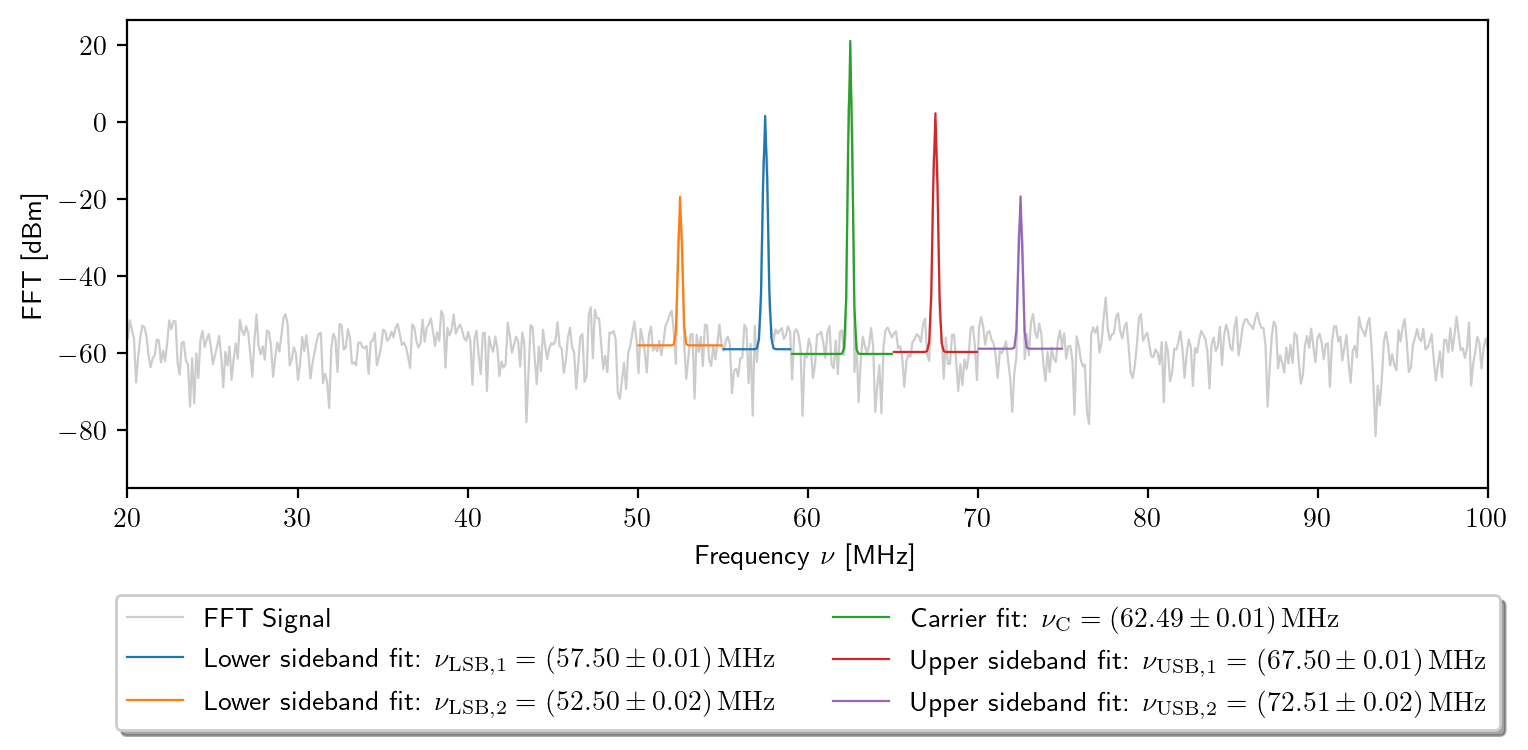

In [15]:
A3_20_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_14.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_20_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]
#freq_err = freq * 50e-6      # 50 ppm absolute
#ch1_err = 0.02 * np.abs(ch1) 

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower_2, fmax_lower_2 = 50, 55
fmin_lower_1, fmax_lower_1 = 55, 59
fmin_carrier, fmax_carrier = 59, 65
fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")

plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A3_20_FFT.pdf", bbox_inches="tight")


from scipy.special import jv

kFM = 0.4

A_theo_1 = jv(1, kFM) / jv(0, kFM)
A_theo_2 = jv(2, kFM) / jv(0, kFM)

# Peak amplitudes
P_LSB1, sP_LSB1 = peak_dBm_and_sigma_from_gauss(popt_l_1, pcov_l_1)
P_C,    sP_C    = peak_dBm_and_sigma_from_gauss(popt_c,   pcov_c)
P_USB1, sP_USB1 = peak_dBm_and_sigma_from_gauss(popt_u_1, pcov_u_1)

# dBm -> linear
A_LSB1, sA_LSB1 = dBm_to_lin_and_sigma(P_LSB1, sP_LSB1)
A_C,    sA_C    = dBm_to_lin_and_sigma(P_C,    sP_C)
A_USB1, sA_USB1 = dBm_to_lin_and_sigma(P_USB1, sP_USB1)

# relative amplitudes
Arel_LSB1 = A_LSB1 / A_C
Arel_USB1 = A_USB1 / A_C
Arel_mean_1 = 0.5 * (Arel_LSB1 + Arel_USB1)

# errors
sArel_LSB1 = Arel_LSB1 * np.sqrt((sA_LSB1/A_LSB1)**2 + (sA_C/A_C)**2)
sArel_USB1 = Arel_USB1 * np.sqrt((sA_USB1/A_USB1)**2 + (sA_C/A_C)**2)
sArel_mean_1 = 0.5 * np.sqrt(sArel_LSB1**2 + sArel_USB1**2)

P_LSB2, sP_LSB2 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_USB2, sP_USB2 = peak_dBm_and_sigma_from_gauss(popt_u_2, pcov_u_2)

A_LSB2, sA_LSB2 = dBm_to_lin_and_sigma(P_LSB2, sP_LSB2)
A_USB2, sA_USB2 = dBm_to_lin_and_sigma(P_USB2, sP_USB2)

Arel_LSB2 = A_LSB2 / A_C
Arel_USB2 = A_USB2 / A_C
Arel_mean_2 = 0.5 * (Arel_LSB2 + Arel_USB2)

sArel_LSB2 = Arel_LSB2 * np.sqrt((sA_LSB2/A_LSB2)**2 + (sA_C/A_C)**2)
sArel_USB2 = Arel_USB2 * np.sqrt((sA_USB2/A_USB2)**2 + (sA_C/A_C)**2)
sArel_mean_2 = 0.5 * np.sqrt(sArel_LSB2**2 + sArel_USB2**2)

print("kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean")

print(f"{kFM:.1f}  1  "
      f"{A_theo_1:.4f}  "
      f"{Arel_LSB1:.3f}({sArel_LSB1:.3f})  "
      f"{Arel_USB1:.3f}({sArel_USB1:.3f})  "
      f"{Arel_mean_1:.3f}({sArel_mean_1:.3f})")

print(f"{kFM:.1f}  2  "
      f"{A_theo_2:.4f}  "
      f"{Arel_LSB2:.3f}({sArel_LSB2:.3f})  "
      f"{Arel_USB2:.3f}({sArel_USB2:.3f})  "
      f"{Arel_mean_2:.3f}({sArel_mean_2:.3f})")



### Modulation Index = 100/50=2 -> Sidebands = 2 (k_FM +1 ) approx 7 bands 

kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean
2.0  1  2.5759  2.476(2.602)  1.750(1.605)  2.113(1.529)
2.0  2  1.5759  1.185(1.035)  0.961(0.882)  1.073(0.680)
2.0  3  0.5759  0.402(0.351)  0.367(0.397)  0.384(0.265)


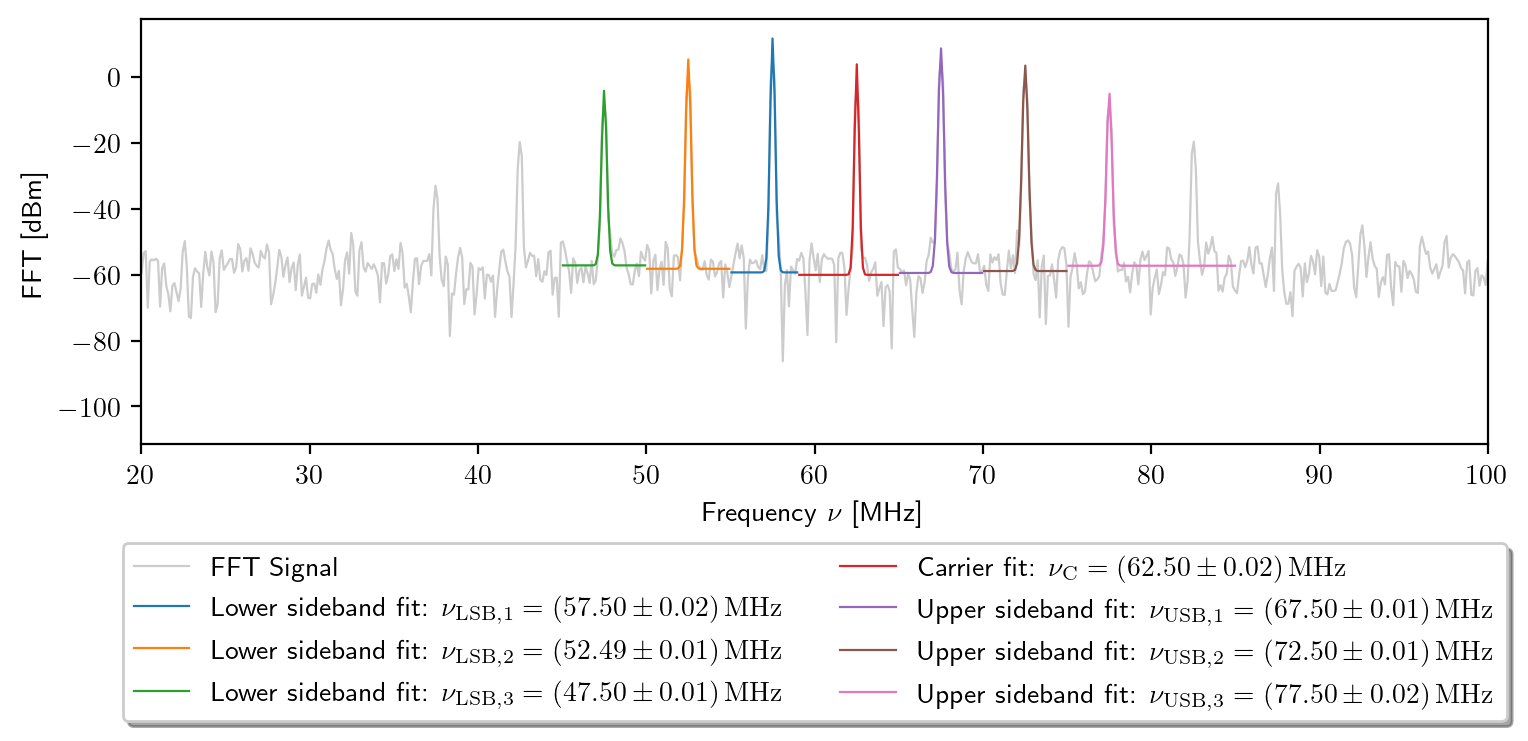

In [16]:
A3_100_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_21.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_100_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]
#freq_err = freq * 50e-6      # 50 ppm absolute
#ch1_err = 0.02 * np.abs(ch1) 

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower_3, fmax_lower_3 = 45, 50
fmin_lower_2, fmax_lower_2 = 50, 55
fmin_lower_1, fmax_lower_1 = 55, 59
fmin_carrier, fmax_carrier = 59, 65
fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75
fmin_upper_3, fmax_upper_3 = 75,85

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_l_3, func_l_3, popt_l_3, pcov_l_3, chi2_l_3 = fit_peak(freq, ch1, fmin_lower_3, fmax_lower_3, "gauss")
f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")
f_u_3, func_u_3, popt_u_3, pcov_u_3, chi2_u_3 = fit_peak(freq, ch1, fmin_upper_3, fmax_upper_3, "gauss")

plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_3, func_l_3(f_l_3, *popt_l_3), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,3}}}}=({popt_l_3[1]:.2f}\pm {np.sqrt(pcov_l_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_3, func_u_3(f_u_3, *popt_u_3), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,3}}}}=({popt_u_3[1]:.2f}\pm {np.sqrt(pcov_u_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A3_100_FFT.pdf", bbox_inches="tight")


from scipy.special import jv

kFM = 2

A_theo_1 = jv(1, kFM) / jv(0, kFM)
A_theo_2 = jv(2, kFM) / jv(0, kFM)
A_theo_3 = jv(3, kFM) / jv(0, kFM)

# Peak amplitudes
P_LSB1, sP_LSB1 = peak_dBm_and_sigma_from_gauss(popt_l_1, pcov_l_1)
P_C,    sP_C    = peak_dBm_and_sigma_from_gauss(popt_c,   pcov_c)
P_USB1, sP_USB1 = peak_dBm_and_sigma_from_gauss(popt_u_1, pcov_u_1)

# dBm -> linear
A_LSB1, sA_LSB1 = dBm_to_lin_and_sigma(P_LSB1, sP_LSB1)
A_C,    sA_C    = dBm_to_lin_and_sigma(P_C,    sP_C)
A_USB1, sA_USB1 = dBm_to_lin_and_sigma(P_USB1, sP_USB1)

# relative amplitudes
Arel_LSB1 = A_LSB1 / A_C
Arel_USB1 = A_USB1 / A_C
Arel_mean_1 = 0.5 * (Arel_LSB1 + Arel_USB1)

# errors
sArel_LSB1 = Arel_LSB1 * np.sqrt((sA_LSB1/A_LSB1)**2 + (sA_C/A_C)**2)
sArel_USB1 = Arel_USB1 * np.sqrt((sA_USB1/A_USB1)**2 + (sA_C/A_C)**2)
sArel_mean_1 = 0.5 * np.sqrt(sArel_LSB1**2 + sArel_USB1**2)

# n = 2
P_LSB2, sP_LSB2 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_USB2, sP_USB2 = peak_dBm_and_sigma_from_gauss(popt_u_2, pcov_u_2)

A_LSB2, sA_LSB2 = dBm_to_lin_and_sigma(P_LSB2, sP_LSB2)
A_USB2, sA_USB2 = dBm_to_lin_and_sigma(P_USB2, sP_USB2)

Arel_LSB2 = A_LSB2 / A_C
Arel_USB2 = A_USB2 / A_C
Arel_mean_2 = 0.5 * (Arel_LSB2 + Arel_USB2)

sArel_LSB2 = Arel_LSB2 * np.sqrt((sA_LSB2/A_LSB2)**2 + (sA_C/A_C)**2)
sArel_USB2 = Arel_USB2 * np.sqrt((sA_USB2/A_USB2)**2 + (sA_C/A_C)**2)
sArel_mean_2 = 0.5 * np.sqrt(sArel_LSB2**2 + sArel_USB2**2)

# n = 3
P_LSB3, sP_LSB3 = peak_dBm_and_sigma_from_gauss(popt_l_3, pcov_l_3)
P_USB3, sP_USB3 = peak_dBm_and_sigma_from_gauss(popt_u_3, pcov_u_3)

A_LSB3, sA_LSB3 = dBm_to_lin_and_sigma(P_LSB3, sP_LSB3)
A_USB3, sA_USB3 = dBm_to_lin_and_sigma(P_USB3, sP_USB3)

Arel_LSB3 = A_LSB3 / A_C
Arel_USB3 = A_USB3 / A_C
Arel_mean_3 = 0.5 * (Arel_LSB3 + Arel_USB3)

sArel_LSB3 = Arel_LSB3 * np.sqrt((sA_LSB3/A_LSB3)**2 + (sA_C/A_C)**2)
sArel_USB3 = Arel_USB3 * np.sqrt((sA_USB3/A_USB3)**2 + (sA_C/A_C)**2)
sArel_mean_3 = 0.5 * np.sqrt(sArel_LSB3**2 + sArel_USB3**2)

print("kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean")

print(f"{kFM:.1f}  1  "
      f"{A_theo_1:.4f}  "
      f"{Arel_LSB1:.3f}({sArel_LSB1:.3f})  "
      f"{Arel_USB1:.3f}({sArel_USB1:.3f})  "
      f"{Arel_mean_1:.3f}({sArel_mean_1:.3f})")

print(f"{kFM:.1f}  2  "
      f"{A_theo_2:.4f}  "
      f"{Arel_LSB2:.3f}({sArel_LSB2:.3f})  "
      f"{Arel_USB2:.3f}({sArel_USB2:.3f})  "
      f"{Arel_mean_2:.3f}({sArel_mean_2:.3f})")

print(f"{kFM:.1f}  3  "
      f"{A_theo_3:.4f}  "
      f"{Arel_LSB3:.3f}({sArel_LSB3:.3f})  "
      f"{Arel_USB3:.3f}({sArel_USB3:.3f})  "
      f"{Arel_mean_3:.3f}({sArel_mean_3:.3f})")

### Modulation Index = 200/50=4 -> Sidebands = 2 (k_FM +1 ) approx 11 bands 

kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean
4.0  1  0.1663  0.147(0.128)  0.123(0.090)  0.135(0.078)
4.0  2  -0.9169  0.721(0.532)  0.468(0.355)  0.595(0.320)
4.0  3  -1.0831  0.647(0.519)  0.450(0.330)  0.548(0.307)
4.0  4  -0.7079  0.398(0.281)  0.331(0.235)  0.365(0.183)
4.0  5  -0.3326  0.218(0.159)  0.167(0.138)  0.192(0.105)


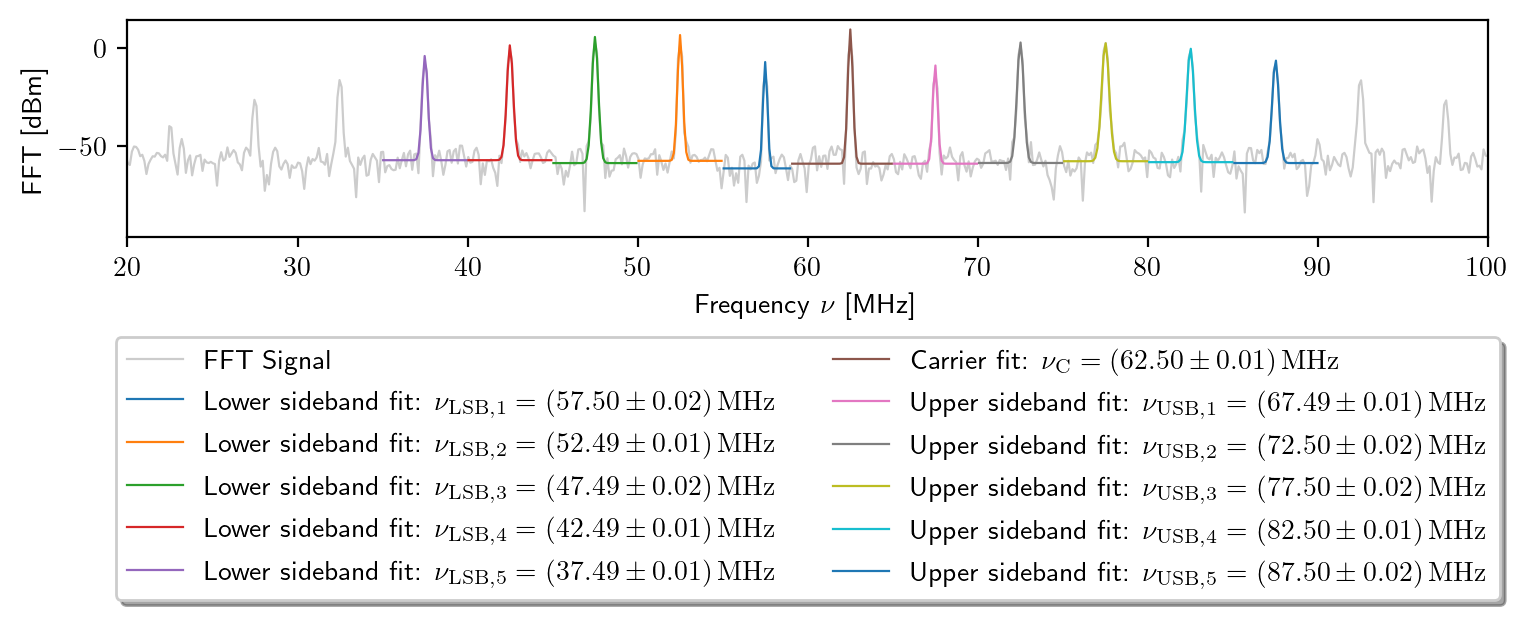

In [17]:
A3_200_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_22.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_200_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]
#freq_err = freq * 50e-6      # 50 ppm absolute
#ch1_err = 0.02 * np.abs(ch1) 

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower_5, fmax_lower_5 = 35, 40
fmin_lower_4, fmax_lower_4 = 40, 45
fmin_lower_3, fmax_lower_3 = 45, 50
fmin_lower_2, fmax_lower_2 = 50, 55
fmin_lower_1, fmax_lower_1 = 55, 59
fmin_carrier, fmax_carrier = 59, 65
fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75
fmin_upper_3, fmax_upper_3 = 75,80
fmin_upper_4, fmax_upper_4 = 80, 85
fmin_upper_5, fmax_upper_5 = 85, 90

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_l_3, func_l_3, popt_l_3, pcov_l_3, chi2_l_3 = fit_peak(freq, ch1, fmin_lower_3, fmax_lower_3, "gauss")
f_l_4, func_l_4, popt_l_4, pcov_l_4, chi2_l_4 = fit_peak(freq, ch1, fmin_lower_4, fmax_lower_4, "gauss")
f_l_5, func_l_5, popt_l_5, pcov_l_5, chi2_l_5 = fit_peak(freq, ch1, fmin_lower_5, fmax_lower_5, "gauss")
f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")
f_u_3, func_u_3, popt_u_3, pcov_u_3, chi2_u_3 = fit_peak(freq, ch1, fmin_upper_3, fmax_upper_3, "gauss")
f_u_4, func_u_4, popt_u_4, pcov_u_4, chi2_u_4 = fit_peak(freq, ch1, fmin_upper_4, fmax_upper_4, "gauss")
f_u_5, func_u_5, popt_u_5, pcov_u_5, chi2_u_5 = fit_peak(freq, ch1, fmin_upper_5, fmax_upper_5, "gauss")

plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_3, func_l_3(f_l_3, *popt_l_3), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,3}}}}=({popt_l_3[1]:.2f}\pm {np.sqrt(pcov_l_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_4, func_l_4(f_l_4, *popt_l_4), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,4}}}}=({popt_l_4[1]:.2f}\pm {np.sqrt(pcov_l_4[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_5, func_l_5(f_l_5, *popt_l_5), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,5}}}}=({popt_l_5[1]:.2f}\pm {np.sqrt(pcov_l_5[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_3, func_u_3(f_u_3, *popt_u_3), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,3}}}}=({popt_u_3[1]:.2f}\pm {np.sqrt(pcov_u_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_4, func_u_4(f_u_4, *popt_u_4), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,4}}}}=({popt_u_4[1]:.2f}\pm {np.sqrt(pcov_u_4[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_5, func_u_5(f_u_5, *popt_u_5), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,5}}}}=({popt_u_5[1]:.2f}\pm {np.sqrt(pcov_u_5[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A3_200_FFT.pdf", bbox_inches="tight")


from scipy.special import jv

kFM = 4

A_theo_1 = jv(1, kFM) / jv(0, kFM)
A_theo_2 = jv(2, kFM) / jv(0, kFM)
A_theo_3 = jv(3, kFM) / jv(0, kFM)
A_theo_4 = jv(4, kFM) / jv(0, kFM)
A_theo_5 = jv(5, kFM) / jv(0, kFM)

# Peak amplitudes
P_LSB1, sP_LSB1 = peak_dBm_and_sigma_from_gauss(popt_l_1, pcov_l_1)
P_C,    sP_C    = peak_dBm_and_sigma_from_gauss(popt_c,   pcov_c)
P_USB1, sP_USB1 = peak_dBm_and_sigma_from_gauss(popt_u_1, pcov_u_1)

# dBm -> linear
A_LSB1, sA_LSB1 = dBm_to_lin_and_sigma(P_LSB1, sP_LSB1)
A_C,    sA_C    = dBm_to_lin_and_sigma(P_C,    sP_C)
A_USB1, sA_USB1 = dBm_to_lin_and_sigma(P_USB1, sP_USB1)

# relative amplitudes
Arel_LSB1 = A_LSB1 / A_C
Arel_USB1 = A_USB1 / A_C
Arel_mean_1 = 0.5 * (Arel_LSB1 + Arel_USB1)

# errors
sArel_LSB1 = Arel_LSB1 * np.sqrt((sA_LSB1/A_LSB1)**2 + (sA_C/A_C)**2)
sArel_USB1 = Arel_USB1 * np.sqrt((sA_USB1/A_USB1)**2 + (sA_C/A_C)**2)
sArel_mean_1 = 0.5 * np.sqrt(sArel_LSB1**2 + sArel_USB1**2)

# n = 2
P_LSB2, sP_LSB2 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_USB2, sP_USB2 = peak_dBm_and_sigma_from_gauss(popt_u_2, pcov_u_2)

A_LSB2, sA_LSB2 = dBm_to_lin_and_sigma(P_LSB2, sP_LSB2)
A_USB2, sA_USB2 = dBm_to_lin_and_sigma(P_USB2, sP_USB2)

Arel_LSB2 = A_LSB2 / A_C
Arel_USB2 = A_USB2 / A_C
Arel_mean_2 = 0.5 * (Arel_LSB2 + Arel_USB2)

sArel_LSB2 = Arel_LSB2 * np.sqrt((sA_LSB2/A_LSB2)**2 + (sA_C/A_C)**2)
sArel_USB2 = Arel_USB2 * np.sqrt((sA_USB2/A_USB2)**2 + (sA_C/A_C)**2)
sArel_mean_2 = 0.5 * np.sqrt(sArel_LSB2**2 + sArel_USB2**2)

# n = 3
P_LSB3, sP_LSB3 = peak_dBm_and_sigma_from_gauss(popt_l_3, pcov_l_3)
P_USB3, sP_USB3 = peak_dBm_and_sigma_from_gauss(popt_u_3, pcov_u_3)

A_LSB3, sA_LSB3 = dBm_to_lin_and_sigma(P_LSB3, sP_LSB3)
A_USB3, sA_USB3 = dBm_to_lin_and_sigma(P_USB3, sP_USB3)

Arel_LSB3 = A_LSB3 / A_C
Arel_USB3 = A_USB3 / A_C
Arel_mean_3 = 0.5 * (Arel_LSB3 + Arel_USB3)

sArel_LSB3 = Arel_LSB3 * np.sqrt((sA_LSB3/A_LSB3)**2 + (sA_C/A_C)**2)
sArel_USB3 = Arel_USB3 * np.sqrt((sA_USB3/A_USB3)**2 + (sA_C/A_C)**2)
sArel_mean_3 = 0.5 * np.sqrt(sArel_LSB3**2 + sArel_USB3**2)

# n = 4
P_LSB4, sP_LSB4 = peak_dBm_and_sigma_from_gauss(popt_l_4, pcov_l_4)
P_USB4, sP_USB4 = peak_dBm_and_sigma_from_gauss(popt_u_4, pcov_u_4)

A_LSB4, sA_LSB4 = dBm_to_lin_and_sigma(P_LSB4, sP_LSB4)
A_USB4, sA_USB4 = dBm_to_lin_and_sigma(P_USB4, sP_USB4)

Arel_LSB4 = A_LSB4 / A_C
Arel_USB4 = A_USB4 / A_C
Arel_mean_4 = 0.5 * (Arel_LSB4 + Arel_USB4)

sArel_LSB4 = Arel_LSB4 * np.sqrt((sA_LSB4/A_LSB4)**2 + (sA_C/A_C)**2)
sArel_USB4 = Arel_USB4 * np.sqrt((sA_USB4/A_USB4)**2 + (sA_C/A_C)**2)
sArel_mean_4 = 0.5 * np.sqrt(sArel_LSB4**2 + sArel_USB4**2)

# n = 5
P_LSB5, sP_LSB5 = peak_dBm_and_sigma_from_gauss(popt_l_5, pcov_l_5)
P_USB5, sP_USB5 = peak_dBm_and_sigma_from_gauss(popt_u_5, pcov_u_5)

A_LSB5, sA_LSB5 = dBm_to_lin_and_sigma(P_LSB5, sP_LSB5)
A_USB5, sA_USB5 = dBm_to_lin_and_sigma(P_USB5, sP_USB5)

Arel_LSB5 = A_LSB5 / A_C
Arel_USB5 = A_USB5 / A_C
Arel_mean_5 = 0.5 * (Arel_LSB5 + Arel_USB5)

sArel_LSB5 = Arel_LSB5 * np.sqrt((sA_LSB5/A_LSB5)**2 + (sA_C/A_C)**2)
sArel_USB5 = Arel_USB5 * np.sqrt((sA_USB5/A_USB5)**2 + (sA_C/A_C)**2)
sArel_mean_5 = 0.5 * np.sqrt(sArel_LSB5**2 + sArel_USB5**2)

print("kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean")

print(f"{kFM:.1f}  1  "
      f"{A_theo_1:.4f}  "
      f"{Arel_LSB1:.3f}({sArel_LSB1:.3f})  "
      f"{Arel_USB1:.3f}({sArel_USB1:.3f})  "
      f"{Arel_mean_1:.3f}({sArel_mean_1:.3f})")

print(f"{kFM:.1f}  2  "
      f"{A_theo_2:.4f}  "
      f"{Arel_LSB2:.3f}({sArel_LSB2:.3f})  "
      f"{Arel_USB2:.3f}({sArel_USB2:.3f})  "
      f"{Arel_mean_2:.3f}({sArel_mean_2:.3f})")

print(f"{kFM:.1f}  3  "
      f"{A_theo_3:.4f}  "
      f"{Arel_LSB3:.3f}({sArel_LSB3:.3f})  "
      f"{Arel_USB3:.3f}({sArel_USB3:.3f})  "
      f"{Arel_mean_3:.3f}({sArel_mean_3:.3f})")

print(f"{kFM:.1f}  4  "
      f"{A_theo_4:.4f}  "
      f"{Arel_LSB4:.3f}({sArel_LSB4:.3f})  "
      f"{Arel_USB4:.3f}({sArel_USB4:.3f})  "
      f"{Arel_mean_4:.3f}({sArel_mean_4:.3f})")

print(f"{kFM:.1f}  5  "
      f"{A_theo_5:.4f}  "
      f"{Arel_LSB5:.3f}({sArel_LSB5:.3f})  "
      f"{Arel_USB5:.3f}({sArel_USB5:.3f})  "
      f"{Arel_mean_5:.3f}({sArel_mean_5:.3f})")

### Modulation Index = 300/50=6 -> Sidebands = 2 (k_FM +1 ) approx 15 bands 

kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean
6.0  1  -1.8367  2.254(1.648)  1.520(1.073)  1.887(0.983)
6.0  2  -1.6122  2.178(1.709)  1.196(0.785)  1.687(0.940)
6.0  3  0.7618  0.825(0.562)  0.610(0.422)  0.718(0.352)
6.0  4  2.3741  1.706(1.223)  1.252(0.734)  1.479(0.713)
6.0  5  2.4036  1.518(0.986)  0.974(0.624)  1.246(0.583)
6.0  6  1.6319  0.968(0.650)  0.873(0.537)  0.920(0.422)
6.0  7  0.8602  0.645(0.431)  0.507(0.360)  0.576(0.281)


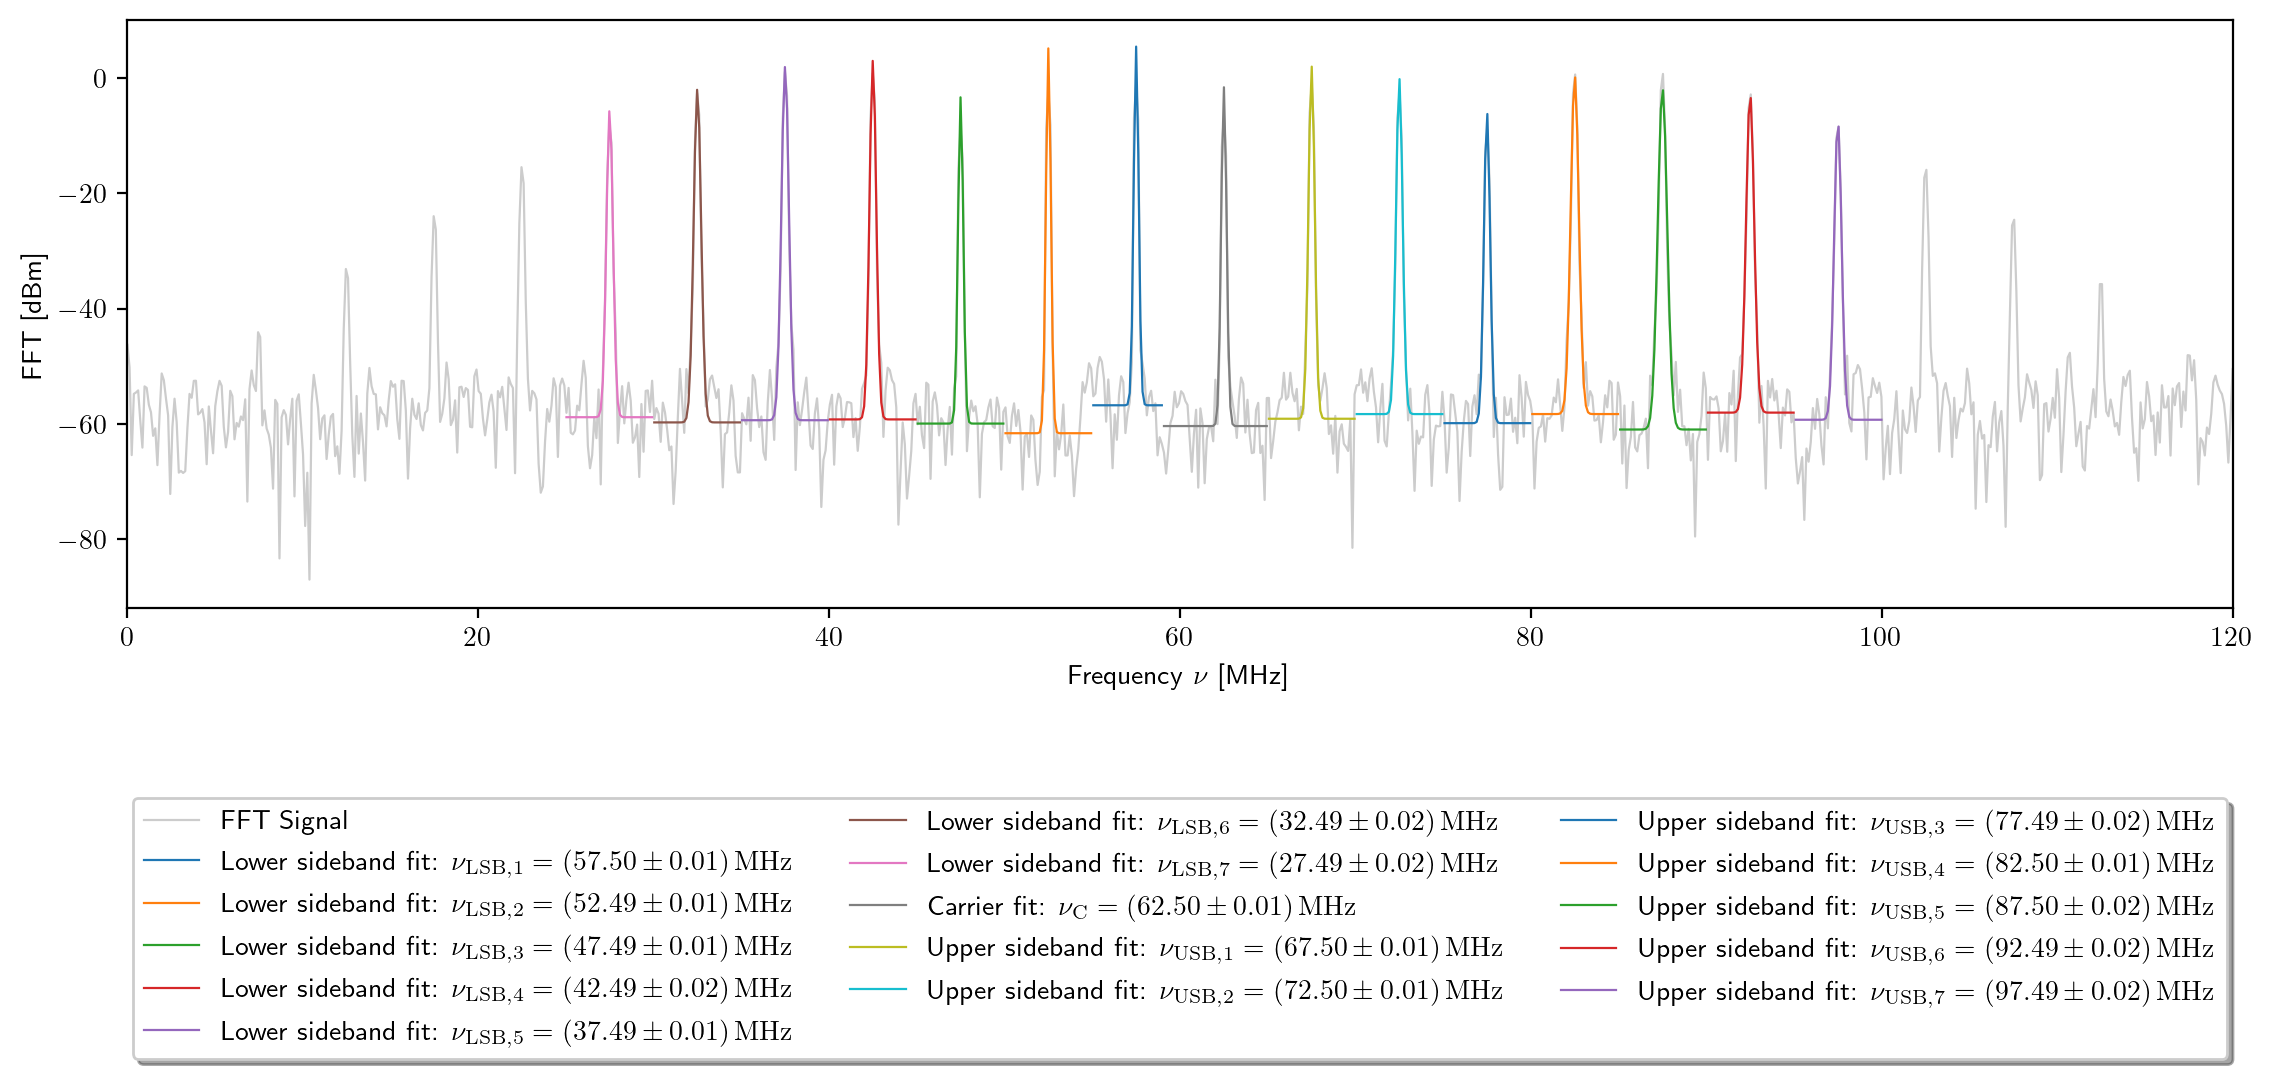

In [18]:
A3_300_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_23.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_300_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]
#freq_err = freq * 50e-6      # 50 ppm absolute
#ch1_err = 0.02 * np.abs(ch1) 

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower_7, fmax_lower_7 = 25, 30
fmin_lower_6, fmax_lower_6 = 30, 35
fmin_lower_5, fmax_lower_5 = 35, 40
fmin_lower_4, fmax_lower_4 = 40, 45
fmin_lower_3, fmax_lower_3 = 45, 50
fmin_lower_2, fmax_lower_2 = 50, 55
fmin_lower_1, fmax_lower_1 = 55, 59

fmin_carrier, fmax_carrier = 59, 65

fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75
fmin_upper_3, fmax_upper_3 = 75,80
fmin_upper_4, fmax_upper_4 = 80, 85
fmin_upper_5, fmax_upper_5 = 85, 90
fmin_upper_6, fmax_upper_6 = 90, 95
fmin_upper_7, fmax_upper_7 = 95, 100

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(12,6), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_l_3, func_l_3, popt_l_3, pcov_l_3, chi2_l_3 = fit_peak(freq, ch1, fmin_lower_3, fmax_lower_3, "gauss")
f_l_4, func_l_4, popt_l_4, pcov_l_4, chi2_l_4 = fit_peak(freq, ch1, fmin_lower_4, fmax_lower_4, "gauss")
f_l_5, func_l_5, popt_l_5, pcov_l_5, chi2_l_5 = fit_peak(freq, ch1, fmin_lower_5, fmax_lower_5, "gauss")
f_l_6, func_l_6, popt_l_6, pcov_l_6, chi2_l_6 = fit_peak(freq, ch1, fmin_lower_6, fmax_lower_6, "gauss")
f_l_7, func_l_7, popt_l_7, pcov_l_7, chi2_l_7 = fit_peak(freq, ch1, fmin_lower_7, fmax_lower_7, "gauss")

f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")

f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")
f_u_3, func_u_3, popt_u_3, pcov_u_3, chi2_u_3 = fit_peak(freq, ch1, fmin_upper_3, fmax_upper_3, "gauss")
f_u_4, func_u_4, popt_u_4, pcov_u_4, chi2_u_4 = fit_peak(freq, ch1, fmin_upper_4, fmax_upper_4, "gauss")
f_u_5, func_u_5, popt_u_5, pcov_u_5, chi2_u_5 = fit_peak(freq, ch1, fmin_upper_5, fmax_upper_5, "gauss")
f_u_6, func_u_6, popt_u_6, pcov_u_6, chi2_u_6 = fit_peak(freq, ch1, fmin_upper_6, fmax_upper_6, "gauss")
f_u_7, func_u_7, popt_u_7, pcov_u_7, chi2_u_7 = fit_peak(freq, ch1, fmin_upper_7, fmax_upper_7, "gauss")

plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_3, func_l_3(f_l_3, *popt_l_3), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,3}}}}=({popt_l_3[1]:.2f}\pm {np.sqrt(pcov_l_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_4, func_l_4(f_l_4, *popt_l_4), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,4}}}}=({popt_l_4[1]:.2f}\pm {np.sqrt(pcov_l_4[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_5, func_l_5(f_l_5, *popt_l_5), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,5}}}}=({popt_l_5[1]:.2f}\pm {np.sqrt(pcov_l_5[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_6, func_l_6(f_l_6, *popt_l_6), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,6}}}}=({popt_l_6[1]:.2f}\pm {np.sqrt(pcov_l_6[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_7, func_l_7(f_l_7, *popt_l_7), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,7}}}}=({popt_l_7[1]:.2f}\pm {np.sqrt(pcov_l_7[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_3, func_u_3(f_u_3, *popt_u_3), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,3}}}}=({popt_u_3[1]:.2f}\pm {np.sqrt(pcov_u_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_4, func_u_4(f_u_4, *popt_u_4), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,4}}}}=({popt_u_4[1]:.2f}\pm {np.sqrt(pcov_u_4[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_5, func_u_5(f_u_5, *popt_u_5), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,5}}}}=({popt_u_5[1]:.2f}\pm {np.sqrt(pcov_u_5[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_6, func_u_6(f_u_6, *popt_u_6), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,6}}}}=({popt_u_6[1]:.2f}\pm {np.sqrt(pcov_u_6[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_7, func_u_7(f_u_7, *popt_u_7), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,7}}}}=({popt_u_7[1]:.2f}\pm {np.sqrt(pcov_u_7[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(0, 120)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=3)


plt.tight_layout()
plt.savefig("A3_300_FFT.pdf", bbox_inches="tight")


from scipy.special import jv

kFM = 6

A_theo_1 = jv(1, kFM) / jv(0, kFM)
A_theo_2 = jv(2, kFM) / jv(0, kFM)
A_theo_3 = jv(3, kFM) / jv(0, kFM)
A_theo_4 = jv(4, kFM) / jv(0, kFM)
A_theo_5 = jv(5, kFM) / jv(0, kFM)
A_theo_6 = jv(6, kFM) / jv(0, kFM)
A_theo_7 = jv(7, kFM) / jv(0, kFM)

# Peak amplitudes
P_LSB1, sP_LSB1 = peak_dBm_and_sigma_from_gauss(popt_l_1, pcov_l_1)
P_C,    sP_C    = peak_dBm_and_sigma_from_gauss(popt_c,   pcov_c)
P_USB1, sP_USB1 = peak_dBm_and_sigma_from_gauss(popt_u_1, pcov_u_1)

# dBm -> linear
A_LSB1, sA_LSB1 = dBm_to_lin_and_sigma(P_LSB1, sP_LSB1)
A_C,    sA_C    = dBm_to_lin_and_sigma(P_C,    sP_C)
A_USB1, sA_USB1 = dBm_to_lin_and_sigma(P_USB1, sP_USB1)

# relative amplitudes
Arel_LSB1 = A_LSB1 / A_C
Arel_USB1 = A_USB1 / A_C
Arel_mean_1 = 0.5 * (Arel_LSB1 + Arel_USB1)

# errors
sArel_LSB1 = Arel_LSB1 * np.sqrt((sA_LSB1/A_LSB1)**2 + (sA_C/A_C)**2)
sArel_USB1 = Arel_USB1 * np.sqrt((sA_USB1/A_USB1)**2 + (sA_C/A_C)**2)
sArel_mean_1 = 0.5 * np.sqrt(sArel_LSB1**2 + sArel_USB1**2)

# n = 2
P_LSB2, sP_LSB2 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_USB2, sP_USB2 = peak_dBm_and_sigma_from_gauss(popt_u_2, pcov_u_2)

A_LSB2, sA_LSB2 = dBm_to_lin_and_sigma(P_LSB2, sP_LSB2)
A_USB2, sA_USB2 = dBm_to_lin_and_sigma(P_USB2, sP_USB2)

Arel_LSB2 = A_LSB2 / A_C
Arel_USB2 = A_USB2 / A_C
Arel_mean_2 = 0.5 * (Arel_LSB2 + Arel_USB2)

sArel_LSB2 = Arel_LSB2 * np.sqrt((sA_LSB2/A_LSB2)**2 + (sA_C/A_C)**2)
sArel_USB2 = Arel_USB2 * np.sqrt((sA_USB2/A_USB2)**2 + (sA_C/A_C)**2)
sArel_mean_2 = 0.5 * np.sqrt(sArel_LSB2**2 + sArel_USB2**2)

# n = 3
P_LSB3, sP_LSB3 = peak_dBm_and_sigma_from_gauss(popt_l_3, pcov_l_3)
P_USB3, sP_USB3 = peak_dBm_and_sigma_from_gauss(popt_u_3, pcov_u_3)

A_LSB3, sA_LSB3 = dBm_to_lin_and_sigma(P_LSB3, sP_LSB3)
A_USB3, sA_USB3 = dBm_to_lin_and_sigma(P_USB3, sP_USB3)

Arel_LSB3 = A_LSB3 / A_C
Arel_USB3 = A_USB3 / A_C
Arel_mean_3 = 0.5 * (Arel_LSB3 + Arel_USB3)

sArel_LSB3 = Arel_LSB3 * np.sqrt((sA_LSB3/A_LSB3)**2 + (sA_C/A_C)**2)
sArel_USB3 = Arel_USB3 * np.sqrt((sA_USB3/A_USB3)**2 + (sA_C/A_C)**2)
sArel_mean_3 = 0.5 * np.sqrt(sArel_LSB3**2 + sArel_USB3**2)

# n = 4
P_LSB4, sP_LSB4 = peak_dBm_and_sigma_from_gauss(popt_l_4, pcov_l_4)
P_USB4, sP_USB4 = peak_dBm_and_sigma_from_gauss(popt_u_4, pcov_u_4)

A_LSB4, sA_LSB4 = dBm_to_lin_and_sigma(P_LSB4, sP_LSB4)
A_USB4, sA_USB4 = dBm_to_lin_and_sigma(P_USB4, sP_USB4)

Arel_LSB4 = A_LSB4 / A_C
Arel_USB4 = A_USB4 / A_C
Arel_mean_4 = 0.5 * (Arel_LSB4 + Arel_USB4)

sArel_LSB4 = Arel_LSB4 * np.sqrt((sA_LSB4/A_LSB4)**2 + (sA_C/A_C)**2)
sArel_USB4 = Arel_USB4 * np.sqrt((sA_USB4/A_USB4)**2 + (sA_C/A_C)**2)
sArel_mean_4 = 0.5 * np.sqrt(sArel_LSB4**2 + sArel_USB4**2)

# n = 5
P_LSB5, sP_LSB5 = peak_dBm_and_sigma_from_gauss(popt_l_5, pcov_l_5)
P_USB5, sP_USB5 = peak_dBm_and_sigma_from_gauss(popt_u_5, pcov_u_5)

A_LSB5, sA_LSB5 = dBm_to_lin_and_sigma(P_LSB5, sP_LSB5)
A_USB5, sA_USB5 = dBm_to_lin_and_sigma(P_USB5, sP_USB5)

Arel_LSB5 = A_LSB5 / A_C
Arel_USB5 = A_USB5 / A_C
Arel_mean_5 = 0.5 * (Arel_LSB5 + Arel_USB5)

sArel_LSB5 = Arel_LSB5 * np.sqrt((sA_LSB5/A_LSB5)**2 + (sA_C/A_C)**2)
sArel_USB5 = Arel_USB5 * np.sqrt((sA_USB5/A_USB5)**2 + (sA_C/A_C)**2)
sArel_mean_5 = 0.5 * np.sqrt(sArel_LSB5**2 + sArel_USB5**2)

# n = 6
P_LSB6, sP_LSB6 = peak_dBm_and_sigma_from_gauss(popt_l_6, pcov_l_6)
P_USB6, sP_USB6 = peak_dBm_and_sigma_from_gauss(popt_u_6, pcov_u_6)

A_LSB6, sA_LSB6 = dBm_to_lin_and_sigma(P_LSB6, sP_LSB6)
A_USB6, sA_USB6 = dBm_to_lin_and_sigma(P_USB6, sP_USB6)

Arel_LSB6 = A_LSB6 / A_C
Arel_USB6 = A_USB6 / A_C
Arel_mean_6 = 0.5 * (Arel_LSB6 + Arel_USB6)

sArel_LSB6 = Arel_LSB6 * np.sqrt((sA_LSB6/A_LSB6)**2 + (sA_C/A_C)**2)
sArel_USB6 = Arel_USB6 * np.sqrt((sA_USB6/A_USB6)**2 + (sA_C/A_C)**2)
sArel_mean_6 = 0.5 * np.sqrt(sArel_LSB6**2 + sArel_USB6**2)

# n = 7
P_LSB7, sP_LSB7 = peak_dBm_and_sigma_from_gauss(popt_l_7, pcov_l_7)
P_USB7, sP_USB7 = peak_dBm_and_sigma_from_gauss(popt_u_7, pcov_u_7)

A_LSB7, sA_LSB7 = dBm_to_lin_and_sigma(P_LSB7, sP_LSB7)
A_USB7, sA_USB7 = dBm_to_lin_and_sigma(P_USB7, sP_USB7)

Arel_LSB7 = A_LSB7 / A_C
Arel_USB7 = A_USB7 / A_C
Arel_mean_7 = 0.5 * (Arel_LSB7 + Arel_USB7)

sArel_LSB7 = Arel_LSB7 * np.sqrt((sA_LSB7/A_LSB7)**2 + (sA_C/A_C)**2)
sArel_USB7 = Arel_USB7 * np.sqrt((sA_USB7/A_USB7)**2 + (sA_C/A_C)**2)
sArel_mean_7 = 0.5 * np.sqrt(sArel_LSB7**2 + sArel_USB7**2)


print("kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean")

print(f"{kFM:.1f}  1  "
      f"{A_theo_1:.4f}  "
      f"{Arel_LSB1:.3f}({sArel_LSB1:.3f})  "
      f"{Arel_USB1:.3f}({sArel_USB1:.3f})  "
      f"{Arel_mean_1:.3f}({sArel_mean_1:.3f})")

print(f"{kFM:.1f}  2  "
      f"{A_theo_2:.4f}  "
      f"{Arel_LSB2:.3f}({sArel_LSB2:.3f})  "
      f"{Arel_USB2:.3f}({sArel_USB2:.3f})  "
      f"{Arel_mean_2:.3f}({sArel_mean_2:.3f})")

print(f"{kFM:.1f}  3  "
      f"{A_theo_3:.4f}  "
      f"{Arel_LSB3:.3f}({sArel_LSB3:.3f})  "
      f"{Arel_USB3:.3f}({sArel_USB3:.3f})  "
      f"{Arel_mean_3:.3f}({sArel_mean_3:.3f})")

print(f"{kFM:.1f}  4  "
      f"{A_theo_4:.4f}  "
      f"{Arel_LSB4:.3f}({sArel_LSB4:.3f})  "
      f"{Arel_USB4:.3f}({sArel_USB4:.3f})  "
      f"{Arel_mean_4:.3f}({sArel_mean_4:.3f})")

print(f"{kFM:.1f}  5  "
      f"{A_theo_5:.4f}  "
      f"{Arel_LSB5:.3f}({sArel_LSB5:.3f})  "
      f"{Arel_USB5:.3f}({sArel_USB5:.3f})  "
      f"{Arel_mean_5:.3f}({sArel_mean_5:.3f})")

print(f"{kFM:.1f}  6  "
      f"{A_theo_6:.4f}  "
      f"{Arel_LSB6:.3f}({sArel_LSB6:.3f})  "
      f"{Arel_USB6:.3f}({sArel_USB6:.3f})  "
      f"{Arel_mean_6:.3f}({sArel_mean_6:.3f})")

print(f"{kFM:.1f}  7  "
      f"{A_theo_7:.4f}  "
      f"{Arel_LSB7:.3f}({sArel_LSB7:.3f})  "
      f"{Arel_USB7:.3f}({sArel_USB7:.3f})  "
      f"{Arel_mean_7:.3f}({sArel_mean_7:.3f})")

### Modulation Index = 400/50=8 -> Sidebands = 2 (k_FM +1 ) approx 19 bands 

### Modulation Index = 400/50=8 -> Sidebands = 2 (k_FM +1 ) approx 19 bands 

kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean
8.0  1  1.3669  1.620(1.303)  0.940(0.586)  1.280(0.714)
8.0  2  -0.6583  0.806(0.639)  0.461(0.380)  0.634(0.371)
8.0  3  -1.6961  1.592(1.353)  1.066(0.721)  1.329(0.766)
8.0  4  -0.6138  0.545(0.385)  0.395(0.278)  0.470(0.237)
8.0  5  1.0823  0.721(0.469)  0.582(0.380)  0.652(0.302)
8.0  6  1.9666  1.115(0.749)  0.852(0.558)  0.983(0.467)
8.0  7  1.8677  0.985(0.652)  0.784(0.493)  0.884(0.409)
8.0  8  1.3018  0.707(0.487)  0.661(0.398)  0.684(0.315)
8.0  9  0.7359  0.430(0.301)  0.391(0.248)  0.410(0.195)


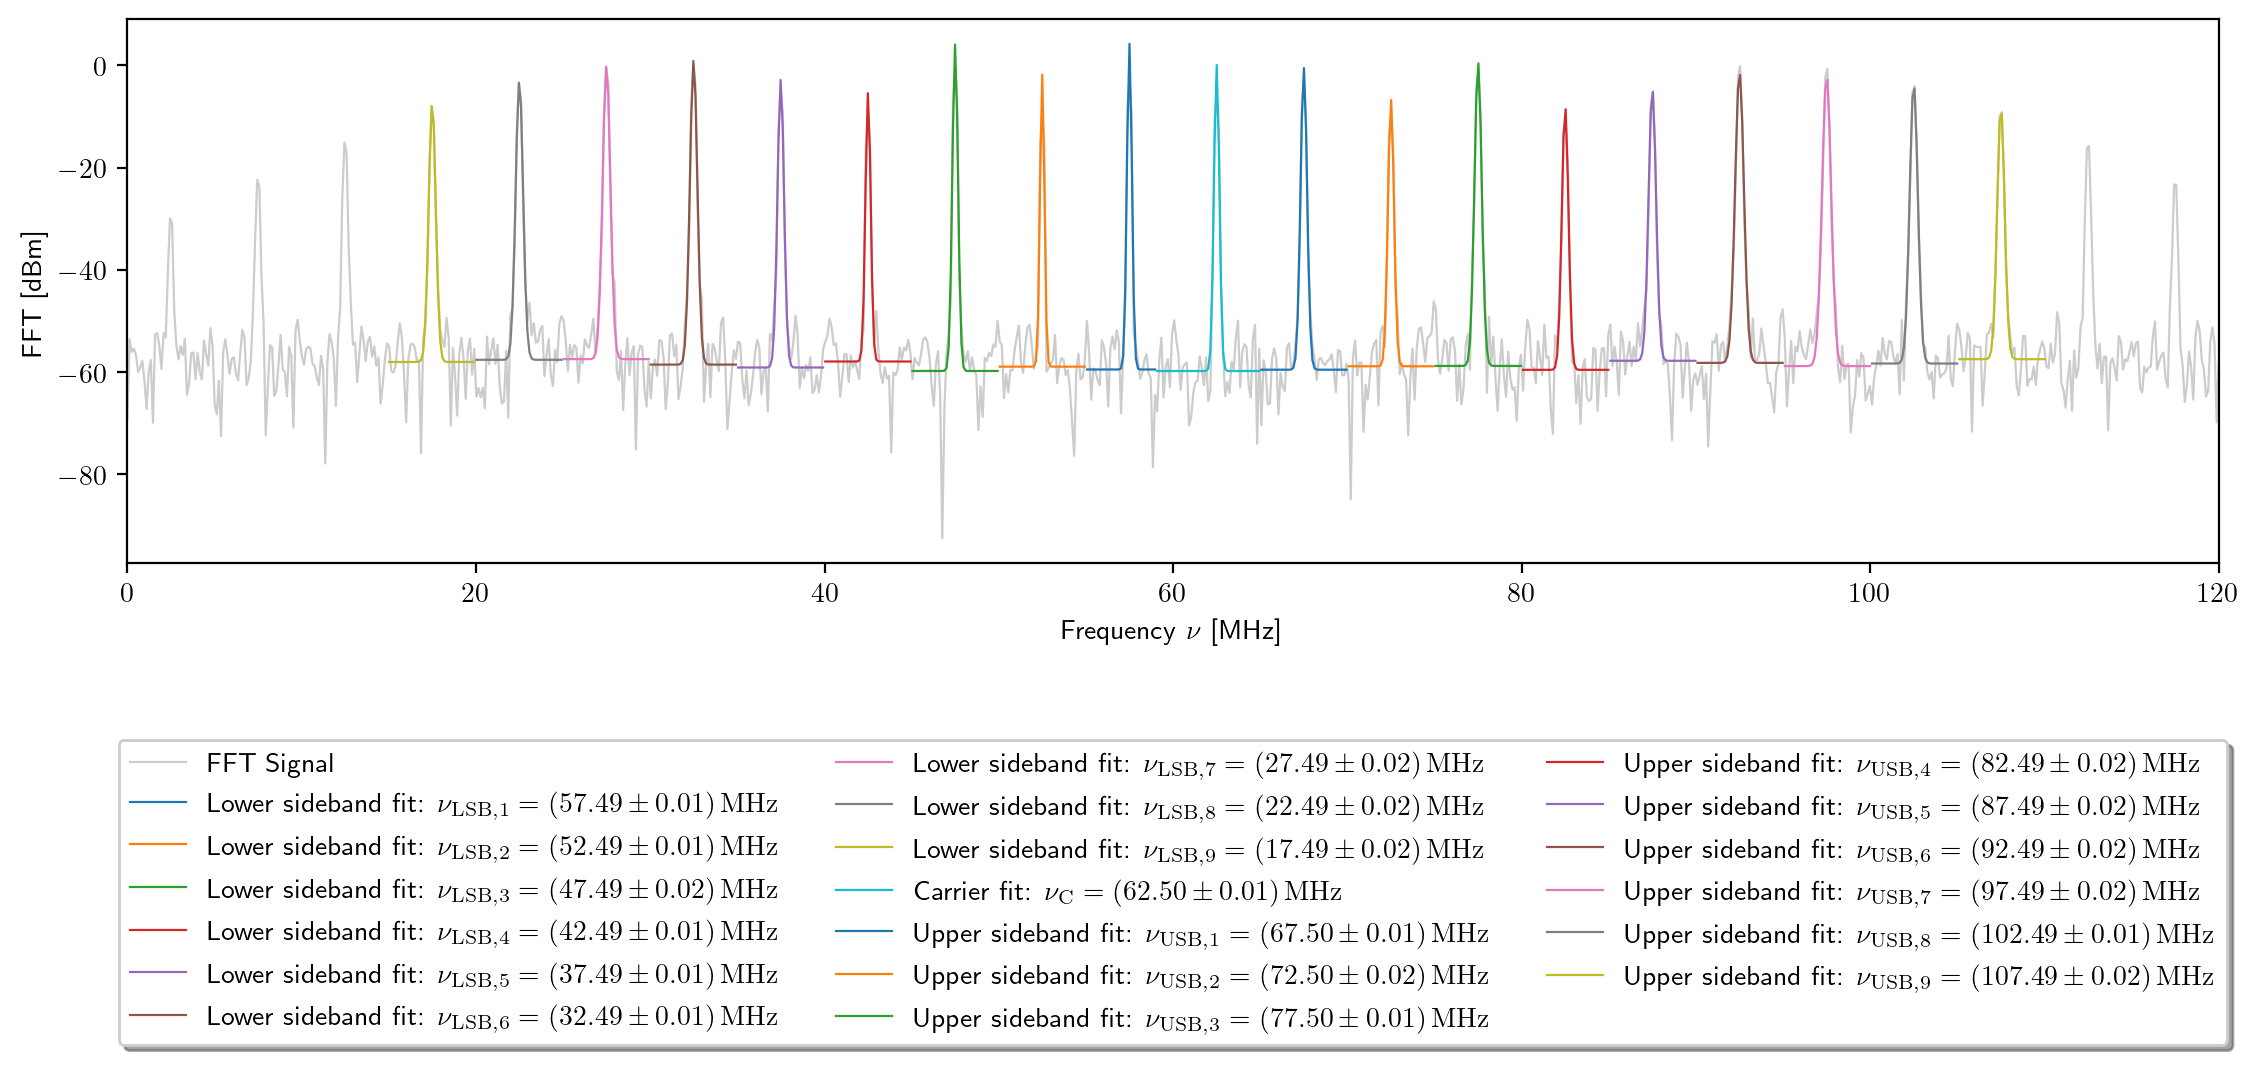

In [19]:
A3_400_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_24.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_400_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]
#freq_err = freq * 50e-6      # 50 ppm absolute
#ch1_err = 0.02 * np.abs(ch1) 

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower_9, fmax_lower_9 = 15, 20
fmin_lower_8, fmax_lower_8 = 20, 25
fmin_lower_7, fmax_lower_7 = 25, 30
fmin_lower_6, fmax_lower_6 = 30, 35
fmin_lower_5, fmax_lower_5 = 35, 40
fmin_lower_4, fmax_lower_4 = 40, 45
fmin_lower_3, fmax_lower_3 = 45, 50
fmin_lower_2, fmax_lower_2 = 50, 55
fmin_lower_1, fmax_lower_1 = 55, 59


fmin_carrier, fmax_carrier = 59, 65

fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75
fmin_upper_3, fmax_upper_3 = 75,80
fmin_upper_4, fmax_upper_4 = 80, 85
fmin_upper_5, fmax_upper_5 = 85, 90
fmin_upper_6, fmax_upper_6 = 90, 95
fmin_upper_7, fmax_upper_7 = 95, 100
fmin_upper_8, fmax_upper_8 = 100, 105
fmin_upper_9, fmax_upper_9 = 105, 110

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(12,6), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_l_3, func_l_3, popt_l_3, pcov_l_3, chi2_l_3 = fit_peak(freq, ch1, fmin_lower_3, fmax_lower_3, "gauss")
f_l_4, func_l_4, popt_l_4, pcov_l_4, chi2_l_4 = fit_peak(freq, ch1, fmin_lower_4, fmax_lower_4, "gauss")
f_l_5, func_l_5, popt_l_5, pcov_l_5, chi2_l_5 = fit_peak(freq, ch1, fmin_lower_5, fmax_lower_5, "gauss")
f_l_6, func_l_6, popt_l_6, pcov_l_6, chi2_l_6 = fit_peak(freq, ch1, fmin_lower_6, fmax_lower_6, "gauss")
f_l_7, func_l_7, popt_l_7, pcov_l_7, chi2_l_7 = fit_peak(freq, ch1, fmin_lower_7, fmax_lower_7, "gauss")
f_l_8, func_l_8, popt_l_8, pcov_l_8, chi2_l_8 = fit_peak(freq, ch1, fmin_lower_8, fmax_lower_8, "gauss")
f_l_9, func_l_9, popt_l_9, pcov_l_9, chi2_l_9 = fit_peak(freq, ch1, fmin_lower_9, fmax_lower_9, "gauss")

f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")

f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")
f_u_3, func_u_3, popt_u_3, pcov_u_3, chi2_u_3 = fit_peak(freq, ch1, fmin_upper_3, fmax_upper_3, "gauss")
f_u_4, func_u_4, popt_u_4, pcov_u_4, chi2_u_4 = fit_peak(freq, ch1, fmin_upper_4, fmax_upper_4, "gauss")
f_u_5, func_u_5, popt_u_5, pcov_u_5, chi2_u_5 = fit_peak(freq, ch1, fmin_upper_5, fmax_upper_5, "gauss")
f_u_6, func_u_6, popt_u_6, pcov_u_6, chi2_u_6 = fit_peak(freq, ch1, fmin_upper_6, fmax_upper_6, "gauss")
f_u_7, func_u_7, popt_u_7, pcov_u_7, chi2_u_7 = fit_peak(freq, ch1, fmin_upper_7, fmax_upper_7, "gauss")
f_u_8, func_u_8, popt_u_8, pcov_u_8, chi2_u_8 = fit_peak(freq, ch1, fmin_upper_8, fmax_upper_8, "gauss")
f_u_9, func_u_9, popt_u_9, pcov_u_9, chi2_u_9 = fit_peak(freq, ch1, fmin_upper_9, fmax_upper_9, "gauss")

plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_3, func_l_3(f_l_3, *popt_l_3), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,3}}}}=({popt_l_3[1]:.2f}\pm {np.sqrt(pcov_l_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_4, func_l_4(f_l_4, *popt_l_4), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,4}}}}=({popt_l_4[1]:.2f}\pm {np.sqrt(pcov_l_4[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_5, func_l_5(f_l_5, *popt_l_5), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,5}}}}=({popt_l_5[1]:.2f}\pm {np.sqrt(pcov_l_5[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_6, func_l_6(f_l_6, *popt_l_6), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,6}}}}=({popt_l_6[1]:.2f}\pm {np.sqrt(pcov_l_6[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_7, func_l_7(f_l_7, *popt_l_7), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,7}}}}=({popt_l_7[1]:.2f}\pm {np.sqrt(pcov_l_7[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_8, func_l_8(f_l_8, *popt_l_8), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,8}}}}=({popt_l_8[1]:.2f}\pm {np.sqrt(pcov_l_8[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_9, func_l_9(f_l_9, *popt_l_9), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,9}}}}=({popt_l_9[1]:.2f}\pm {np.sqrt(pcov_l_9[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_3, func_u_3(f_u_3, *popt_u_3), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,3}}}}=({popt_u_3[1]:.2f}\pm {np.sqrt(pcov_u_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_4, func_u_4(f_u_4, *popt_u_4), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,4}}}}=({popt_u_4[1]:.2f}\pm {np.sqrt(pcov_u_4[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_5, func_u_5(f_u_5, *popt_u_5), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,5}}}}=({popt_u_5[1]:.2f}\pm {np.sqrt(pcov_u_5[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_6, func_u_6(f_u_6, *popt_u_6), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,6}}}}=({popt_u_6[1]:.2f}\pm {np.sqrt(pcov_u_6[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_7, func_u_7(f_u_7, *popt_u_7), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,7}}}}=({popt_u_7[1]:.2f}\pm {np.sqrt(pcov_u_7[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_8, func_u_8(f_u_8, *popt_u_8), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,8}}}}=({popt_u_8[1]:.2f}\pm {np.sqrt(pcov_u_8[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_9, func_u_9(f_u_9, *popt_u_9), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,9}}}}=({popt_u_9[1]:.2f}\pm {np.sqrt(pcov_u_9[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(0, 120)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=3)


plt.tight_layout()
plt.savefig("A3_400_FFT.pdf", bbox_inches="tight")


from scipy.special import jv

kFM = 8

A_theo_1 = jv(1, kFM) / jv(0, kFM)
A_theo_2 = jv(2, kFM) / jv(0, kFM)
A_theo_3 = jv(3, kFM) / jv(0, kFM)
A_theo_4 = jv(4, kFM) / jv(0, kFM)
A_theo_5 = jv(5, kFM) / jv(0, kFM)
A_theo_6 = jv(6, kFM) / jv(0, kFM)
A_theo_7 = jv(7, kFM) / jv(0, kFM)
A_theo_8 = jv(8, kFM) / jv(0, kFM)
A_theo_9 = jv(9, kFM) / jv(0, kFM)

# Peak amplitudes
P_LSB1, sP_LSB1 = peak_dBm_and_sigma_from_gauss(popt_l_1, pcov_l_1)
P_C,    sP_C    = peak_dBm_and_sigma_from_gauss(popt_c,   pcov_c)
P_USB1, sP_USB1 = peak_dBm_and_sigma_from_gauss(popt_u_1, pcov_u_1)

# dBm -> linear
A_LSB1, sA_LSB1 = dBm_to_lin_and_sigma(P_LSB1, sP_LSB1)
A_C,    sA_C    = dBm_to_lin_and_sigma(P_C,    sP_C)
A_USB1, sA_USB1 = dBm_to_lin_and_sigma(P_USB1, sP_USB1)

# relative amplitudes
Arel_LSB1 = A_LSB1 / A_C
Arel_USB1 = A_USB1 / A_C
Arel_mean_1 = 0.5 * (Arel_LSB1 + Arel_USB1)

# errors
sArel_LSB1 = Arel_LSB1 * np.sqrt((sA_LSB1/A_LSB1)**2 + (sA_C/A_C)**2)
sArel_USB1 = Arel_USB1 * np.sqrt((sA_USB1/A_USB1)**2 + (sA_C/A_C)**2)
sArel_mean_1 = 0.5 * np.sqrt(sArel_LSB1**2 + sArel_USB1**2)

# n = 2
P_LSB2, sP_LSB2 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_USB2, sP_USB2 = peak_dBm_and_sigma_from_gauss(popt_u_2, pcov_u_2)

A_LSB2, sA_LSB2 = dBm_to_lin_and_sigma(P_LSB2, sP_LSB2)
A_USB2, sA_USB2 = dBm_to_lin_and_sigma(P_USB2, sP_USB2)

Arel_LSB2 = A_LSB2 / A_C
Arel_USB2 = A_USB2 / A_C
Arel_mean_2 = 0.5 * (Arel_LSB2 + Arel_USB2)

sArel_LSB2 = Arel_LSB2 * np.sqrt((sA_LSB2/A_LSB2)**2 + (sA_C/A_C)**2)
sArel_USB2 = Arel_USB2 * np.sqrt((sA_USB2/A_USB2)**2 + (sA_C/A_C)**2)
sArel_mean_2 = 0.5 * np.sqrt(sArel_LSB2**2 + sArel_USB2**2)

# n = 3
P_LSB3, sP_LSB3 = peak_dBm_and_sigma_from_gauss(popt_l_3, pcov_l_3)
P_USB3, sP_USB3 = peak_dBm_and_sigma_from_gauss(popt_u_3, pcov_u_3)

A_LSB3, sA_LSB3 = dBm_to_lin_and_sigma(P_LSB3, sP_LSB3)
A_USB3, sA_USB3 = dBm_to_lin_and_sigma(P_USB3, sP_USB3)

Arel_LSB3 = A_LSB3 / A_C
Arel_USB3 = A_USB3 / A_C
Arel_mean_3 = 0.5 * (Arel_LSB3 + Arel_USB3)

sArel_LSB3 = Arel_LSB3 * np.sqrt((sA_LSB3/A_LSB3)**2 + (sA_C/A_C)**2)
sArel_USB3 = Arel_USB3 * np.sqrt((sA_USB3/A_USB3)**2 + (sA_C/A_C)**2)
sArel_mean_3 = 0.5 * np.sqrt(sArel_LSB3**2 + sArel_USB3**2)

# n = 4
P_LSB4, sP_LSB4 = peak_dBm_and_sigma_from_gauss(popt_l_4, pcov_l_4)
P_USB4, sP_USB4 = peak_dBm_and_sigma_from_gauss(popt_u_4, pcov_u_4)

A_LSB4, sA_LSB4 = dBm_to_lin_and_sigma(P_LSB4, sP_LSB4)
A_USB4, sA_USB4 = dBm_to_lin_and_sigma(P_USB4, sP_USB4)

Arel_LSB4 = A_LSB4 / A_C
Arel_USB4 = A_USB4 / A_C
Arel_mean_4 = 0.5 * (Arel_LSB4 + Arel_USB4)

sArel_LSB4 = Arel_LSB4 * np.sqrt((sA_LSB4/A_LSB4)**2 + (sA_C/A_C)**2)
sArel_USB4 = Arel_USB4 * np.sqrt((sA_USB4/A_USB4)**2 + (sA_C/A_C)**2)
sArel_mean_4 = 0.5 * np.sqrt(sArel_LSB4**2 + sArel_USB4**2)

# n = 5
P_LSB5, sP_LSB5 = peak_dBm_and_sigma_from_gauss(popt_l_5, pcov_l_5)
P_USB5, sP_USB5 = peak_dBm_and_sigma_from_gauss(popt_u_5, pcov_u_5)

A_LSB5, sA_LSB5 = dBm_to_lin_and_sigma(P_LSB5, sP_LSB5)
A_USB5, sA_USB5 = dBm_to_lin_and_sigma(P_USB5, sP_USB5)

Arel_LSB5 = A_LSB5 / A_C
Arel_USB5 = A_USB5 / A_C
Arel_mean_5 = 0.5 * (Arel_LSB5 + Arel_USB5)

sArel_LSB5 = Arel_LSB5 * np.sqrt((sA_LSB5/A_LSB5)**2 + (sA_C/A_C)**2)
sArel_USB5 = Arel_USB5 * np.sqrt((sA_USB5/A_USB5)**2 + (sA_C/A_C)**2)
sArel_mean_5 = 0.5 * np.sqrt(sArel_LSB5**2 + sArel_USB5**2)

# n = 6
P_LSB6, sP_LSB6 = peak_dBm_and_sigma_from_gauss(popt_l_6, pcov_l_6)
P_USB6, sP_USB6 = peak_dBm_and_sigma_from_gauss(popt_u_6, pcov_u_6)

A_LSB6, sA_LSB6 = dBm_to_lin_and_sigma(P_LSB6, sP_LSB6)
A_USB6, sA_USB6 = dBm_to_lin_and_sigma(P_USB6, sP_USB6)

Arel_LSB6 = A_LSB6 / A_C
Arel_USB6 = A_USB6 / A_C
Arel_mean_6 = 0.5 * (Arel_LSB6 + Arel_USB6)

sArel_LSB6 = Arel_LSB6 * np.sqrt((sA_LSB6/A_LSB6)**2 + (sA_C/A_C)**2)
sArel_USB6 = Arel_USB6 * np.sqrt((sA_USB6/A_USB6)**2 + (sA_C/A_C)**2)
sArel_mean_6 = 0.5 * np.sqrt(sArel_LSB6**2 + sArel_USB6**2)

# n = 7
P_LSB7, sP_LSB7 = peak_dBm_and_sigma_from_gauss(popt_l_7, pcov_l_7)
P_USB7, sP_USB7 = peak_dBm_and_sigma_from_gauss(popt_u_7, pcov_u_7)

A_LSB7, sA_LSB7 = dBm_to_lin_and_sigma(P_LSB7, sP_LSB7)
A_USB7, sA_USB7 = dBm_to_lin_and_sigma(P_USB7, sP_USB7)

Arel_LSB7 = A_LSB7 / A_C
Arel_USB7 = A_USB7 / A_C
Arel_mean_7 = 0.5 * (Arel_LSB7 + Arel_USB7)

sArel_LSB7 = Arel_LSB7 * np.sqrt((sA_LSB7/A_LSB7)**2 + (sA_C/A_C)**2)
sArel_USB7 = Arel_USB7 * np.sqrt((sA_USB7/A_USB7)**2 + (sA_C/A_C)**2)
sArel_mean_7 = 0.5 * np.sqrt(sArel_LSB7**2 + sArel_USB7**2)

# n = 8
P_LSB8, sP_LSB8 = peak_dBm_and_sigma_from_gauss(popt_l_8, pcov_l_8)
P_USB8, sP_USB8 = peak_dBm_and_sigma_from_gauss(popt_u_8, pcov_u_8)

A_LSB8, sA_LSB8 = dBm_to_lin_and_sigma(P_LSB8, sP_LSB8)
A_USB8, sA_USB8 = dBm_to_lin_and_sigma(P_USB8, sP_USB8)

Arel_LSB8 = A_LSB8 / A_C
Arel_USB8 = A_USB8 / A_C
Arel_mean_8 = 0.5 * (Arel_LSB8 + Arel_USB8)

sArel_LSB8 = Arel_LSB8 * np.sqrt((sA_LSB8/A_LSB8)**2 + (sA_C/A_C)**2)
sArel_USB8 = Arel_USB8 * np.sqrt((sA_USB8/A_USB8)**2 + (sA_C/A_C)**2)
sArel_mean_8 = 0.5 * np.sqrt(sArel_LSB8**2 + sArel_USB8**2)

# n = 9
P_LSB9, sP_LSB9 = peak_dBm_and_sigma_from_gauss(popt_l_9, pcov_l_9)
P_USB9, sP_USB9 = peak_dBm_and_sigma_from_gauss(popt_u_9, pcov_u_9)

A_LSB9, sA_LSB9 = dBm_to_lin_and_sigma(P_LSB9, sP_LSB9)
A_USB9, sA_USB9 = dBm_to_lin_and_sigma(P_USB9, sP_USB9)

Arel_LSB9 = A_LSB9 / A_C
Arel_USB9 = A_USB9 / A_C
Arel_mean_9 = 0.5 * (Arel_LSB9 + Arel_USB9)

sArel_LSB9 = Arel_LSB9 * np.sqrt((sA_LSB9/A_LSB9)**2 + (sA_C/A_C)**2)
sArel_USB9 = Arel_USB9 * np.sqrt((sA_USB9/A_USB9)**2 + (sA_C/A_C)**2)
sArel_mean_9 = 0.5 * np.sqrt(sArel_LSB9**2 + sArel_USB9**2)

print("kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean")

print(f"{kFM:.1f}  1  "
      f"{A_theo_1:.4f}  "
      f"{Arel_LSB1:.3f}({sArel_LSB1:.3f})  "
      f"{Arel_USB1:.3f}({sArel_USB1:.3f})  "
      f"{Arel_mean_1:.3f}({sArel_mean_1:.3f})")

print(f"{kFM:.1f}  2  "
      f"{A_theo_2:.4f}  "
      f"{Arel_LSB2:.3f}({sArel_LSB2:.3f})  "
      f"{Arel_USB2:.3f}({sArel_USB2:.3f})  "
      f"{Arel_mean_2:.3f}({sArel_mean_2:.3f})")

print(f"{kFM:.1f}  3  "
      f"{A_theo_3:.4f}  "
      f"{Arel_LSB3:.3f}({sArel_LSB3:.3f})  "
      f"{Arel_USB3:.3f}({sArel_USB3:.3f})  "
      f"{Arel_mean_3:.3f}({sArel_mean_3:.3f})")

print(f"{kFM:.1f}  4  "
      f"{A_theo_4:.4f}  "
      f"{Arel_LSB4:.3f}({sArel_LSB4:.3f})  "
      f"{Arel_USB4:.3f}({sArel_USB4:.3f})  "
      f"{Arel_mean_4:.3f}({sArel_mean_4:.3f})")

print(f"{kFM:.1f}  5  "
      f"{A_theo_5:.4f}  "
      f"{Arel_LSB5:.3f}({sArel_LSB5:.3f})  "
      f"{Arel_USB5:.3f}({sArel_USB5:.3f})  "
      f"{Arel_mean_5:.3f}({sArel_mean_5:.3f})")

print(f"{kFM:.1f}  6  "
      f"{A_theo_6:.4f}  "
      f"{Arel_LSB6:.3f}({sArel_LSB6:.3f})  "
      f"{Arel_USB6:.3f}({sArel_USB6:.3f})  "
      f"{Arel_mean_6:.3f}({sArel_mean_6:.3f})")

print(f"{kFM:.1f}  7  "
      f"{A_theo_7:.4f}  "
      f"{Arel_LSB7:.3f}({sArel_LSB7:.3f})  "
      f"{Arel_USB7:.3f}({sArel_USB7:.3f})  "
      f"{Arel_mean_7:.3f}({sArel_mean_7:.3f})")

print(f"{kFM:.1f}  8  "
      f"{A_theo_8:.4f}  "
      f"{Arel_LSB8:.3f}({sArel_LSB8:.3f})  "
      f"{Arel_USB8:.3f}({sArel_USB8:.3f})  "
      f"{Arel_mean_8:.3f}({sArel_mean_8:.3f})")

print(f"{kFM:.1f}  9  "
      f"{A_theo_9:.4f}  "
      f"{Arel_LSB9:.3f}({sArel_LSB9:.3f})  "
      f"{Arel_USB9:.3f}({sArel_USB9:.3f})  "
      f"{Arel_mean_9:.3f}({sArel_mean_9:.3f})")

### Modulation Index = 500/50=10 -> Sidebands = 2 (k_FM +1 ) approx 23 bands 

kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean
10.0  1  -0.1768  0.233(0.192)  0.209(0.152)  0.221(0.122)
10.0  2  -1.0354  1.656(1.439)  0.751(0.462)  1.204(0.756)
10.0  3  -0.2374  0.439(0.510)  0.215(0.151)  0.327(0.266)
10.0  4  0.8929  1.114(0.883)  0.540(0.350)  0.827(0.475)
10.0  5  0.9517  0.913(0.556)  0.650(0.450)  0.781(0.358)
10.0  6  0.0588  0.055(0.048)  0.046(0.029)  0.050(0.028)
10.0  7  -0.8812  0.730(0.407)  0.504(0.292)  0.617(0.250)
10.0  8  -1.2924  0.722(0.467)  0.713(0.451)  0.718(0.324)
10.0  9  -1.1867  0.674(0.439)  0.678(0.422)  0.676(0.304)
10.0  10  -0.8437  0.557(0.415)  0.536(0.328)  0.546(0.265)
10.0  11  -0.5006  0.362(0.229)  0.333(0.207)  0.347(0.154)


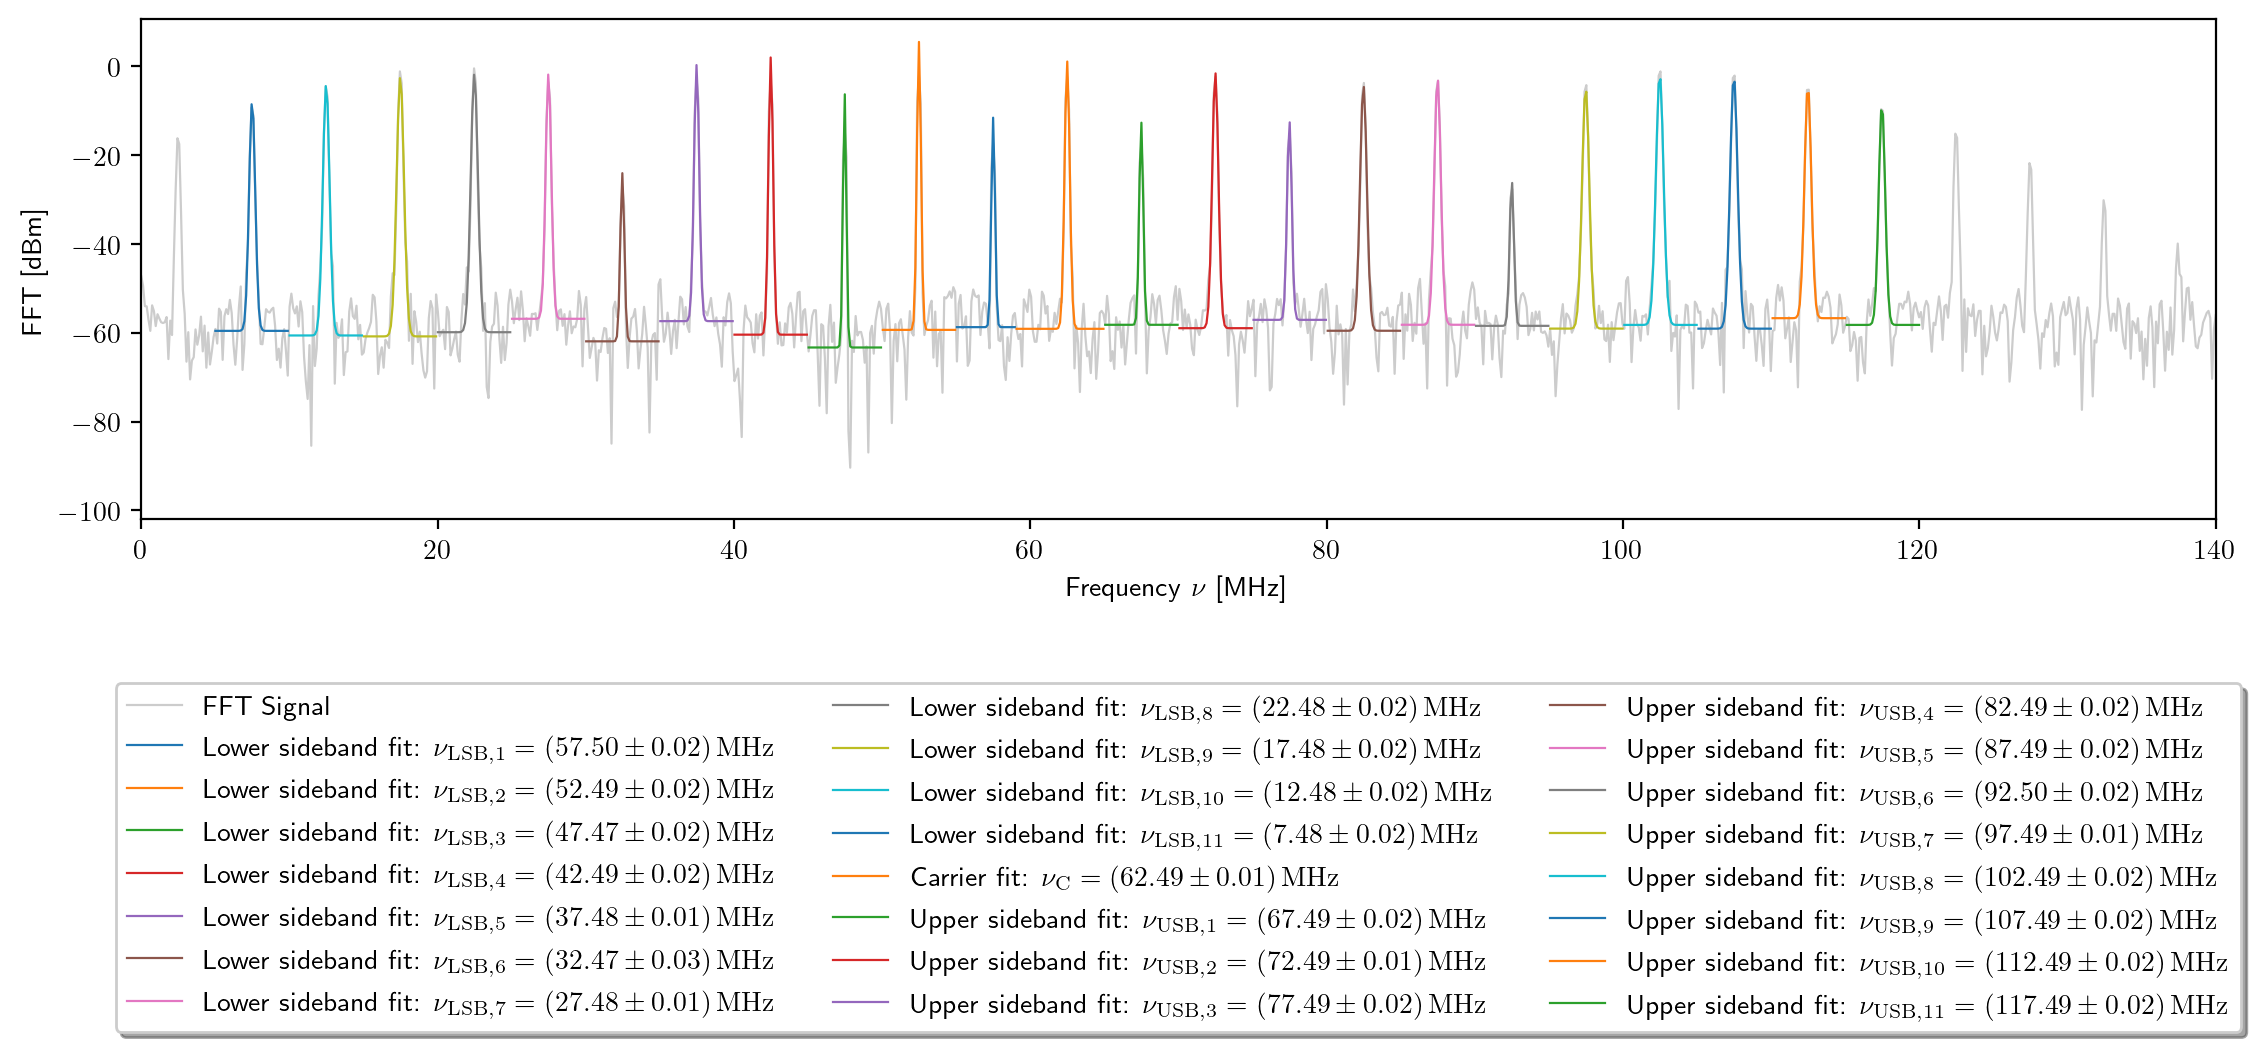

In [20]:
A3_500_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_25.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_500_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]
#freq_err = freq * 50e-6      # 50 ppm absolute
#ch1_err = 0.02 * np.abs(ch1) 

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower_11, fmax_lower_11 = 5, 10
fmin_lower_10, fmax_lower_10 = 10, 15
fmin_lower_9, fmax_lower_9 = 15, 20
fmin_lower_8, fmax_lower_8 = 20, 25
fmin_lower_7, fmax_lower_7 = 25, 30
fmin_lower_6, fmax_lower_6 = 30, 35
fmin_lower_5, fmax_lower_5 = 35, 40
fmin_lower_4, fmax_lower_4 = 40, 45
fmin_lower_3, fmax_lower_3 = 45, 50
fmin_lower_2, fmax_lower_2 = 50, 55
fmin_lower_1, fmax_lower_1 = 55, 59


fmin_carrier, fmax_carrier = 59, 65

fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75
fmin_upper_3, fmax_upper_3 = 75,80
fmin_upper_4, fmax_upper_4 = 80, 85
fmin_upper_5, fmax_upper_5 = 85, 90
fmin_upper_6, fmax_upper_6 = 90, 95
fmin_upper_7, fmax_upper_7 = 95, 100
fmin_upper_8, fmax_upper_8 = 100, 105
fmin_upper_9, fmax_upper_9 = 105, 110
fmin_upper_10, fmax_upper_10 = 110, 115
fmin_upper_11, fmax_upper_11 = 115, 120

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(12,6), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_l_3, func_l_3, popt_l_3, pcov_l_3, chi2_l_3 = fit_peak(freq, ch1, fmin_lower_3, fmax_lower_3, "gauss")
f_l_4, func_l_4, popt_l_4, pcov_l_4, chi2_l_4 = fit_peak(freq, ch1, fmin_lower_4, fmax_lower_4, "gauss")
f_l_5, func_l_5, popt_l_5, pcov_l_5, chi2_l_5 = fit_peak(freq, ch1, fmin_lower_5, fmax_lower_5, "gauss")
f_l_6, func_l_6, popt_l_6, pcov_l_6, chi2_l_6 = fit_peak(freq, ch1, fmin_lower_6, fmax_lower_6, "gauss")
f_l_7, func_l_7, popt_l_7, pcov_l_7, chi2_l_7 = fit_peak(freq, ch1, fmin_lower_7, fmax_lower_7, "gauss")
f_l_8, func_l_8, popt_l_8, pcov_l_8, chi2_l_8 = fit_peak(freq, ch1, fmin_lower_8, fmax_lower_8, "gauss")
f_l_9, func_l_9, popt_l_9, pcov_l_9, chi2_l_9 = fit_peak(freq, ch1, fmin_lower_9, fmax_lower_9, "gauss")
f_l_10, func_l_10, popt_l_10, pcov_l_10, chi2_l_10 = fit_peak(freq, ch1, fmin_lower_10, fmax_lower_10, "gauss")
f_l_11, func_l_11, popt_l_11, pcov_l_11, chi2_l_11 = fit_peak(freq, ch1, fmin_lower_11, fmax_lower_11, "gauss")

f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")

f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")
f_u_3, func_u_3, popt_u_3, pcov_u_3, chi2_u_3 = fit_peak(freq, ch1, fmin_upper_3, fmax_upper_3, "gauss")
f_u_4, func_u_4, popt_u_4, pcov_u_4, chi2_u_4 = fit_peak(freq, ch1, fmin_upper_4, fmax_upper_4, "gauss")
f_u_5, func_u_5, popt_u_5, pcov_u_5, chi2_u_5 = fit_peak(freq, ch1, fmin_upper_5, fmax_upper_5, "gauss")
f_u_6, func_u_6, popt_u_6, pcov_u_6, chi2_u_6 = fit_peak(freq, ch1, fmin_upper_6, fmax_upper_6, "gauss")
f_u_7, func_u_7, popt_u_7, pcov_u_7, chi2_u_7 = fit_peak(freq, ch1, fmin_upper_7, fmax_upper_7, "gauss")
f_u_8, func_u_8, popt_u_8, pcov_u_8, chi2_u_8 = fit_peak(freq, ch1, fmin_upper_8, fmax_upper_8, "gauss")
f_u_9, func_u_9, popt_u_9, pcov_u_9, chi2_u_9 = fit_peak(freq, ch1, fmin_upper_9, fmax_upper_9, "gauss")
f_u_10, func_u_10, popt_u_10, pcov_u_10, chi2_u_10 = fit_peak(freq, ch1, fmin_upper_10, fmax_upper_10, "gauss")
f_u_11, func_u_11, popt_u_11, pcov_u_11, chi2_u_11 = fit_peak(freq, ch1, fmin_upper_11, fmax_upper_11, "gauss")

plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_3, func_l_3(f_l_3, *popt_l_3), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,3}}}}=({popt_l_3[1]:.2f}\pm {np.sqrt(pcov_l_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_4, func_l_4(f_l_4, *popt_l_4), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,4}}}}=({popt_l_4[1]:.2f}\pm {np.sqrt(pcov_l_4[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_5, func_l_5(f_l_5, *popt_l_5), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,5}}}}=({popt_l_5[1]:.2f}\pm {np.sqrt(pcov_l_5[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_6, func_l_6(f_l_6, *popt_l_6), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,6}}}}=({popt_l_6[1]:.2f}\pm {np.sqrt(pcov_l_6[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_7, func_l_7(f_l_7, *popt_l_7), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,7}}}}=({popt_l_7[1]:.2f}\pm {np.sqrt(pcov_l_7[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_8, func_l_8(f_l_8, *popt_l_8), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,8}}}}=({popt_l_8[1]:.2f}\pm {np.sqrt(pcov_l_8[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_9, func_l_9(f_l_9, *popt_l_9), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,9}}}}=({popt_l_9[1]:.2f}\pm {np.sqrt(pcov_l_9[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_10, func_l_10(f_l_10, *popt_l_10), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,10}}}}=({popt_l_10[1]:.2f}\pm {np.sqrt(pcov_l_10[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_11, func_l_11(f_l_11, *popt_l_11), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,11}}}}=({popt_l_11[1]:.2f}\pm {np.sqrt(pcov_l_11[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_3, func_u_3(f_u_3, *popt_u_3), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,3}}}}=({popt_u_3[1]:.2f}\pm {np.sqrt(pcov_u_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_4, func_u_4(f_u_4, *popt_u_4), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,4}}}}=({popt_u_4[1]:.2f}\pm {np.sqrt(pcov_u_4[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_5, func_u_5(f_u_5, *popt_u_5), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,5}}}}=({popt_u_5[1]:.2f}\pm {np.sqrt(pcov_u_5[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_6, func_u_6(f_u_6, *popt_u_6), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,6}}}}=({popt_u_6[1]:.2f}\pm {np.sqrt(pcov_u_6[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_7, func_u_7(f_u_7, *popt_u_7), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,7}}}}=({popt_u_7[1]:.2f}\pm {np.sqrt(pcov_u_7[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_8, func_u_8(f_u_8, *popt_u_8), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,8}}}}=({popt_u_8[1]:.2f}\pm {np.sqrt(pcov_u_8[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_9, func_u_9(f_u_9, *popt_u_9), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,9}}}}=({popt_u_9[1]:.2f}\pm {np.sqrt(pcov_u_9[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_10, func_u_10(f_u_10, *popt_u_10), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,10}}}}=({popt_u_10[1]:.2f}\pm {np.sqrt(pcov_u_10[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_11, func_u_11(f_u_11, *popt_u_11), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,11}}}}=({popt_u_11[1]:.2f}\pm {np.sqrt(pcov_u_11[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(0, 140)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=3)


plt.tight_layout()
plt.savefig("A3_500_FFT.pdf", bbox_inches="tight")


from scipy.special import jv

kFM = 10

A_theo_1 = jv(1, kFM) / jv(0, kFM)
A_theo_2 = jv(2, kFM) / jv(0, kFM)
A_theo_3 = jv(3, kFM) / jv(0, kFM)
A_theo_4 = jv(4, kFM) / jv(0, kFM)
A_theo_5 = jv(5, kFM) / jv(0, kFM)
A_theo_6 = jv(6, kFM) / jv(0, kFM)
A_theo_7 = jv(7, kFM) / jv(0, kFM)
A_theo_8 = jv(8, kFM) / jv(0, kFM)
A_theo_9 = jv(9, kFM) / jv(0, kFM)
A_theo_10 = jv(10, kFM) / jv(0, kFM)
A_theo_11 = jv(11, kFM) / jv(0, kFM)

# Peak amplitudes
P_LSB1, sP_LSB1 = peak_dBm_and_sigma_from_gauss(popt_l_1, pcov_l_1)
P_C,    sP_C    = peak_dBm_and_sigma_from_gauss(popt_c,   pcov_c)
P_USB1, sP_USB1 = peak_dBm_and_sigma_from_gauss(popt_u_1, pcov_u_1)

# dBm -> linear
A_LSB1, sA_LSB1 = dBm_to_lin_and_sigma(P_LSB1, sP_LSB1)
A_C,    sA_C    = dBm_to_lin_and_sigma(P_C,    sP_C)
A_USB1, sA_USB1 = dBm_to_lin_and_sigma(P_USB1, sP_USB1)

# relative amplitudes
Arel_LSB1 = A_LSB1 / A_C
Arel_USB1 = A_USB1 / A_C
Arel_mean_1 = 0.5 * (Arel_LSB1 + Arel_USB1)

# errors
sArel_LSB1 = Arel_LSB1 * np.sqrt((sA_LSB1/A_LSB1)**2 + (sA_C/A_C)**2)
sArel_USB1 = Arel_USB1 * np.sqrt((sA_USB1/A_USB1)**2 + (sA_C/A_C)**2)
sArel_mean_1 = 0.5 * np.sqrt(sArel_LSB1**2 + sArel_USB1**2)

# n = 2
P_LSB2, sP_LSB2 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_USB2, sP_USB2 = peak_dBm_and_sigma_from_gauss(popt_u_2, pcov_u_2)

A_LSB2, sA_LSB2 = dBm_to_lin_and_sigma(P_LSB2, sP_LSB2)
A_USB2, sA_USB2 = dBm_to_lin_and_sigma(P_USB2, sP_USB2)

Arel_LSB2 = A_LSB2 / A_C
Arel_USB2 = A_USB2 / A_C
Arel_mean_2 = 0.5 * (Arel_LSB2 + Arel_USB2)

sArel_LSB2 = Arel_LSB2 * np.sqrt((sA_LSB2/A_LSB2)**2 + (sA_C/A_C)**2)
sArel_USB2 = Arel_USB2 * np.sqrt((sA_USB2/A_USB2)**2 + (sA_C/A_C)**2)
sArel_mean_2 = 0.5 * np.sqrt(sArel_LSB2**2 + sArel_USB2**2)

# n = 3
P_LSB3, sP_LSB3 = peak_dBm_and_sigma_from_gauss(popt_l_3, pcov_l_3)
P_USB3, sP_USB3 = peak_dBm_and_sigma_from_gauss(popt_u_3, pcov_u_3)

A_LSB3, sA_LSB3 = dBm_to_lin_and_sigma(P_LSB3, sP_LSB3)
A_USB3, sA_USB3 = dBm_to_lin_and_sigma(P_USB3, sP_USB3)

Arel_LSB3 = A_LSB3 / A_C
Arel_USB3 = A_USB3 / A_C
Arel_mean_3 = 0.5 * (Arel_LSB3 + Arel_USB3)

sArel_LSB3 = Arel_LSB3 * np.sqrt((sA_LSB3/A_LSB3)**2 + (sA_C/A_C)**2)
sArel_USB3 = Arel_USB3 * np.sqrt((sA_USB3/A_USB3)**2 + (sA_C/A_C)**2)
sArel_mean_3 = 0.5 * np.sqrt(sArel_LSB3**2 + sArel_USB3**2)

# n = 4
P_LSB4, sP_LSB4 = peak_dBm_and_sigma_from_gauss(popt_l_4, pcov_l_4)
P_USB4, sP_USB4 = peak_dBm_and_sigma_from_gauss(popt_u_4, pcov_u_4)

A_LSB4, sA_LSB4 = dBm_to_lin_and_sigma(P_LSB4, sP_LSB4)
A_USB4, sA_USB4 = dBm_to_lin_and_sigma(P_USB4, sP_USB4)

Arel_LSB4 = A_LSB4 / A_C
Arel_USB4 = A_USB4 / A_C
Arel_mean_4 = 0.5 * (Arel_LSB4 + Arel_USB4)

sArel_LSB4 = Arel_LSB4 * np.sqrt((sA_LSB4/A_LSB4)**2 + (sA_C/A_C)**2)
sArel_USB4 = Arel_USB4 * np.sqrt((sA_USB4/A_USB4)**2 + (sA_C/A_C)**2)
sArel_mean_4 = 0.5 * np.sqrt(sArel_LSB4**2 + sArel_USB4**2)

# n = 5
P_LSB5, sP_LSB5 = peak_dBm_and_sigma_from_gauss(popt_l_5, pcov_l_5)
P_USB5, sP_USB5 = peak_dBm_and_sigma_from_gauss(popt_u_5, pcov_u_5)

A_LSB5, sA_LSB5 = dBm_to_lin_and_sigma(P_LSB5, sP_LSB5)
A_USB5, sA_USB5 = dBm_to_lin_and_sigma(P_USB5, sP_USB5)

Arel_LSB5 = A_LSB5 / A_C
Arel_USB5 = A_USB5 / A_C
Arel_mean_5 = 0.5 * (Arel_LSB5 + Arel_USB5)

sArel_LSB5 = Arel_LSB5 * np.sqrt((sA_LSB5/A_LSB5)**2 + (sA_C/A_C)**2)
sArel_USB5 = Arel_USB5 * np.sqrt((sA_USB5/A_USB5)**2 + (sA_C/A_C)**2)
sArel_mean_5 = 0.5 * np.sqrt(sArel_LSB5**2 + sArel_USB5**2)

# n = 6
P_LSB6, sP_LSB6 = peak_dBm_and_sigma_from_gauss(popt_l_6, pcov_l_6)
P_USB6, sP_USB6 = peak_dBm_and_sigma_from_gauss(popt_u_6, pcov_u_6)

A_LSB6, sA_LSB6 = dBm_to_lin_and_sigma(P_LSB6, sP_LSB6)
A_USB6, sA_USB6 = dBm_to_lin_and_sigma(P_USB6, sP_USB6)

Arel_LSB6 = A_LSB6 / A_C
Arel_USB6 = A_USB6 / A_C
Arel_mean_6 = 0.5 * (Arel_LSB6 + Arel_USB6)

sArel_LSB6 = Arel_LSB6 * np.sqrt((sA_LSB6/A_LSB6)**2 + (sA_C/A_C)**2)
sArel_USB6 = Arel_USB6 * np.sqrt((sA_USB6/A_USB6)**2 + (sA_C/A_C)**2)
sArel_mean_6 = 0.5 * np.sqrt(sArel_LSB6**2 + sArel_USB6**2)

# n = 7
P_LSB7, sP_LSB7 = peak_dBm_and_sigma_from_gauss(popt_l_7, pcov_l_7)
P_USB7, sP_USB7 = peak_dBm_and_sigma_from_gauss(popt_u_7, pcov_u_7)

A_LSB7, sA_LSB7 = dBm_to_lin_and_sigma(P_LSB7, sP_LSB7)
A_USB7, sA_USB7 = dBm_to_lin_and_sigma(P_USB7, sP_USB7)

Arel_LSB7 = A_LSB7 / A_C
Arel_USB7 = A_USB7 / A_C
Arel_mean_7 = 0.5 * (Arel_LSB7 + Arel_USB7)

sArel_LSB7 = Arel_LSB7 * np.sqrt((sA_LSB7/A_LSB7)**2 + (sA_C/A_C)**2)
sArel_USB7 = Arel_USB7 * np.sqrt((sA_USB7/A_USB7)**2 + (sA_C/A_C)**2)
sArel_mean_7 = 0.5 * np.sqrt(sArel_LSB7**2 + sArel_USB7**2)

# n = 8
P_LSB8, sP_LSB8 = peak_dBm_and_sigma_from_gauss(popt_l_8, pcov_l_8)
P_USB8, sP_USB8 = peak_dBm_and_sigma_from_gauss(popt_u_8, pcov_u_8)

A_LSB8, sA_LSB8 = dBm_to_lin_and_sigma(P_LSB8, sP_LSB8)
A_USB8, sA_USB8 = dBm_to_lin_and_sigma(P_USB8, sP_USB8)

Arel_LSB8 = A_LSB8 / A_C
Arel_USB8 = A_USB8 / A_C
Arel_mean_8 = 0.5 * (Arel_LSB8 + Arel_USB8)

sArel_LSB8 = Arel_LSB8 * np.sqrt((sA_LSB8/A_LSB8)**2 + (sA_C/A_C)**2)
sArel_USB8 = Arel_USB8 * np.sqrt((sA_USB8/A_USB8)**2 + (sA_C/A_C)**2)
sArel_mean_8 = 0.5 * np.sqrt(sArel_LSB8**2 + sArel_USB8**2)

# n = 9
P_LSB9, sP_LSB9 = peak_dBm_and_sigma_from_gauss(popt_l_9, pcov_l_9)
P_USB9, sP_USB9 = peak_dBm_and_sigma_from_gauss(popt_u_9, pcov_u_9)

A_LSB9, sA_LSB9 = dBm_to_lin_and_sigma(P_LSB9, sP_LSB9)
A_USB9, sA_USB9 = dBm_to_lin_and_sigma(P_USB9, sP_USB9)

Arel_LSB9 = A_LSB9 / A_C
Arel_USB9 = A_USB9 / A_C
Arel_mean_9 = 0.5 * (Arel_LSB9 + Arel_USB9)

sArel_LSB9 = Arel_LSB9 * np.sqrt((sA_LSB9/A_LSB9)**2 + (sA_C/A_C)**2)
sArel_USB9 = Arel_USB9 * np.sqrt((sA_USB9/A_USB9)**2 + (sA_C/A_C)**2)
sArel_mean_9 = 0.5 * np.sqrt(sArel_LSB9**2 + sArel_USB9**2)

# n = 10
P_LSB10, sP_LSB10 = peak_dBm_and_sigma_from_gauss(popt_l_10, pcov_l_10)
P_USB10, sP_USB10 = peak_dBm_and_sigma_from_gauss(popt_u_10, pcov_u_10)

A_LSB10, sA_LSB10 = dBm_to_lin_and_sigma(P_LSB10, sP_LSB10)
A_USB10, sA_USB10 = dBm_to_lin_and_sigma(P_USB10, sP_USB10)

Arel_LSB10 = A_LSB10 / A_C
Arel_USB10 = A_USB10 / A_C
Arel_mean_10 = 0.5 * (Arel_LSB10 + Arel_USB10)

sArel_LSB10 = Arel_LSB10 * np.sqrt((sA_LSB10/A_LSB10)**2 + (sA_C/A_C)**2)
sArel_USB10 = Arel_USB10 * np.sqrt((sA_USB10/A_USB10)**2 + (sA_C/A_C)**2)
sArel_mean_10 = 0.5 * np.sqrt(sArel_LSB10**2 + sArel_USB10**2)

# n = 11
P_LSB11, sP_LSB11 = peak_dBm_and_sigma_from_gauss(popt_l_11, pcov_l_11)
P_USB11, sP_USB11 = peak_dBm_and_sigma_from_gauss(popt_u_11, pcov_u_11)

A_LSB11, sA_LSB11 = dBm_to_lin_and_sigma(P_LSB11, sP_LSB11)
A_USB11, sA_USB11 = dBm_to_lin_and_sigma(P_USB11, sP_USB11)

Arel_LSB11 = A_LSB11 / A_C
Arel_USB11 = A_USB11 / A_C
Arel_mean_11 = 0.5 * (Arel_LSB11 + Arel_USB11)

sArel_LSB11 = Arel_LSB11 * np.sqrt((sA_LSB11/A_LSB11)**2 + (sA_C/A_C)**2)
sArel_USB11 = Arel_USB11 * np.sqrt((sA_USB11/A_USB11)**2 + (sA_C/A_C)**2)
sArel_mean_11 = 0.5 * np.sqrt(sArel_LSB11**2 + sArel_USB11**2)

print("kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean")

print(f"{kFM:.1f}  1  "
      f"{A_theo_1:.4f}  "
      f"{Arel_LSB1:.3f}({sArel_LSB1:.3f})  "
      f"{Arel_USB1:.3f}({sArel_USB1:.3f})  "
      f"{Arel_mean_1:.3f}({sArel_mean_1:.3f})")

print(f"{kFM:.1f}  2  "
      f"{A_theo_2:.4f}  "
      f"{Arel_LSB2:.3f}({sArel_LSB2:.3f})  "
      f"{Arel_USB2:.3f}({sArel_USB2:.3f})  "
      f"{Arel_mean_2:.3f}({sArel_mean_2:.3f})")

print(f"{kFM:.1f}  3  "
      f"{A_theo_3:.4f}  "
      f"{Arel_LSB3:.3f}({sArel_LSB3:.3f})  "
      f"{Arel_USB3:.3f}({sArel_USB3:.3f})  "
      f"{Arel_mean_3:.3f}({sArel_mean_3:.3f})")

print(f"{kFM:.1f}  4  "
      f"{A_theo_4:.4f}  "
      f"{Arel_LSB4:.3f}({sArel_LSB4:.3f})  "
      f"{Arel_USB4:.3f}({sArel_USB4:.3f})  "
      f"{Arel_mean_4:.3f}({sArel_mean_4:.3f})")

print(f"{kFM:.1f}  5  "
      f"{A_theo_5:.4f}  "
      f"{Arel_LSB5:.3f}({sArel_LSB5:.3f})  "
      f"{Arel_USB5:.3f}({sArel_USB5:.3f})  "
      f"{Arel_mean_5:.3f}({sArel_mean_5:.3f})")

print(f"{kFM:.1f}  6  "
      f"{A_theo_6:.4f}  "
      f"{Arel_LSB6:.3f}({sArel_LSB6:.3f})  "
      f"{Arel_USB6:.3f}({sArel_USB6:.3f})  "
      f"{Arel_mean_6:.3f}({sArel_mean_6:.3f})")

print(f"{kFM:.1f}  7  "
      f"{A_theo_7:.4f}  "
      f"{Arel_LSB7:.3f}({sArel_LSB7:.3f})  "
      f"{Arel_USB7:.3f}({sArel_USB7:.3f})  "
      f"{Arel_mean_7:.3f}({sArel_mean_7:.3f})")

print(f"{kFM:.1f}  8  "
      f"{A_theo_8:.4f}  "
      f"{Arel_LSB8:.3f}({sArel_LSB8:.3f})  "
      f"{Arel_USB8:.3f}({sArel_USB8:.3f})  "
      f"{Arel_mean_8:.3f}({sArel_mean_8:.3f})")

print(f"{kFM:.1f}  9  "
      f"{A_theo_9:.4f}  "
      f"{Arel_LSB9:.3f}({sArel_LSB9:.3f})  "
      f"{Arel_USB9:.3f}({sArel_USB9:.3f})  "
      f"{Arel_mean_9:.3f}({sArel_mean_9:.3f})")

print(f"{kFM:.1f}  10  "
      f"{A_theo_10:.4f}  "
      f"{Arel_LSB10:.3f}({sArel_LSB10:.3f})  "
      f"{Arel_USB10:.3f}({sArel_USB10:.3f})  "
      f"{Arel_mean_10:.3f}({sArel_mean_10:.3f})")

print(f"{kFM:.1f}  11  "
      f"{A_theo_11:.4f}  "
      f"{Arel_LSB11:.3f}({sArel_LSB11:.3f})  "
      f"{Arel_USB11:.3f}({sArel_USB11:.3f})  "
      f"{Arel_mean_11:.3f}({sArel_mean_11:.3f})")

### Modulation Index = 600/50=12 -> Sidebands = 2 (k_FM +1 ) approx 27 bands -> Probleme bei 0 

kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean
12.0  1  -4.6855  4.552(2.859)  3.541(2.086)  4.047(1.769)
12.0  2  -1.7809  2.102(1.475)  1.573(1.099)  1.837(0.920)
12.0  3  4.0918  5.916(3.916)  2.491(1.707)  4.203(2.136)
12.0  4  3.8268  4.419(2.932)  2.313(1.568)  3.366(1.663)
12.0  5  -1.5406  1.681(1.143)  1.127(0.629)  1.404(0.652)
12.0  6  -5.1107  4.313(2.245)  2.815(1.420)  3.564(1.328)
12.0  7  -3.5701  2.672(1.542)  2.137(1.321)  2.404(1.015)
12.0  8  0.9456  0.773(0.524)  0.580(0.360)  0.676(0.318)
12.0  9  4.8309  3.351(1.824)  2.404(1.287)  2.877(1.116)
12.0  10  6.3007  3.088(1.862)  3.133(2.038)  3.111(1.380)
12.0  11  5.6703  3.401(1.939)  2.461(1.438)  2.931(1.207)


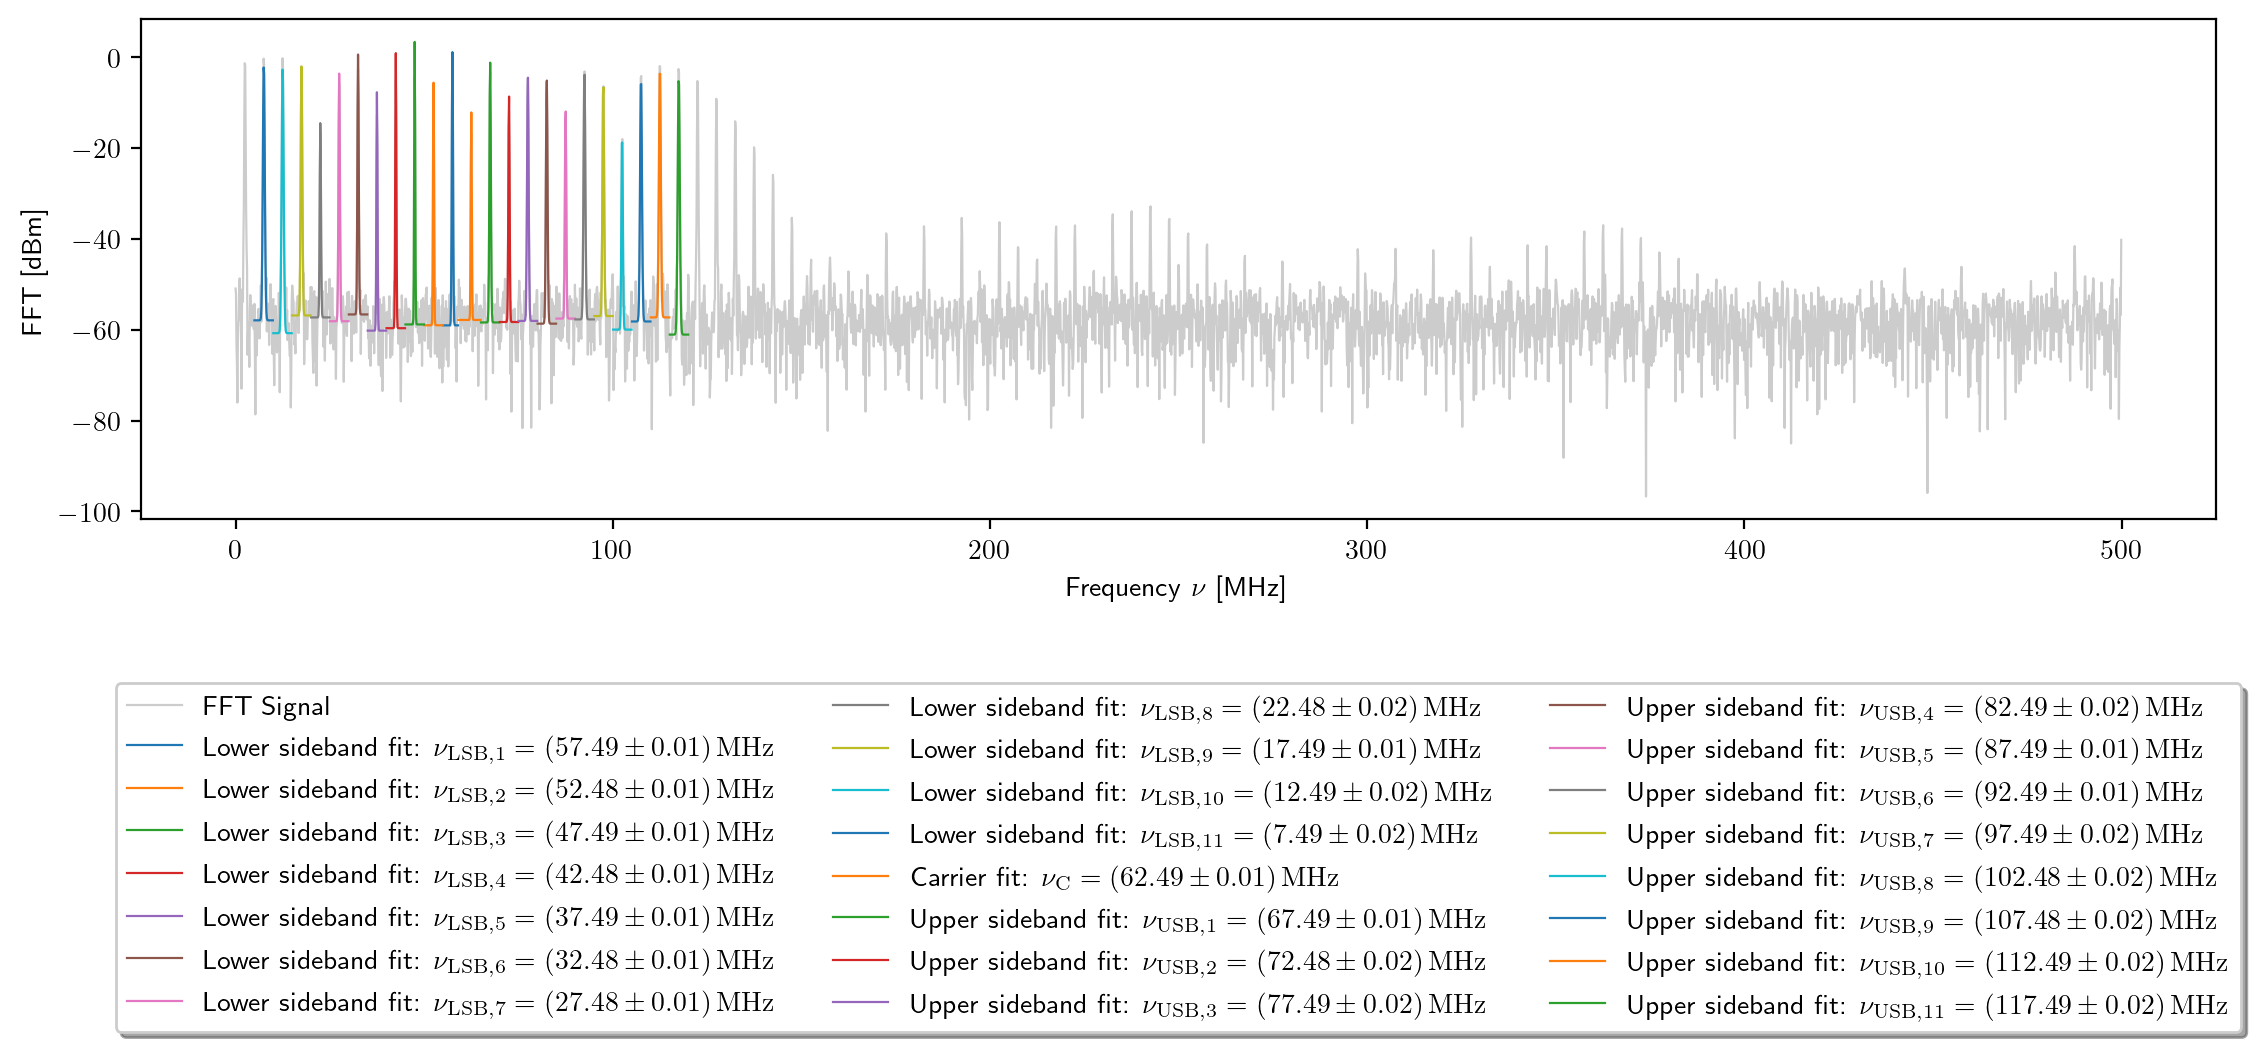

In [21]:
A3_600_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_26.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_600_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]
#freq_err = freq * 50e-6      # 50 ppm absolute
#ch1_err = 0.02 * np.abs(ch1) 

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

#fmin_lower_1, fmax_lower_1 = 
#fmin_lower_2, fmax_lower_2 = 
fmin_lower_11, fmax_lower_11 = 5, 10
fmin_lower_10, fmax_lower_10 = 10, 15
fmin_lower_9, fmax_lower_9 = 15, 20
fmin_lower_8, fmax_lower_8 = 20, 25
fmin_lower_7, fmax_lower_7 = 25, 30
fmin_lower_6, fmax_lower_6 = 30, 35
fmin_lower_5, fmax_lower_5 = 35, 40
fmin_lower_4, fmax_lower_4 = 40, 45
fmin_lower_3, fmax_lower_3 = 45, 50
fmin_lower_2, fmax_lower_2 = 50, 55
fmin_lower_1, fmax_lower_1 = 55, 59


fmin_carrier, fmax_carrier = 59, 65

fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75
fmin_upper_3, fmax_upper_3 = 75,80
fmin_upper_4, fmax_upper_4 = 80, 85
fmin_upper_5, fmax_upper_5 = 85, 90
fmin_upper_6, fmax_upper_6 = 90, 95
fmin_upper_7, fmax_upper_7 = 95, 100
fmin_upper_8, fmax_upper_8 = 100, 105
fmin_upper_9, fmax_upper_9 = 105, 110
fmin_upper_10, fmax_upper_10 = 110, 115
fmin_upper_11, fmax_upper_11 = 115, 120

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(12,6), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_l_3, func_l_3, popt_l_3, pcov_l_3, chi2_l_3 = fit_peak(freq, ch1, fmin_lower_3, fmax_lower_3, "gauss")
f_l_4, func_l_4, popt_l_4, pcov_l_4, chi2_l_4 = fit_peak(freq, ch1, fmin_lower_4, fmax_lower_4, "gauss")
f_l_5, func_l_5, popt_l_5, pcov_l_5, chi2_l_5 = fit_peak(freq, ch1, fmin_lower_5, fmax_lower_5, "gauss")
f_l_6, func_l_6, popt_l_6, pcov_l_6, chi2_l_6 = fit_peak(freq, ch1, fmin_lower_6, fmax_lower_6, "gauss")
f_l_7, func_l_7, popt_l_7, pcov_l_7, chi2_l_7 = fit_peak(freq, ch1, fmin_lower_7, fmax_lower_7, "gauss")
f_l_8, func_l_8, popt_l_8, pcov_l_8, chi2_l_8 = fit_peak(freq, ch1, fmin_lower_8, fmax_lower_8, "gauss")
f_l_9, func_l_9, popt_l_9, pcov_l_9, chi2_l_9 = fit_peak(freq, ch1, fmin_lower_9, fmax_lower_9, "gauss")
f_l_10, func_l_10, popt_l_10, pcov_l_10, chi2_l_10 = fit_peak(freq, ch1, fmin_lower_10, fmax_lower_10, "gauss")
f_l_11, func_l_11, popt_l_11, pcov_l_11, chi2_l_11 = fit_peak(freq, ch1, fmin_lower_11, fmax_lower_11, "gauss")

f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")

f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")
f_u_3, func_u_3, popt_u_3, pcov_u_3, chi2_u_3 = fit_peak(freq, ch1, fmin_upper_3, fmax_upper_3, "gauss")
f_u_4, func_u_4, popt_u_4, pcov_u_4, chi2_u_4 = fit_peak(freq, ch1, fmin_upper_4, fmax_upper_4, "gauss")
f_u_5, func_u_5, popt_u_5, pcov_u_5, chi2_u_5 = fit_peak(freq, ch1, fmin_upper_5, fmax_upper_5, "gauss")
f_u_6, func_u_6, popt_u_6, pcov_u_6, chi2_u_6 = fit_peak(freq, ch1, fmin_upper_6, fmax_upper_6, "gauss")
f_u_7, func_u_7, popt_u_7, pcov_u_7, chi2_u_7 = fit_peak(freq, ch1, fmin_upper_7, fmax_upper_7, "gauss")
f_u_8, func_u_8, popt_u_8, pcov_u_8, chi2_u_8 = fit_peak(freq, ch1, fmin_upper_8, fmax_upper_8, "gauss")
f_u_9, func_u_9, popt_u_9, pcov_u_9, chi2_u_9 = fit_peak(freq, ch1, fmin_upper_9, fmax_upper_9, "gauss")
f_u_10, func_u_10, popt_u_10, pcov_u_10, chi2_u_10 = fit_peak(freq, ch1, fmin_upper_10, fmax_upper_10, "gauss")
f_u_11, func_u_11, popt_u_11, pcov_u_11, chi2_u_11 = fit_peak(freq, ch1, fmin_upper_11, fmax_upper_11, "gauss")

plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_3, func_l_3(f_l_3, *popt_l_3), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,3}}}}=({popt_l_3[1]:.2f}\pm {np.sqrt(pcov_l_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_4, func_l_4(f_l_4, *popt_l_4), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,4}}}}=({popt_l_4[1]:.2f}\pm {np.sqrt(pcov_l_4[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_5, func_l_5(f_l_5, *popt_l_5), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,5}}}}=({popt_l_5[1]:.2f}\pm {np.sqrt(pcov_l_5[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_6, func_l_6(f_l_6, *popt_l_6), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,6}}}}=({popt_l_6[1]:.2f}\pm {np.sqrt(pcov_l_6[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_7, func_l_7(f_l_7, *popt_l_7), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,7}}}}=({popt_l_7[1]:.2f}\pm {np.sqrt(pcov_l_7[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_8, func_l_8(f_l_8, *popt_l_8), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,8}}}}=({popt_l_8[1]:.2f}\pm {np.sqrt(pcov_l_8[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_9, func_l_9(f_l_9, *popt_l_9), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,9}}}}=({popt_l_9[1]:.2f}\pm {np.sqrt(pcov_l_9[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_10, func_l_10(f_l_10, *popt_l_10), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,10}}}}=({popt_l_10[1]:.2f}\pm {np.sqrt(pcov_l_10[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_11, func_l_11(f_l_11, *popt_l_11), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,11}}}}=({popt_l_11[1]:.2f}\pm {np.sqrt(pcov_l_11[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_3, func_u_3(f_u_3, *popt_u_3), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,3}}}}=({popt_u_3[1]:.2f}\pm {np.sqrt(pcov_u_3[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_4, func_u_4(f_u_4, *popt_u_4), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,4}}}}=({popt_u_4[1]:.2f}\pm {np.sqrt(pcov_u_4[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_5, func_u_5(f_u_5, *popt_u_5), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,5}}}}=({popt_u_5[1]:.2f}\pm {np.sqrt(pcov_u_5[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_6, func_u_6(f_u_6, *popt_u_6), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,6}}}}=({popt_u_6[1]:.2f}\pm {np.sqrt(pcov_u_6[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_7, func_u_7(f_u_7, *popt_u_7), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,7}}}}=({popt_u_7[1]:.2f}\pm {np.sqrt(pcov_u_7[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_8, func_u_8(f_u_8, *popt_u_8), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,8}}}}=({popt_u_8[1]:.2f}\pm {np.sqrt(pcov_u_8[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_9, func_u_9(f_u_9, *popt_u_9), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,9}}}}=({popt_u_9[1]:.2f}\pm {np.sqrt(pcov_u_9[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_10, func_u_10(f_u_10, *popt_u_10), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,10}}}}=({popt_u_10[1]:.2f}\pm {np.sqrt(pcov_u_10[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_11, func_u_11(f_u_11, *popt_u_11), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,11}}}}=({popt_u_11[1]:.2f}\pm {np.sqrt(pcov_u_11[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
#plt.xlim(0, 140)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=3)


plt.tight_layout()
plt.savefig("A3_600_FFT.pdf", bbox_inches="tight")


from scipy.special import jv

kFM = 12

A_theo_1 = jv(1, kFM) / jv(0, kFM)
A_theo_2 = jv(2, kFM) / jv(0, kFM)
A_theo_3 = jv(3, kFM) / jv(0, kFM)
A_theo_4 = jv(4, kFM) / jv(0, kFM)
A_theo_5 = jv(5, kFM) / jv(0, kFM)
A_theo_6 = jv(6, kFM) / jv(0, kFM)
A_theo_7 = jv(7, kFM) / jv(0, kFM)
A_theo_8 = jv(8, kFM) / jv(0, kFM)
A_theo_9 = jv(9, kFM) / jv(0, kFM)
A_theo_10 = jv(10, kFM) / jv(0, kFM)
A_theo_11 = jv(11, kFM) / jv(0, kFM)

# Peak amplitudes
P_LSB1, sP_LSB1 = peak_dBm_and_sigma_from_gauss(popt_l_1, pcov_l_1)
P_C,    sP_C    = peak_dBm_and_sigma_from_gauss(popt_c,   pcov_c)
P_USB1, sP_USB1 = peak_dBm_and_sigma_from_gauss(popt_u_1, pcov_u_1)

# dBm -> linear
A_LSB1, sA_LSB1 = dBm_to_lin_and_sigma(P_LSB1, sP_LSB1)
A_C,    sA_C    = dBm_to_lin_and_sigma(P_C,    sP_C)
A_USB1, sA_USB1 = dBm_to_lin_and_sigma(P_USB1, sP_USB1)

# relative amplitudes
Arel_LSB1 = A_LSB1 / A_C
Arel_USB1 = A_USB1 / A_C
Arel_mean_1 = 0.5 * (Arel_LSB1 + Arel_USB1)

# errors
sArel_LSB1 = Arel_LSB1 * np.sqrt((sA_LSB1/A_LSB1)**2 + (sA_C/A_C)**2)
sArel_USB1 = Arel_USB1 * np.sqrt((sA_USB1/A_USB1)**2 + (sA_C/A_C)**2)
sArel_mean_1 = 0.5 * np.sqrt(sArel_LSB1**2 + sArel_USB1**2)

# n = 2
P_LSB2, sP_LSB2 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_USB2, sP_USB2 = peak_dBm_and_sigma_from_gauss(popt_u_2, pcov_u_2)

A_LSB2, sA_LSB2 = dBm_to_lin_and_sigma(P_LSB2, sP_LSB2)
A_USB2, sA_USB2 = dBm_to_lin_and_sigma(P_USB2, sP_USB2)

Arel_LSB2 = A_LSB2 / A_C
Arel_USB2 = A_USB2 / A_C
Arel_mean_2 = 0.5 * (Arel_LSB2 + Arel_USB2)

sArel_LSB2 = Arel_LSB2 * np.sqrt((sA_LSB2/A_LSB2)**2 + (sA_C/A_C)**2)
sArel_USB2 = Arel_USB2 * np.sqrt((sA_USB2/A_USB2)**2 + (sA_C/A_C)**2)
sArel_mean_2 = 0.5 * np.sqrt(sArel_LSB2**2 + sArel_USB2**2)

# n = 3
P_LSB3, sP_LSB3 = peak_dBm_and_sigma_from_gauss(popt_l_3, pcov_l_3)
P_USB3, sP_USB3 = peak_dBm_and_sigma_from_gauss(popt_u_3, pcov_u_3)

A_LSB3, sA_LSB3 = dBm_to_lin_and_sigma(P_LSB3, sP_LSB3)
A_USB3, sA_USB3 = dBm_to_lin_and_sigma(P_USB3, sP_USB3)

Arel_LSB3 = A_LSB3 / A_C
Arel_USB3 = A_USB3 / A_C
Arel_mean_3 = 0.5 * (Arel_LSB3 + Arel_USB3)

sArel_LSB3 = Arel_LSB3 * np.sqrt((sA_LSB3/A_LSB3)**2 + (sA_C/A_C)**2)
sArel_USB3 = Arel_USB3 * np.sqrt((sA_USB3/A_USB3)**2 + (sA_C/A_C)**2)
sArel_mean_3 = 0.5 * np.sqrt(sArel_LSB3**2 + sArel_USB3**2)

# n = 4
P_LSB4, sP_LSB4 = peak_dBm_and_sigma_from_gauss(popt_l_4, pcov_l_4)
P_USB4, sP_USB4 = peak_dBm_and_sigma_from_gauss(popt_u_4, pcov_u_4)

A_LSB4, sA_LSB4 = dBm_to_lin_and_sigma(P_LSB4, sP_LSB4)
A_USB4, sA_USB4 = dBm_to_lin_and_sigma(P_USB4, sP_USB4)

Arel_LSB4 = A_LSB4 / A_C
Arel_USB4 = A_USB4 / A_C
Arel_mean_4 = 0.5 * (Arel_LSB4 + Arel_USB4)

sArel_LSB4 = Arel_LSB4 * np.sqrt((sA_LSB4/A_LSB4)**2 + (sA_C/A_C)**2)
sArel_USB4 = Arel_USB4 * np.sqrt((sA_USB4/A_USB4)**2 + (sA_C/A_C)**2)
sArel_mean_4 = 0.5 * np.sqrt(sArel_LSB4**2 + sArel_USB4**2)

# n = 5
P_LSB5, sP_LSB5 = peak_dBm_and_sigma_from_gauss(popt_l_5, pcov_l_5)
P_USB5, sP_USB5 = peak_dBm_and_sigma_from_gauss(popt_u_5, pcov_u_5)

A_LSB5, sA_LSB5 = dBm_to_lin_and_sigma(P_LSB5, sP_LSB5)
A_USB5, sA_USB5 = dBm_to_lin_and_sigma(P_USB5, sP_USB5)

Arel_LSB5 = A_LSB5 / A_C
Arel_USB5 = A_USB5 / A_C
Arel_mean_5 = 0.5 * (Arel_LSB5 + Arel_USB5)

sArel_LSB5 = Arel_LSB5 * np.sqrt((sA_LSB5/A_LSB5)**2 + (sA_C/A_C)**2)
sArel_USB5 = Arel_USB5 * np.sqrt((sA_USB5/A_USB5)**2 + (sA_C/A_C)**2)
sArel_mean_5 = 0.5 * np.sqrt(sArel_LSB5**2 + sArel_USB5**2)

# n = 6
P_LSB6, sP_LSB6 = peak_dBm_and_sigma_from_gauss(popt_l_6, pcov_l_6)
P_USB6, sP_USB6 = peak_dBm_and_sigma_from_gauss(popt_u_6, pcov_u_6)

A_LSB6, sA_LSB6 = dBm_to_lin_and_sigma(P_LSB6, sP_LSB6)
A_USB6, sA_USB6 = dBm_to_lin_and_sigma(P_USB6, sP_USB6)

Arel_LSB6 = A_LSB6 / A_C
Arel_USB6 = A_USB6 / A_C
Arel_mean_6 = 0.5 * (Arel_LSB6 + Arel_USB6)

sArel_LSB6 = Arel_LSB6 * np.sqrt((sA_LSB6/A_LSB6)**2 + (sA_C/A_C)**2)
sArel_USB6 = Arel_USB6 * np.sqrt((sA_USB6/A_USB6)**2 + (sA_C/A_C)**2)
sArel_mean_6 = 0.5 * np.sqrt(sArel_LSB6**2 + sArel_USB6**2)

# n = 7
P_LSB7, sP_LSB7 = peak_dBm_and_sigma_from_gauss(popt_l_7, pcov_l_7)
P_USB7, sP_USB7 = peak_dBm_and_sigma_from_gauss(popt_u_7, pcov_u_7)

A_LSB7, sA_LSB7 = dBm_to_lin_and_sigma(P_LSB7, sP_LSB7)
A_USB7, sA_USB7 = dBm_to_lin_and_sigma(P_USB7, sP_USB7)

Arel_LSB7 = A_LSB7 / A_C
Arel_USB7 = A_USB7 / A_C
Arel_mean_7 = 0.5 * (Arel_LSB7 + Arel_USB7)

sArel_LSB7 = Arel_LSB7 * np.sqrt((sA_LSB7/A_LSB7)**2 + (sA_C/A_C)**2)
sArel_USB7 = Arel_USB7 * np.sqrt((sA_USB7/A_USB7)**2 + (sA_C/A_C)**2)
sArel_mean_7 = 0.5 * np.sqrt(sArel_LSB7**2 + sArel_USB7**2)

# n = 8
P_LSB8, sP_LSB8 = peak_dBm_and_sigma_from_gauss(popt_l_8, pcov_l_8)
P_USB8, sP_USB8 = peak_dBm_and_sigma_from_gauss(popt_u_8, pcov_u_8)

A_LSB8, sA_LSB8 = dBm_to_lin_and_sigma(P_LSB8, sP_LSB8)
A_USB8, sA_USB8 = dBm_to_lin_and_sigma(P_USB8, sP_USB8)

Arel_LSB8 = A_LSB8 / A_C
Arel_USB8 = A_USB8 / A_C
Arel_mean_8 = 0.5 * (Arel_LSB8 + Arel_USB8)

sArel_LSB8 = Arel_LSB8 * np.sqrt((sA_LSB8/A_LSB8)**2 + (sA_C/A_C)**2)
sArel_USB8 = Arel_USB8 * np.sqrt((sA_USB8/A_USB8)**2 + (sA_C/A_C)**2)
sArel_mean_8 = 0.5 * np.sqrt(sArel_LSB8**2 + sArel_USB8**2)

# n = 9
P_LSB9, sP_LSB9 = peak_dBm_and_sigma_from_gauss(popt_l_9, pcov_l_9)
P_USB9, sP_USB9 = peak_dBm_and_sigma_from_gauss(popt_u_9, pcov_u_9)

A_LSB9, sA_LSB9 = dBm_to_lin_and_sigma(P_LSB9, sP_LSB9)
A_USB9, sA_USB9 = dBm_to_lin_and_sigma(P_USB9, sP_USB9)

Arel_LSB9 = A_LSB9 / A_C
Arel_USB9 = A_USB9 / A_C
Arel_mean_9 = 0.5 * (Arel_LSB9 + Arel_USB9)

sArel_LSB9 = Arel_LSB9 * np.sqrt((sA_LSB9/A_LSB9)**2 + (sA_C/A_C)**2)
sArel_USB9 = Arel_USB9 * np.sqrt((sA_USB9/A_USB9)**2 + (sA_C/A_C)**2)
sArel_mean_9 = 0.5 * np.sqrt(sArel_LSB9**2 + sArel_USB9**2)

# n = 10
P_LSB10, sP_LSB10 = peak_dBm_and_sigma_from_gauss(popt_l_10, pcov_l_10)
P_USB10, sP_USB10 = peak_dBm_and_sigma_from_gauss(popt_u_10, pcov_u_10)

A_LSB10, sA_LSB10 = dBm_to_lin_and_sigma(P_LSB10, sP_LSB10)
A_USB10, sA_USB10 = dBm_to_lin_and_sigma(P_USB10, sP_USB10)

Arel_LSB10 = A_LSB10 / A_C
Arel_USB10 = A_USB10 / A_C
Arel_mean_10 = 0.5 * (Arel_LSB10 + Arel_USB10)

sArel_LSB10 = Arel_LSB10 * np.sqrt((sA_LSB10/A_LSB10)**2 + (sA_C/A_C)**2)
sArel_USB10 = Arel_USB10 * np.sqrt((sA_USB10/A_USB10)**2 + (sA_C/A_C)**2)
sArel_mean_10 = 0.5 * np.sqrt(sArel_LSB10**2 + sArel_USB10**2)

# n = 11
P_LSB11, sP_LSB11 = peak_dBm_and_sigma_from_gauss(popt_l_11, pcov_l_11)
P_USB11, sP_USB11 = peak_dBm_and_sigma_from_gauss(popt_u_11, pcov_u_11)

A_LSB11, sA_LSB11 = dBm_to_lin_and_sigma(P_LSB11, sP_LSB11)
A_USB11, sA_USB11 = dBm_to_lin_and_sigma(P_USB11, sP_USB11)

Arel_LSB11 = A_LSB11 / A_C
Arel_USB11 = A_USB11 / A_C
Arel_mean_11 = 0.5 * (Arel_LSB11 + Arel_USB11)

sArel_LSB11 = Arel_LSB11 * np.sqrt((sA_LSB11/A_LSB11)**2 + (sA_C/A_C)**2)
sArel_USB11 = Arel_USB11 * np.sqrt((sA_USB11/A_USB11)**2 + (sA_C/A_C)**2)
sArel_mean_11 = 0.5 * np.sqrt(sArel_LSB11**2 + sArel_USB11**2)

print("kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean")

print(f"{kFM:.1f}  1  "
      f"{A_theo_1:.4f}  "
      f"{Arel_LSB1:.3f}({sArel_LSB1:.3f})  "
      f"{Arel_USB1:.3f}({sArel_USB1:.3f})  "
      f"{Arel_mean_1:.3f}({sArel_mean_1:.3f})")

print(f"{kFM:.1f}  2  "
      f"{A_theo_2:.4f}  "
      f"{Arel_LSB2:.3f}({sArel_LSB2:.3f})  "
      f"{Arel_USB2:.3f}({sArel_USB2:.3f})  "
      f"{Arel_mean_2:.3f}({sArel_mean_2:.3f})")

print(f"{kFM:.1f}  3  "
      f"{A_theo_3:.4f}  "
      f"{Arel_LSB3:.3f}({sArel_LSB3:.3f})  "
      f"{Arel_USB3:.3f}({sArel_USB3:.3f})  "
      f"{Arel_mean_3:.3f}({sArel_mean_3:.3f})")

print(f"{kFM:.1f}  4  "
      f"{A_theo_4:.4f}  "
      f"{Arel_LSB4:.3f}({sArel_LSB4:.3f})  "
      f"{Arel_USB4:.3f}({sArel_USB4:.3f})  "
      f"{Arel_mean_4:.3f}({sArel_mean_4:.3f})")

print(f"{kFM:.1f}  5  "
      f"{A_theo_5:.4f}  "
      f"{Arel_LSB5:.3f}({sArel_LSB5:.3f})  "
      f"{Arel_USB5:.3f}({sArel_USB5:.3f})  "
      f"{Arel_mean_5:.3f}({sArel_mean_5:.3f})")

print(f"{kFM:.1f}  6  "
      f"{A_theo_6:.4f}  "
      f"{Arel_LSB6:.3f}({sArel_LSB6:.3f})  "
      f"{Arel_USB6:.3f}({sArel_USB6:.3f})  "
      f"{Arel_mean_6:.3f}({sArel_mean_6:.3f})")

print(f"{kFM:.1f}  7  "
      f"{A_theo_7:.4f}  "
      f"{Arel_LSB7:.3f}({sArel_LSB7:.3f})  "
      f"{Arel_USB7:.3f}({sArel_USB7:.3f})  "
      f"{Arel_mean_7:.3f}({sArel_mean_7:.3f})")

print(f"{kFM:.1f}  8  "
      f"{A_theo_8:.4f}  "
      f"{Arel_LSB8:.3f}({sArel_LSB8:.3f})  "
      f"{Arel_USB8:.3f}({sArel_USB8:.3f})  "
      f"{Arel_mean_8:.3f}({sArel_mean_8:.3f})")

print(f"{kFM:.1f}  9  "
      f"{A_theo_9:.4f}  "
      f"{Arel_LSB9:.3f}({sArel_LSB9:.3f})  "
      f"{Arel_USB9:.3f}({sArel_USB9:.3f})  "
      f"{Arel_mean_9:.3f}({sArel_mean_9:.3f})")

print(f"{kFM:.1f}  10  "
      f"{A_theo_10:.4f}  "
      f"{Arel_LSB10:.3f}({sArel_LSB10:.3f})  "
      f"{Arel_USB10:.3f}({sArel_USB10:.3f})  "
      f"{Arel_mean_10:.3f}({sArel_mean_10:.3f})")

print(f"{kFM:.1f}  11  "
      f"{A_theo_11:.4f}  "
      f"{Arel_LSB11:.3f}({sArel_LSB11:.3f})  "
      f"{Arel_USB11:.3f}({sArel_USB11:.3f})  "
      f"{Arel_mean_11:.3f}({sArel_mean_11:.3f})")

### Modulation Index = 10/50=0.2 -> Sidebands = 2 (k_FM + 1 ) approx 3 bands 

kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean
0.2  1  0.1005  0.058(0.048)  0.068(0.062)  0.063(0.039)


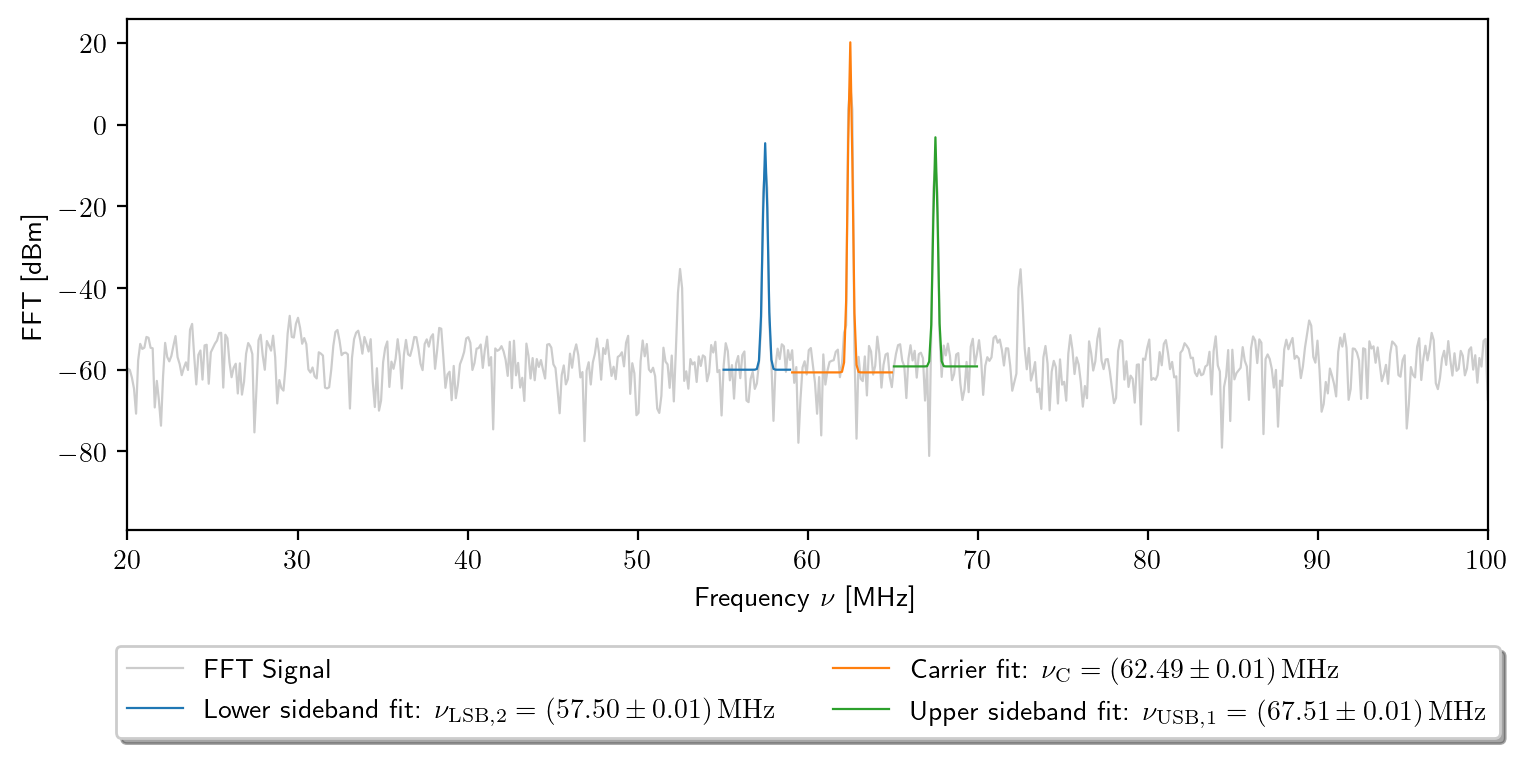

In [22]:
A3_10_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_15.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_10_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]
#freq_err = freq * 50e-6      # 50 ppm absolute
#ch1_err = 0.02 * np.abs(ch1) 

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower_1, fmax_lower_1 = 50, 55
fmin_lower_2, fmax_lower_2 = 55, 59
fmin_carrier, fmax_carrier = 59, 65
fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")

#plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
#plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A3_10_FFT.pdf", bbox_inches="tight")


from scipy.special import jv

kFM = 0.2

A_theo_1 = jv(1, kFM) / jv(0, kFM)
#A_theo_2 = jv(2, kFM) / jv(0, kFM)

# Peak amplitudes
P_LSB1, sP_LSB1 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_C,    sP_C    = peak_dBm_and_sigma_from_gauss(popt_c,   pcov_c)
P_USB1, sP_USB1 = peak_dBm_and_sigma_from_gauss(popt_u_1, pcov_u_1)

# dBm -> linear
A_LSB1, sA_LSB1 = dBm_to_lin_and_sigma(P_LSB1, sP_LSB1)
A_C,    sA_C    = dBm_to_lin_and_sigma(P_C,    sP_C)
A_USB1, sA_USB1 = dBm_to_lin_and_sigma(P_USB1, sP_USB1)

# relative amplitudes
Arel_LSB1 = A_LSB1 / A_C
Arel_USB1 = A_USB1 / A_C
Arel_mean_1 = 0.5 * (Arel_LSB1 + Arel_USB1)

# errors
sArel_LSB1 = Arel_LSB1 * np.sqrt((sA_LSB1/A_LSB1)**2 + (sA_C/A_C)**2)
sArel_USB1 = Arel_USB1 * np.sqrt((sA_USB1/A_USB1)**2 + (sA_C/A_C)**2)
sArel_mean_1 = 0.5 * np.sqrt(sArel_LSB1**2 + sArel_USB1**2)

P_LSB2, sP_LSB2 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_USB2, sP_USB2 = peak_dBm_and_sigma_from_gauss(popt_u_2, pcov_u_2)

A_LSB2, sA_LSB2 = dBm_to_lin_and_sigma(P_LSB2, sP_LSB2)
A_USB2, sA_USB2 = dBm_to_lin_and_sigma(P_USB2, sP_USB2)

Arel_LSB2 = A_LSB2 / A_C
Arel_USB2 = A_USB2 / A_C
Arel_mean_2 = 0.5 * (Arel_LSB2 + Arel_USB2)

sArel_LSB2 = Arel_LSB2 * np.sqrt((sA_LSB2/A_LSB2)**2 + (sA_C/A_C)**2)
sArel_USB2 = Arel_USB2 * np.sqrt((sA_USB2/A_USB2)**2 + (sA_C/A_C)**2)
sArel_mean_2 = 0.5 * np.sqrt(sArel_LSB2**2 + sArel_USB2**2)

print("kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean")

print(f"{kFM:.1f}  1  "
      f"{A_theo_1:.4f}  "
      f"{Arel_LSB1:.3f}({sArel_LSB1:.3f})  "
      f"{Arel_USB1:.3f}({sArel_USB1:.3f})  "
      f"{Arel_mean_1:.3f}({sArel_mean_1:.3f})")

#print(f"{kFM:.1f}  2  "
#      f"{A_theo_2:.4f}  "
#      f"{Arel_LSB2:.3f}({sArel_LSB2:.3f})  "
#      f"{Arel_USB2:.3f}({sArel_USB2:.3f})  "
#      f"{Arel_mean_2:.3f}({sArel_mean_2:.3f})")



### Modulation Index = 5/50=0.1 -> Sidebands = 2 (k_FM + 1 ) approx 3 bands 

kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean
0.1  1  0.0501  0.058(0.048)  0.068(0.062)  0.063(0.039)


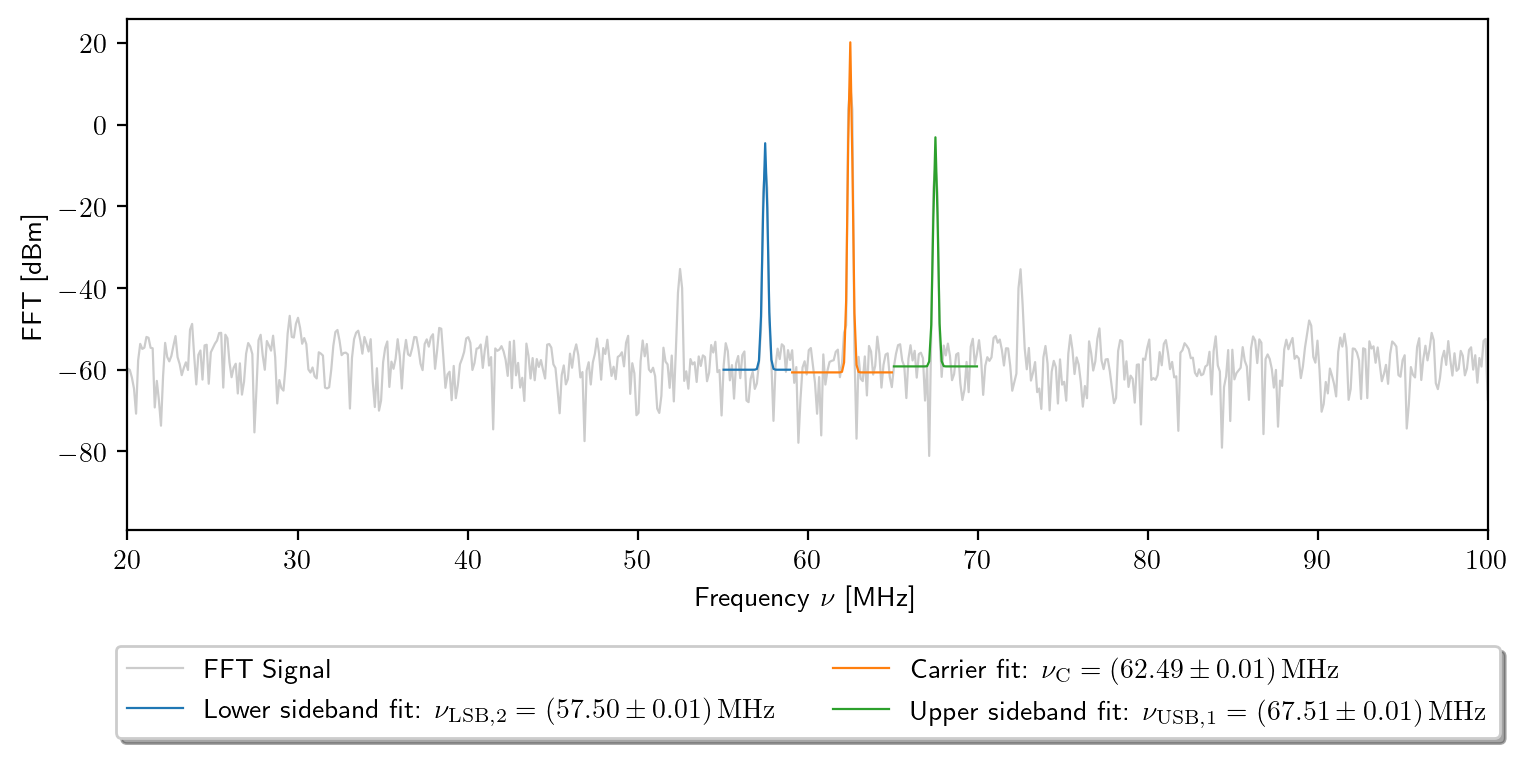

In [23]:
A3_10_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_15.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_10_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]
#freq_err = freq * 50e-6      # 50 ppm absolute
#ch1_err = 0.02 * np.abs(ch1) 

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower_1, fmax_lower_1 = 50, 55
fmin_lower_2, fmax_lower_2 = 55, 59
fmin_carrier, fmax_carrier = 59, 65
fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")

#plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
#plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A3_10_FFT.pdf", bbox_inches="tight")


from scipy.special import jv

kFM = 0.1

A_theo_1 = jv(1, kFM) / jv(0, kFM)
#A_theo_2 = jv(2, kFM) / jv(0, kFM)

# Peak amplitudes
P_LSB1, sP_LSB1 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_C,    sP_C    = peak_dBm_and_sigma_from_gauss(popt_c,   pcov_c)
P_USB1, sP_USB1 = peak_dBm_and_sigma_from_gauss(popt_u_1, pcov_u_1)

# dBm -> linear
A_LSB1, sA_LSB1 = dBm_to_lin_and_sigma(P_LSB1, sP_LSB1)
A_C,    sA_C    = dBm_to_lin_and_sigma(P_C,    sP_C)
A_USB1, sA_USB1 = dBm_to_lin_and_sigma(P_USB1, sP_USB1)

# relative amplitudes
Arel_LSB1 = A_LSB1 / A_C
Arel_USB1 = A_USB1 / A_C
Arel_mean_1 = 0.5 * (Arel_LSB1 + Arel_USB1)

# errors
sArel_LSB1 = Arel_LSB1 * np.sqrt((sA_LSB1/A_LSB1)**2 + (sA_C/A_C)**2)
sArel_USB1 = Arel_USB1 * np.sqrt((sA_USB1/A_USB1)**2 + (sA_C/A_C)**2)
sArel_mean_1 = 0.5 * np.sqrt(sArel_LSB1**2 + sArel_USB1**2)

P_LSB2, sP_LSB2 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_USB2, sP_USB2 = peak_dBm_and_sigma_from_gauss(popt_u_2, pcov_u_2)

A_LSB2, sA_LSB2 = dBm_to_lin_and_sigma(P_LSB2, sP_LSB2)
A_USB2, sA_USB2 = dBm_to_lin_and_sigma(P_USB2, sP_USB2)

Arel_LSB2 = A_LSB2 / A_C
Arel_USB2 = A_USB2 / A_C
Arel_mean_2 = 0.5 * (Arel_LSB2 + Arel_USB2)

sArel_LSB2 = Arel_LSB2 * np.sqrt((sA_LSB2/A_LSB2)**2 + (sA_C/A_C)**2)
sArel_USB2 = Arel_USB2 * np.sqrt((sA_USB2/A_USB2)**2 + (sA_C/A_C)**2)
sArel_mean_2 = 0.5 * np.sqrt(sArel_LSB2**2 + sArel_USB2**2)

print("kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean")

print(f"{kFM:.1f}  1  "
      f"{A_theo_1:.4f}  "
      f"{Arel_LSB1:.3f}({sArel_LSB1:.3f})  "
      f"{Arel_USB1:.3f}({sArel_USB1:.3f})  "
      f"{Arel_mean_1:.3f}({sArel_mean_1:.3f})")

#print(f"{kFM:.1f}  2  "
#      f"{A_theo_2:.4f}  "
#      f"{Arel_LSB2:.3f}({sArel_LSB2:.3f})  "
#      f"{Arel_USB2:.3f}({sArel_USB2:.3f})  "
#      f"{Arel_mean_2:.3f}({sArel_mean_2:.3f})")



### Modulation Index = 50/50=1 -> Sidebands = 2 (k_FM + 1 ) approx 5 bands 

kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean
1.0  1  0.5751  0.399(0.319)  0.314(0.255)  0.357(0.204)
1.0  2  0.1502  0.091(0.075)  0.088(0.082)  0.090(0.056)


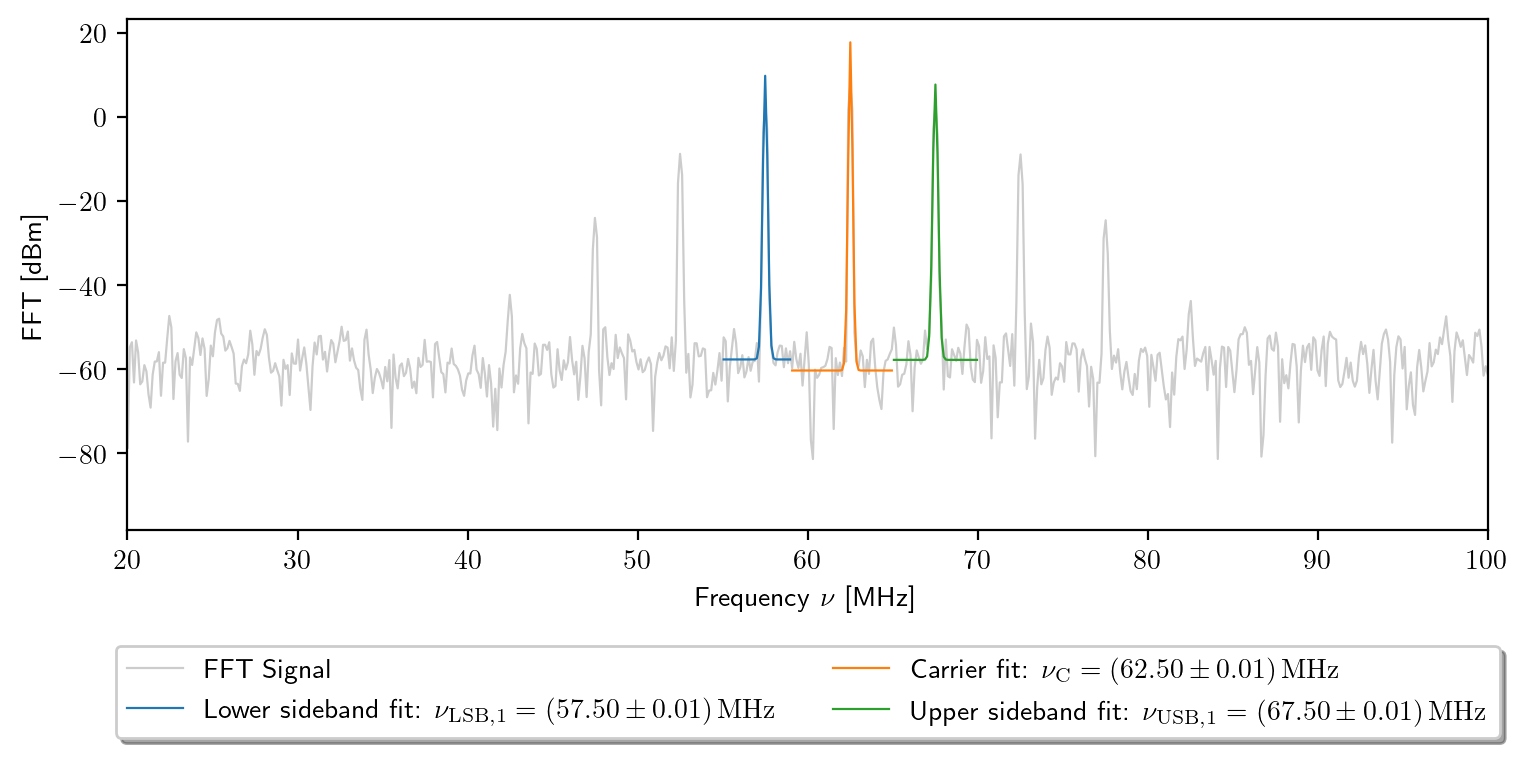

In [24]:
A3_50_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG02/FFT_11.CSV" #insert path name, if code is reused please modify
data = pd.read_csv(A3_50_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq = data["time"]
freq = (freq - freq[0]) / 10e3
ch1 = data["CH1"]
#freq_err = freq * 50e-6      # 50 ppm absolute
#ch1_err = 0.02 * np.abs(ch1) 

def gauss(f, A, f0, sigma, C):
    return A * np.exp(-(f - f0)**2 / (2 * sigma**2)) + C

def fit_peak(freq, amp, fmin, fmax, model):
    freq = np.asarray(freq)
    amp  = np.asarray(amp)
    mask = (freq > fmin) & (freq < fmax)
    f = freq[mask]
    y = amp[mask]

    A0 = np.max(y) - np.min(y)
    f0 = f[np.argmax(y)]
    width = (fmax - fmin) / 10
    C0 = np.min(y)

    if model == "gauss":
        func = gauss
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "lorentz":
        func = lorentz
        p0 = [A0, f0, width, C0]
        npar = 4
    elif model == "voigt":
        func = voigt
        p0 = [A0, f0, width, width, C0]
        npar = 5

    popt, pcov = curve_fit(func, f, y, p0=p0, maxfev=10000)

    y_fit = func(f, *popt)
    sigma = np.std(y - y_fit)
    chi2 = np.sum(((y - y_fit)/sigma)**2)
    chi2_red = chi2 / (len(y) - npar)

    return f, func, popt, pcov, chi2_red

fmin_lower_2, fmax_lower_2 = 50, 55
fmin_lower_1, fmax_lower_1 = 55, 59
fmin_carrier, fmax_carrier = 59, 65
fmin_upper_1, fmax_upper_1 = 65, 70
fmin_upper_2, fmax_upper_2 = 70, 75

LN10_OVER_20 = np.log(10)/20

def peak_dBm_and_sigma_from_gauss(popt, pcov):
    # popt = [A, f0, sigma, C]
    A = popt[0]
    C = popt[3]
    P = A + C

    varA = pcov[0,0]
    varC = pcov[3,3]
    covAC = pcov[0,3]
    sigmaP = np.sqrt(varA + varC + 2*covAC)

    return P, sigmaP

def dBm_to_lin_and_sigma(P_dBm, sigmaP_dBm):
    A_lin = 10**(P_dBm/20)
    sigmaA_lin = A_lin * LN10_OVER_20 * sigmaP_dBm
    return A_lin, sigmaA_lin

def kAM_and_sigma(A_SB, sA_SB, A_C, sA_C):
    k = 2 * A_SB / A_C
    sk = k * np.sqrt((sA_SB/A_SB)**2 + (sA_C/A_C)**2)
    return k, sk


plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq, ch1, color="gray", alpha=0.4, linewidth=0.8, label=r"FFT Signal")

f_l_1, func_l_1, popt_l_1, pcov_l_1, chi2_l_1 = fit_peak(freq, ch1, fmin_lower_1, fmax_lower_1, "gauss")
f_l_2, func_l_2, popt_l_2, pcov_l_2, chi2_l_2 = fit_peak(freq, ch1, fmin_lower_2, fmax_lower_2, "gauss")
f_c, func_c, popt_c, pcov_c, chi2_c = fit_peak(freq, ch1, fmin_carrier, fmax_carrier, "gauss")
f_u_1, func_u_1, popt_u_1, pcov_u_1, chi2_u_1 = fit_peak(freq, ch1, fmin_upper_1, fmax_upper_1, "gauss")
f_u_2, func_u_2, popt_u_2, pcov_u_2, chi2_u_2 = fit_peak(freq, ch1, fmin_upper_2, fmax_upper_2, "gauss")

plt.plot(f_l_1, func_l_1(f_l_1, *popt_l_1), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,1}}}}=({popt_l_1[1]:.2f}\pm {np.sqrt(pcov_l_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
#plt.plot(f_l_2, func_l_2(f_l_2, *popt_l_2), linewidth=0.8, label=rf"Lower sideband fit: $\nu_{{\mathrm{{LSB,2}}}}=({popt_l_2[1]:.2f}\pm {np.sqrt(pcov_l_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_c, func_c(f_c, *popt_c), linewidth=0.8, label=rf"Carrier fit: $\nu_{{\mathrm{{C}}}}=({popt_c[1]:.2f}\pm {np.sqrt(pcov_c[1,1]):.2f})\,$$\mathrm{{MHz}}$")
plt.plot(f_u_1, func_u_1(f_u_1, *popt_u_1), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,1}}}}=({popt_u_1[1]:.2f}\pm {np.sqrt(pcov_u_1[1,1]):.2f})\,$$\mathrm{{MHz}}$")
#plt.plot(f_u_2, func_u_2(f_u_2, *popt_u_2), linewidth=0.8, label=rf"Upper sideband fit: $\nu_{{\mathrm{{USB,2}}}}=({popt_u_2[1]:.2f}\pm {np.sqrt(pcov_u_2[1,1]):.2f})\,$$\mathrm{{MHz}}$")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A3_10_FFT.pdf", bbox_inches="tight")


from scipy.special import jv

kFM = 1

A_theo_1 = jv(1, kFM) / jv(0, kFM)
A_theo_2 = jv(2, kFM) / jv(0, kFM)

# Peak amplitudes
P_LSB1, sP_LSB1 = peak_dBm_and_sigma_from_gauss(popt_l_1, pcov_l_1)
P_C,    sP_C    = peak_dBm_and_sigma_from_gauss(popt_c,   pcov_c)
P_USB1, sP_USB1 = peak_dBm_and_sigma_from_gauss(popt_u_1, pcov_u_1)

# dBm -> linear
A_LSB1, sA_LSB1 = dBm_to_lin_and_sigma(P_LSB1, sP_LSB1)
A_C,    sA_C    = dBm_to_lin_and_sigma(P_C,    sP_C)
A_USB1, sA_USB1 = dBm_to_lin_and_sigma(P_USB1, sP_USB1)

# relative amplitudes
Arel_LSB1 = A_LSB1 / A_C
Arel_USB1 = A_USB1 / A_C
Arel_mean_1 = 0.5 * (Arel_LSB1 + Arel_USB1)

# errors
sArel_LSB1 = Arel_LSB1 * np.sqrt((sA_LSB1/A_LSB1)**2 + (sA_C/A_C)**2)
sArel_USB1 = Arel_USB1 * np.sqrt((sA_USB1/A_USB1)**2 + (sA_C/A_C)**2)
sArel_mean_1 = 0.5 * np.sqrt(sArel_LSB1**2 + sArel_USB1**2)

P_LSB2, sP_LSB2 = peak_dBm_and_sigma_from_gauss(popt_l_2, pcov_l_2)
P_USB2, sP_USB2 = peak_dBm_and_sigma_from_gauss(popt_u_2, pcov_u_2)

A_LSB2, sA_LSB2 = dBm_to_lin_and_sigma(P_LSB2, sP_LSB2)
A_USB2, sA_USB2 = dBm_to_lin_and_sigma(P_USB2, sP_USB2)

Arel_LSB2 = A_LSB2 / A_C
Arel_USB2 = A_USB2 / A_C
Arel_mean_2 = 0.5 * (Arel_LSB2 + Arel_USB2)

sArel_LSB2 = Arel_LSB2 * np.sqrt((sA_LSB2/A_LSB2)**2 + (sA_C/A_C)**2)
sArel_USB2 = Arel_USB2 * np.sqrt((sA_USB2/A_USB2)**2 + (sA_C/A_C)**2)
sArel_mean_2 = 0.5 * np.sqrt(sArel_LSB2**2 + sArel_USB2**2)

print("kFM  n   Jn/J0      Arel,LSB        Arel,USB        Arel,mean")

print(f"{kFM:.1f}  1  "
      f"{A_theo_1:.4f}  "
      f"{Arel_LSB1:.3f}({sArel_LSB1:.3f})  "
      f"{Arel_USB1:.3f}({sArel_USB1:.3f})  "
      f"{Arel_mean_1:.3f}({sArel_mean_1:.3f})")

print(f"{kFM:.1f}  2  "
      f"{A_theo_2:.4f}  "
      f"{Arel_LSB2:.3f}({sArel_LSB2:.3f})  "
      f"{Arel_USB2:.3f}({sArel_USB2:.3f})  "
      f"{Arel_mean_2:.3f}({sArel_mean_2:.3f})")



### Interpretation of the Results of Exercise 3, only using till n = 5 less than four values do not make sense in my opinion, however of course they are listed in the table in the report and the excel file

In [25]:
# n = 1
k_FM_1 = np.array([0.1, 0.2, 0.4, 0.8, 1, 2, 4, 6, 8, 10])
theoretical_value_1 = np.array([0.0501, 0.1005, 0.2041, 0.4358, 0.5751, 2.5759, 0.1663, 1.8367, 1.3669, 0.1768])
experimental_value_1 = np.array([0.063, 0.063, 0.109, 0.288, 0.357, 2.113, 0.135, 1.887, 1.280, 0.221])
experimental_value_err_1 = np.array([0.039, 0.039, 0.073, 0.180, 0.204, 1.529, 0.078, 0.983, 0.714, 0.122])

# n = 2
k_FM_2 = np.array([0.4, 0.8, 1, 2, 4, 6, 8, 10])
theoretical_value_2 = np.array([0.0205, 0.0896, 0.1502, 1.5759, 0.9169, 1.6122, 0.6583, 1.0354])
experimental_value_2 = np.array([0.009, 0.044, 0.090, 1.073, 0.595, 1.687, 0.634, 1.204])
experimental_value_err_2 = np.array([0.006, 0.029, 0.056, 0.680, 0.32, 0.940, 0.371, 0.756])

# n = 3
k_FM_3 = np.array([2, 4, 6, 8, 10])
theoretical_value_3 = np.array([0.5759, 1.0831, 0.7618, 1.6961, 0.2374])
experimental_value_3 = np.array([0.384, 0.548, 0.718, 1.329, 0.327])
experimental_value_err_3 = np.array([0.265, 0.307, 0.352, 0.766, 0.266])

# n = 4
k_FM_4 = np.array([4, 6, 8, 10])
theoretical_value_4 = np.array([0.7079, 2.3741, 0.6138, 0.8929])
experimental_value_4 = np.array([0.365, 1.479, 0.470, 0.827]) 
experimental_value_err_4 = np.array([0.183, 0.713, 0.237, 0.475])

# n = 5
k_FM_5 = np.array([4, 6, 8, 10])
theoretical_value_5 = np.array([0.3326, 2.4036, 1.0823, 0.9517])
experimental_value_5 = np.array([0.192, 1.246, 0.652, 0.781])
experimental_value_err_5 = np.array([0.105, 0.583, 0.302, 0.358])

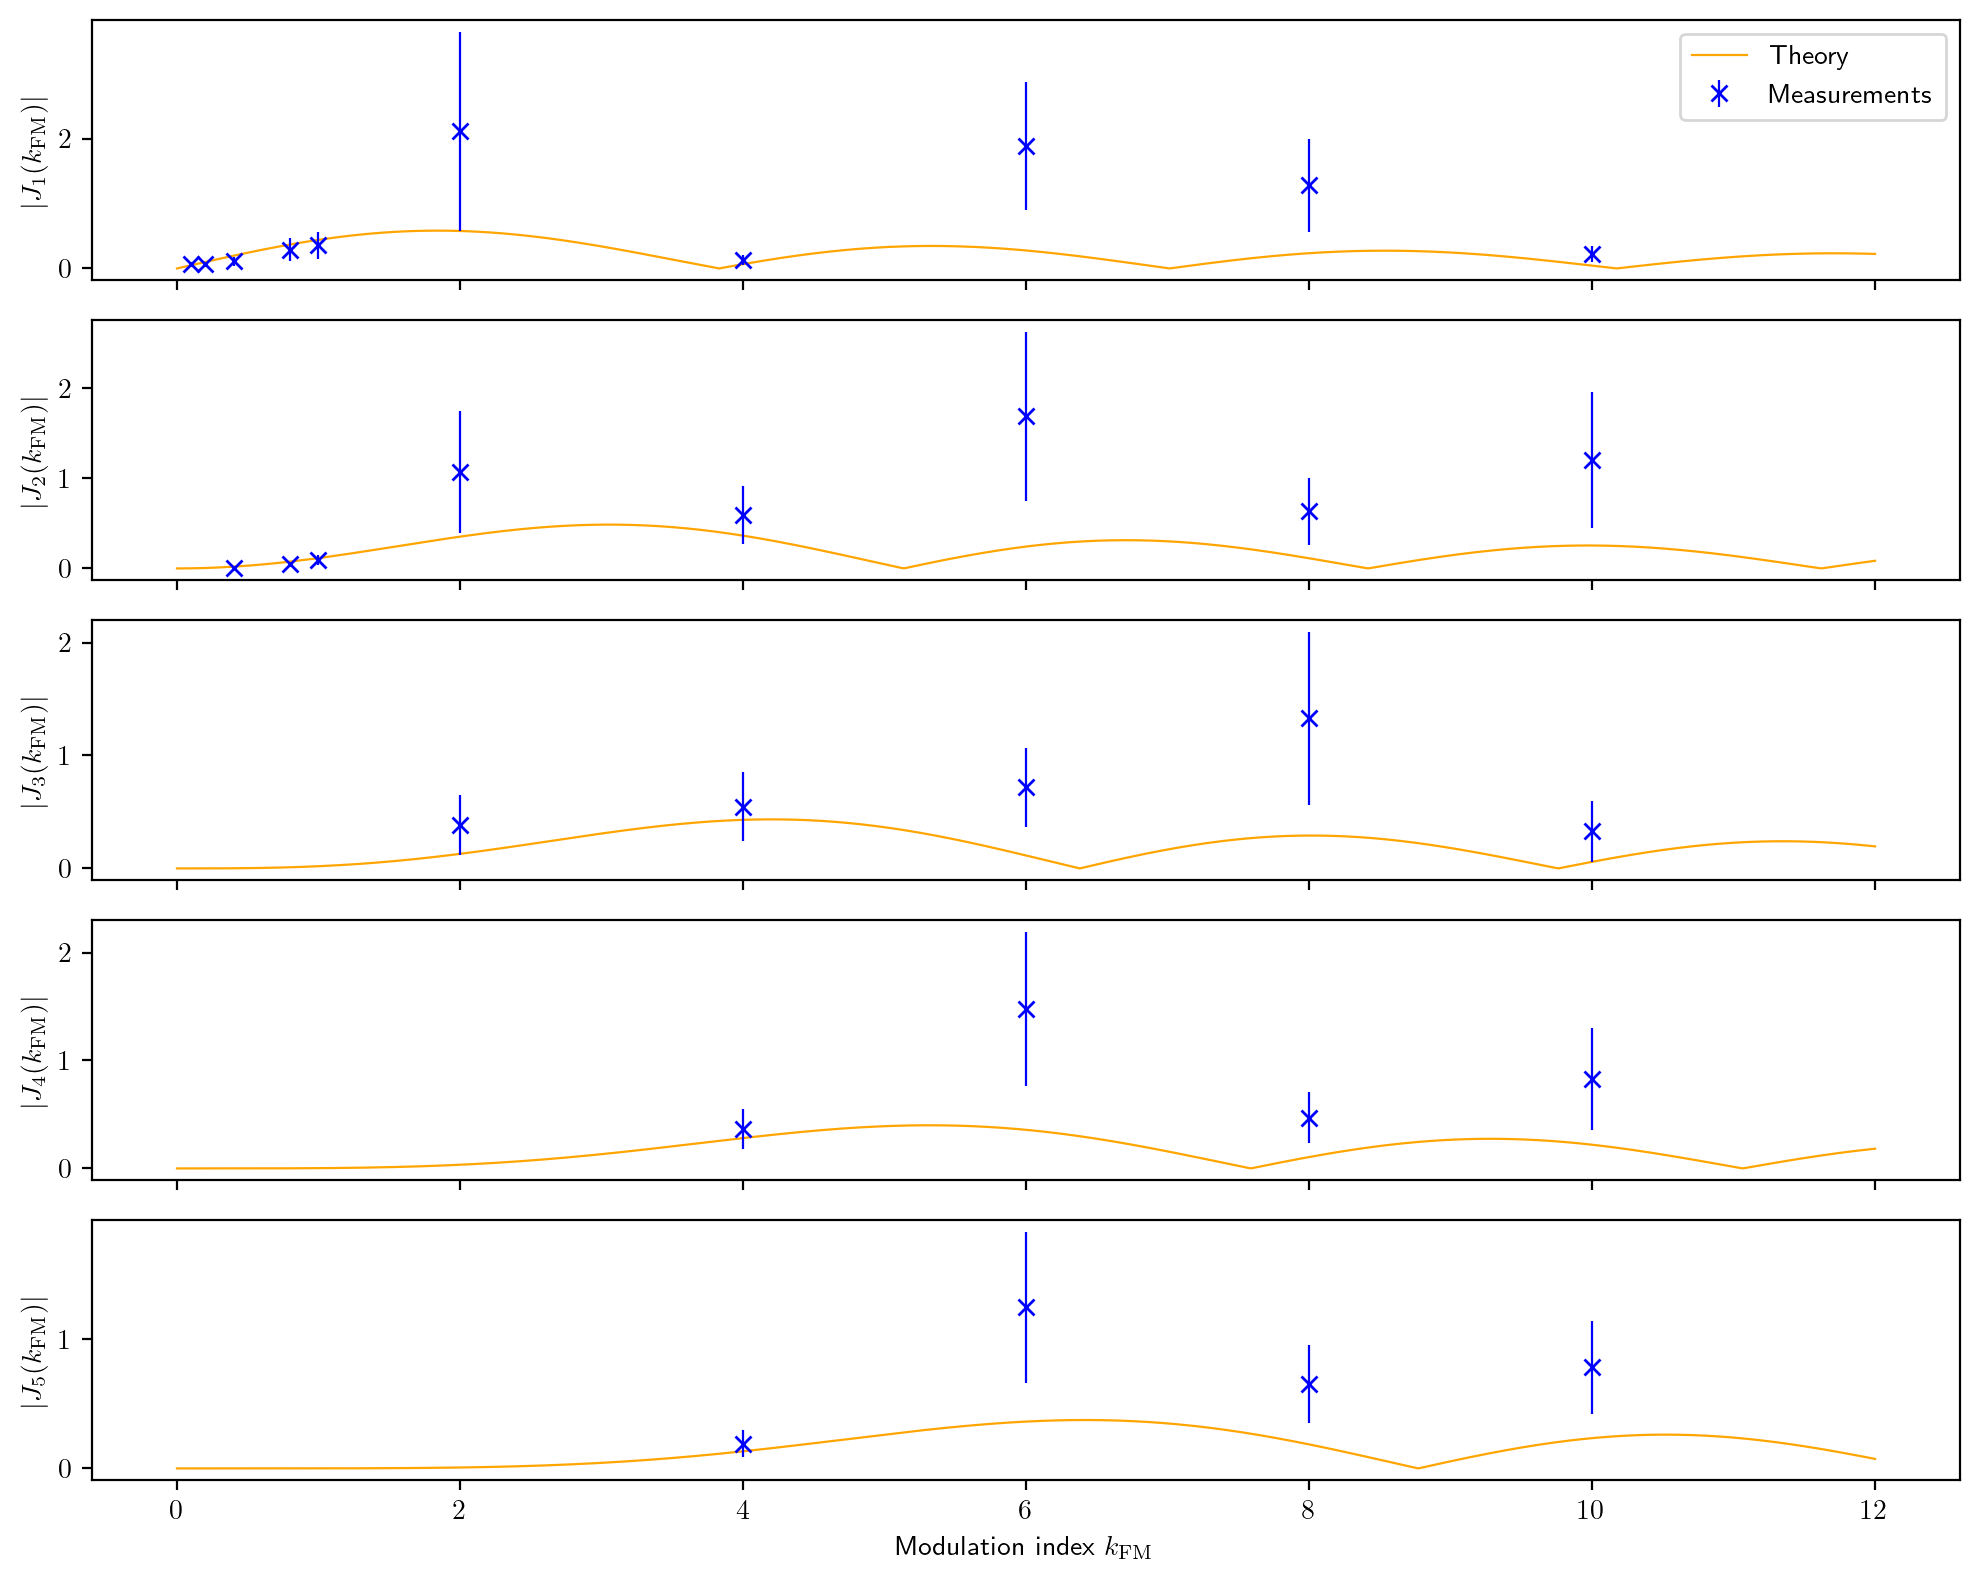

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

# Kontinuierliche μ-Achse
mu_cont = np.linspace(0, 12, 1000)

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(10, 8),
    dpi=200,
    sharex=True
)


# -------------------------
# n = 1
# -------------------------
axes[0].plot(mu_cont, np.abs(jv(1, mu_cont)),
             color="orange", linewidth=0.8, label=r"Theory")
axes[0].errorbar(k_FM_1, experimental_value_1,
                 yerr=experimental_value_err_1,
                 fmt="x", color="blue", linewidth=0.8, label=r"Measurements")
axes[0].set_ylabel(r"$|J_1(k_\mathrm{FM})|$")
axes[0].legend()
axes[0].grid(False)

# -------------------------
# n = 2
# -------------------------
axes[1].plot(mu_cont, np.abs(jv(2, mu_cont)),
            color="orange", linewidth=0.8)
axes[1].errorbar(k_FM_2, experimental_value_2,
                 yerr=experimental_value_err_2,
                 fmt="x", color="blue", linewidth=0.8)
axes[1].set_ylabel(r"$|J_2(k_\mathrm{FM})|$")
#axes[1].legend()
axes[1].grid(False)

# -------------------------
# n = 3
# -------------------------
axes[2].plot(mu_cont, np.abs(jv(3, mu_cont)),
            color="orange", linewidth=0.8)
axes[2].errorbar(k_FM_3, experimental_value_3,
                 yerr=experimental_value_err_3,
                 fmt="x", color="blue", linewidth=0.8)
axes[2].set_ylabel(r"$|J_3(k_\mathrm{FM})|$")
#axes[2].legend()
axes[2].grid(False)

# -------------------------
# n = 4
# -------------------------
axes[3].plot(mu_cont, np.abs(jv(4, mu_cont)),
             color="orange", linewidth=0.8)
axes[3].errorbar(k_FM_4, experimental_value_4,
                 yerr=experimental_value_err_4,
                 fmt="x", color="blue", linewidth=0.8)
axes[3].set_ylabel(r"$|J_4(k_\mathrm{FM})|$")
#axes[3].set_xlabel(r"Modulation index $\mu$")
#axes[3].legend()
axes[3].grid(False)

# ----------------------------
# n = 5
# ---------------------------
axes[4].plot(mu_cont, np.abs(jv(5, mu_cont)),
             color="orange", linewidth=0.8)
axes[4].errorbar(k_FM_5, experimental_value_5,
                 yerr=experimental_value_err_5,
                 fmt="x", color="blue", linewidth=0.8)
axes[4].set_ylabel(r"$|J_5(k_\mathrm{FM})|$")
axes[4].set_xlabel(r"Modulation index $k_\mathrm{FM}$")
#axes[4].legend()
axes[4].grid(False)

plt.tight_layout()
plt.savefig("A3_overview_experimental_theory.pdf", bbox_inches="tight")
plt.show()


## 4. Exercise: FFT for a FM signal with f_m < 100 mHz and k_FM = 1

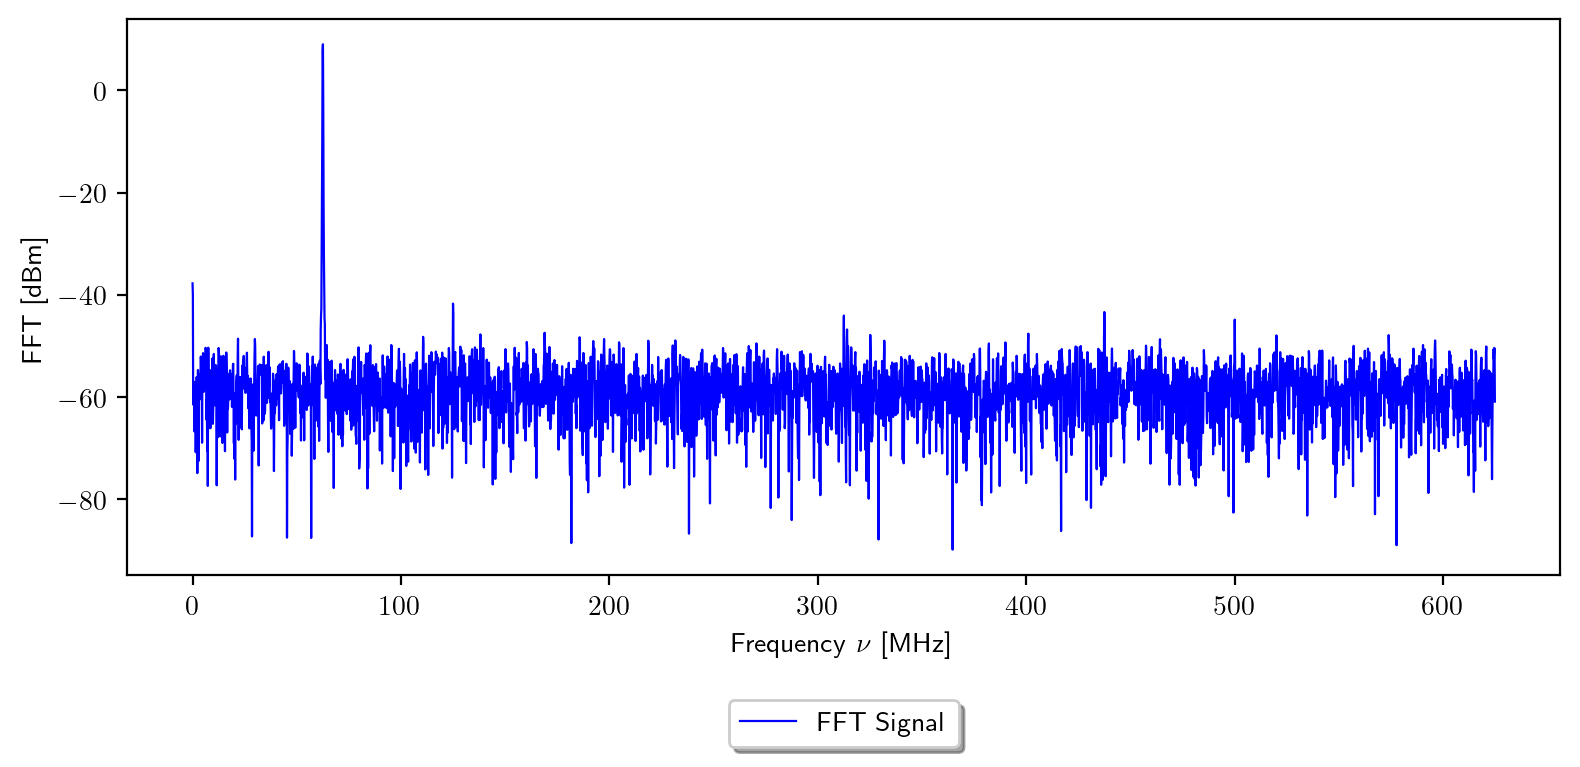

In [27]:
A4_100_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG04/FFT_27.CSV" #insert path name, if code is reused please modify
data_100 = pd.read_csv(A4_100_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq_100 = data_100["time"]
freq_100 = (freq_100 - freq_100[0]) / 10e3
ch1_100 = data_100["CH1"]

plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq_100, ch1_100, color="blue", linewidth=0.8, label=r"FFT Signal")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
#plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A4_100_FFT.pdf", bbox_inches="tight")

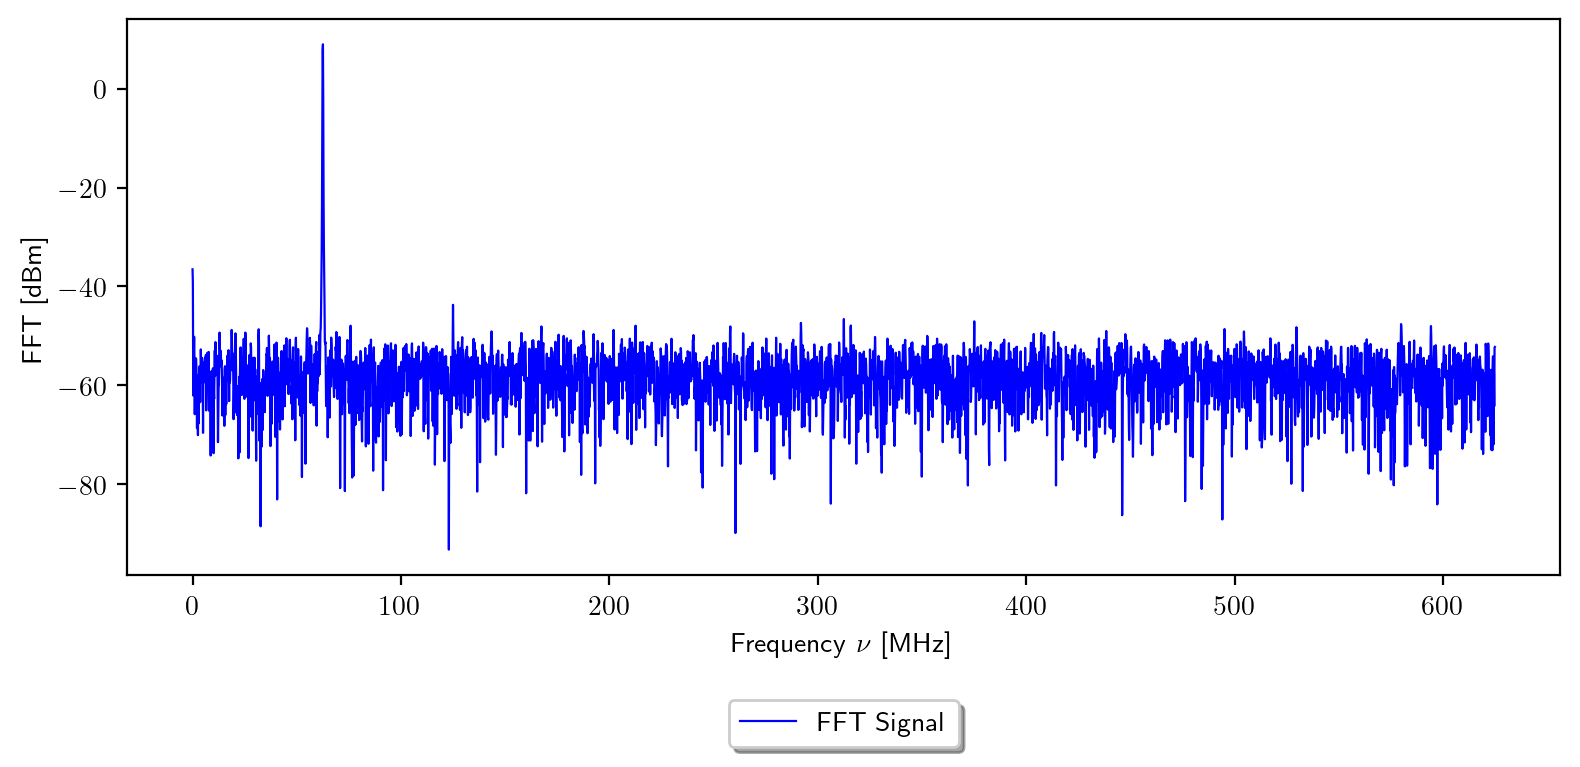

In [28]:
A4_50_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG04/FFT_28.CSV" #insert path name, if code is reused please modify
data_50 = pd.read_csv(A4_50_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq_50 = data_50["time"]
freq_50 = (freq_50 - freq_50[0]) / 10e3
ch1_50 = data_50["CH1"]

plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq_50, ch1_50, color="blue", linewidth=0.8, label=r"FFT Signal")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
#plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A4_50_FFT.pdf", bbox_inches="tight")

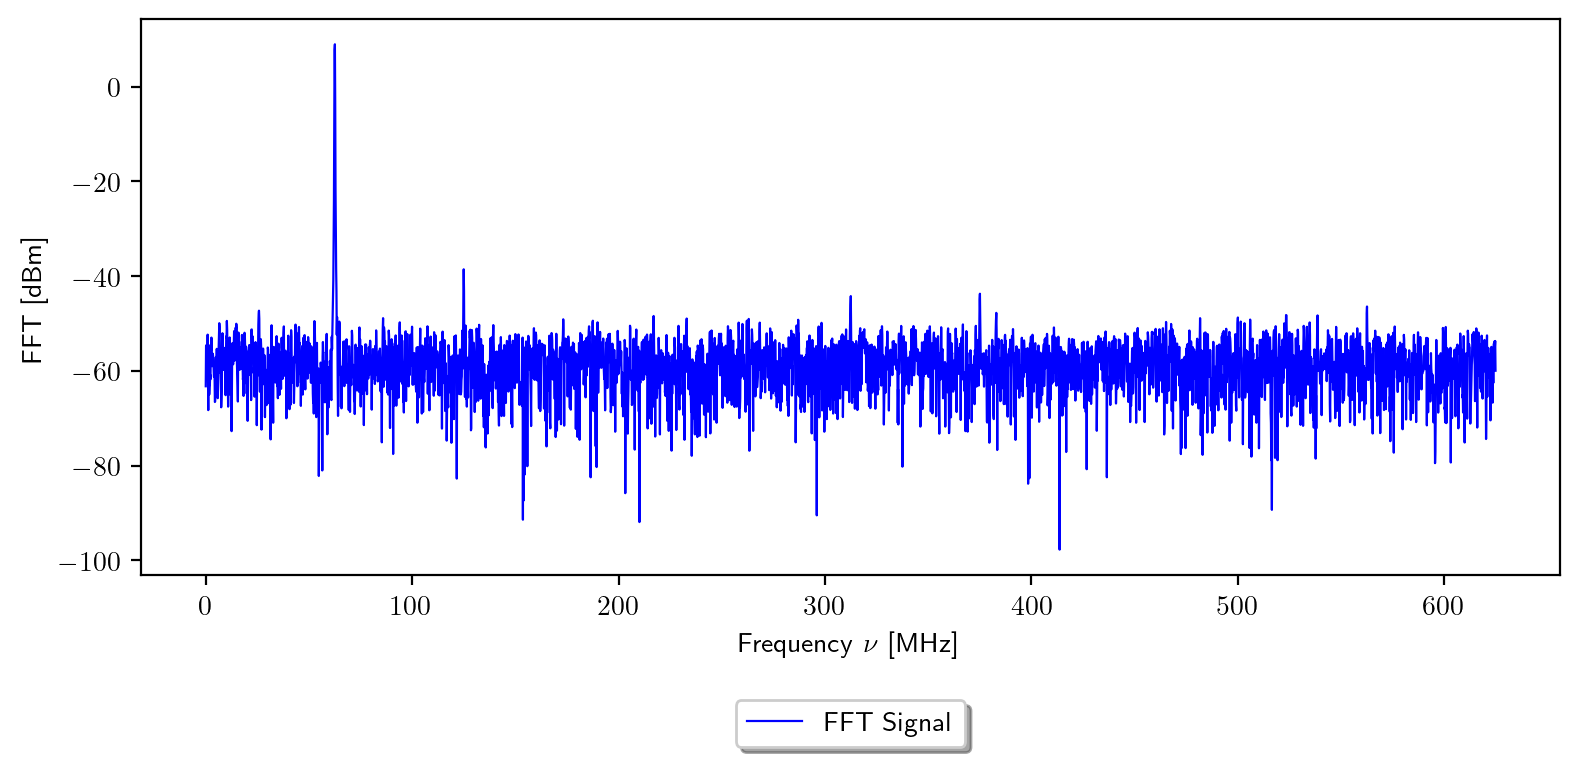

In [29]:
A4_10_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG04/FFT_29.CSV" #insert path name, if code is reused please modify
data_10 = pd.read_csv(A4_10_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq_10 = data_10["time"]
freq_10 = (freq_10 - freq_10[0]) / 10e3
ch1_10 = data_10["CH1"]

plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq_10, ch1_10, color="blue", linewidth=0.8, label=r"FFT Signal")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
#plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A4_10_FFT.pdf", bbox_inches="tight")

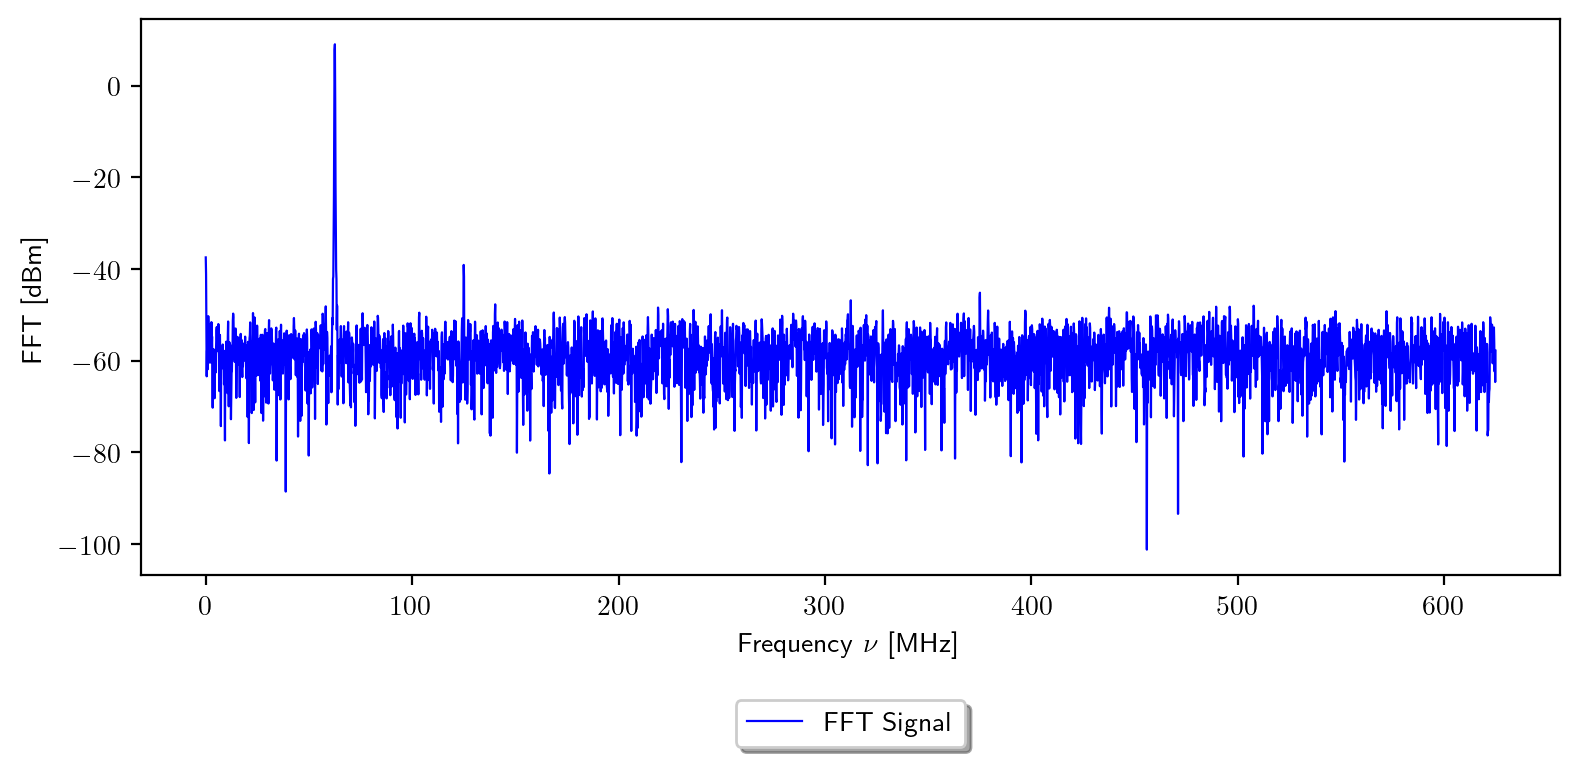

In [30]:
A4_150_FFT = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_FFT/AG04/FFT_30.CSV" #insert path name, if code is reused please modify
data_150 = pd.read_csv(A4_150_FFT, header=None, skiprows=1, names=["time", "CH1"])
freq_150 = data_150["time"]
freq_150 = (freq_150 - freq_150[0]) / 10e3
ch1_150 = data_150["CH1"]

plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq_150, ch1_150, color="blue", linewidth=0.8, label=r"FFT Signal")

plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
#plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A4_150_FFT.pdf", bbox_inches="tight")

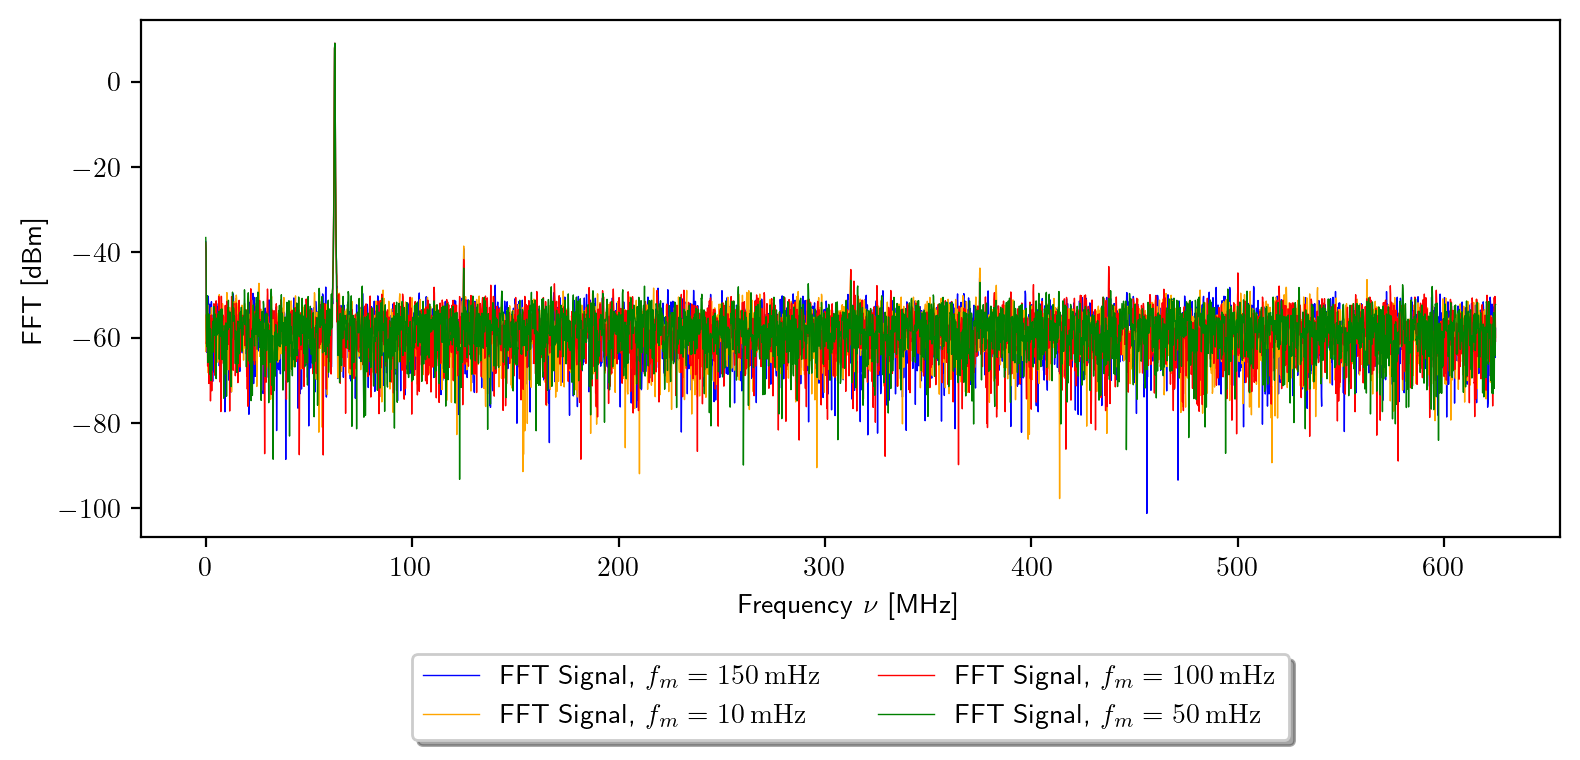

In [31]:
plt.figure(figsize=(8,4), dpi=200)
plt.plot(freq_150, ch1_150, color="blue", linewidth=0.5, label=r"FFT Signal, $f_m=150\:\mathrm{mHz}$")
plt.plot(freq_10, ch1_10, color="orange", linewidth=0.5, label=r"FFT Signal, $f_m=10\:\mathrm{mHz}$")
plt.plot(freq_100, ch1_100, color="red", linewidth=0.5, label=r"FFT Signal, $f_m=100\:\mathrm{mHz}$")
plt.plot(freq_50, ch1_50, color="green", linewidth=0.5, label=r"FFT Signal, $f_m=50\:\mathrm{mHz}$")
plt.xlabel(r"Frequency $\nu$ [MHz]")
plt.ylabel(r"FFT [dBm]")
#plt.title("Gaussian fits")
#plt.xlim(20, 100)
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)


plt.tight_layout()
plt.savefig("A4_overview_FFT.pdf", bbox_inches="tight")

## 5. Exercise: Calculation of the Bode Diagram

#### 10 kHz Measurement 

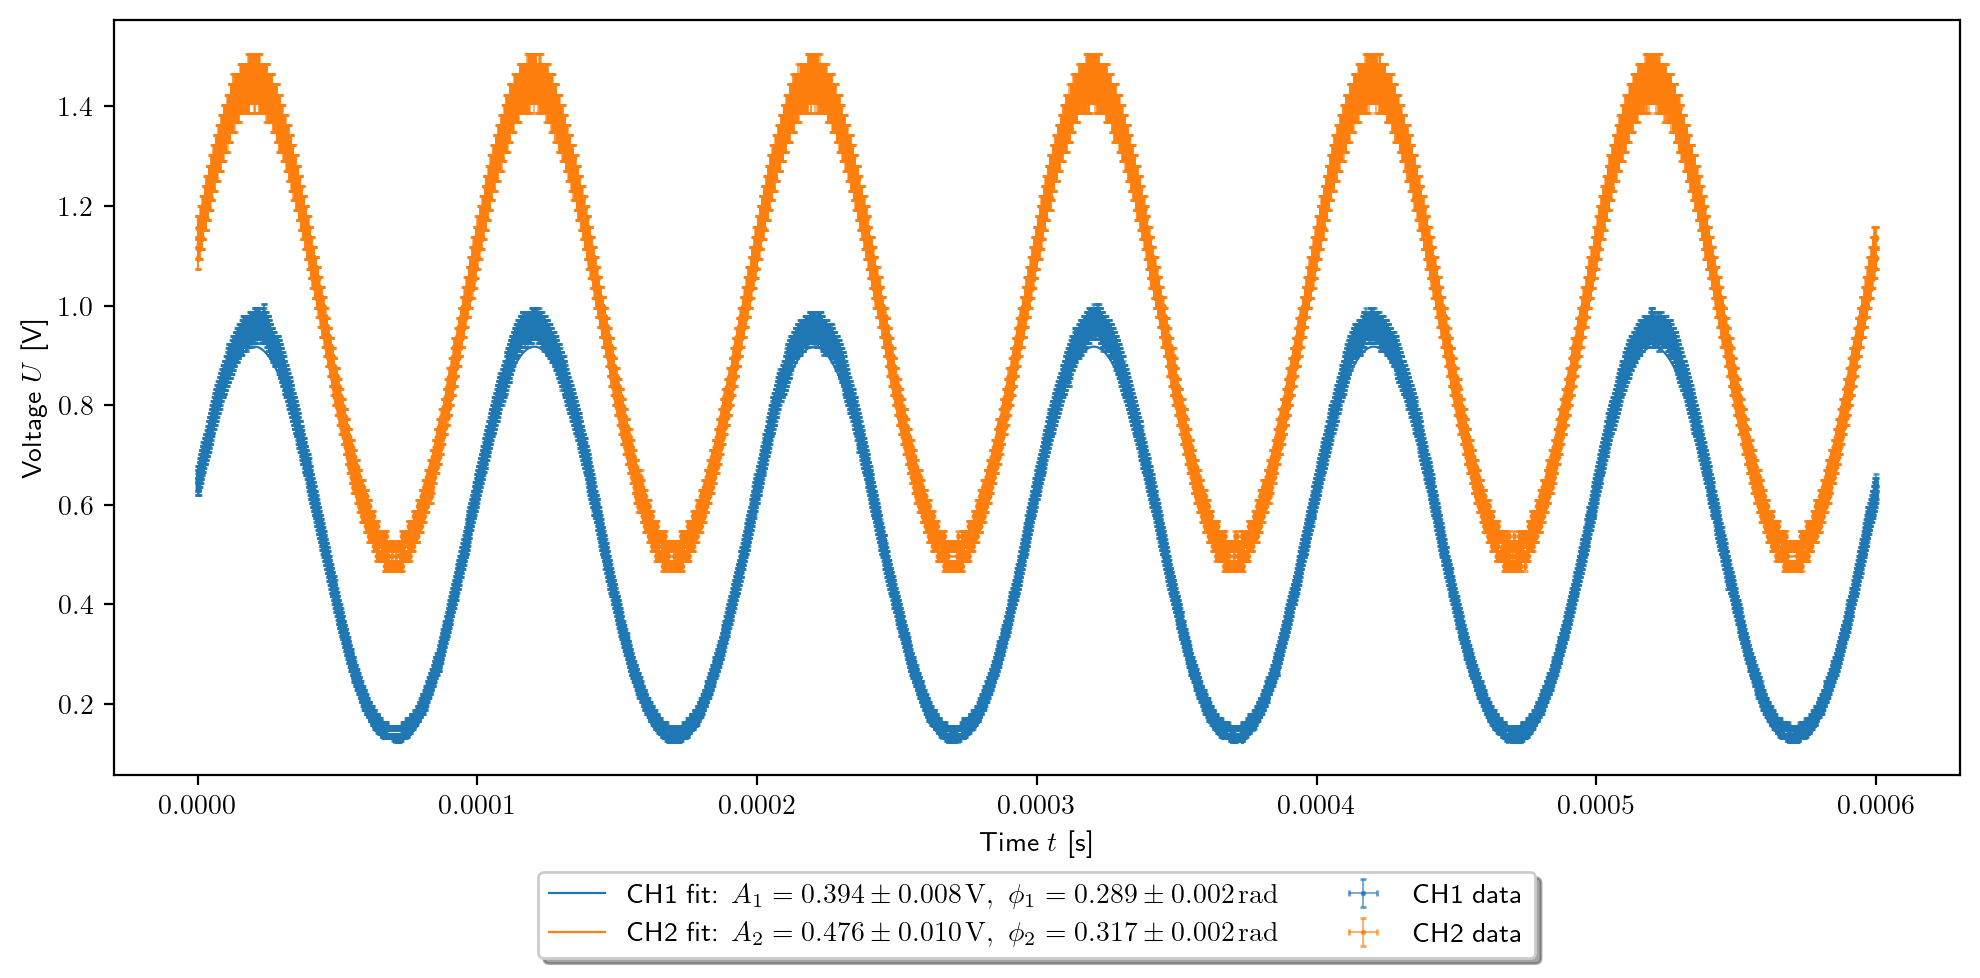

===== BODE VALUES =====
Modulation frequency f = 1.00e+04 Hz

A1 = 0.3937 ± 0.0079 V
A2 = 0.4761 ± 0.0095 V

A_rel = 1.2091 ± 0.0342
A_rel (dB) = 1.65 ± 0.25 dB

delta phi = 0.0274 ± 0.0027 rad


In [33]:
A5_10_ch1 = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/GROUP3/AOM_14.CSV" #insert path name, if code is reused please modify
data_ch1 = pd.read_csv(A5_10_ch1, header=None, skiprows=1, names=["time", "CH1"])
time_ch1 = data_ch1["time"]
time_ch1 = time_ch1 - time_ch1[0]
signal_ch1 = data_ch1["CH1"]
time_ch1_err = time_ch1 * 50e-6 
signal_ch1_err = 0.02 * np.abs(signal_ch1) 
A5_10_ch2 = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/GROUP3/AOM_15.CSV" #insert path name, if code is reused please modify
data_ch2 = pd.read_csv(A5_10_ch2, header=None, skiprows=1, names=["time", "CH1"])
time_ch2 = data_ch2["time"]
time_ch2 = time_ch2 - time_ch2[0]
signal_ch2 = data_ch2["CH1"]
time_ch2_err = time_ch2 * 50e-6 
signal_ch2_err = 0.02 * np.abs(signal_ch2) 

def sinus(t, A, phi, C, f):
    return A * np.sin(2*np.pi*f*t + phi) + C

f_mod = 10e3

A_guess = (np.max(signal_ch1) - np.min(signal_ch1)) / 2
phi_guess = 0
C_guess = np.mean(signal_ch1)

popt1, pcov1 = curve_fit(
    lambda t, A, phi, C: sinus(t, A, phi, C, f_mod),
    time_ch1,
    signal_ch1,
    p0=[A_guess, phi_guess, C_guess],
    sigma=signal_ch1_err,
    absolute_sigma=True
)


A1, phi1, C1 = popt1
A1_err = np.sqrt(pcov1[0, 0])
A1_err = np.sqrt(A1_err**2 + (0.02*A1)**2)
phi1_err = np.sqrt(pcov1[1, 1])

A_guess = (np.max(signal_ch2) - np.min(signal_ch2)) / 2
phi_guess = 0
C_guess = np.mean(signal_ch2)

popt2, pcov2 = curve_fit(
    lambda t, A, phi, C: sinus(t, A, phi, C, f_mod),
    time_ch2,
    signal_ch2,
    p0=[A_guess, phi_guess, C_guess],
    sigma=signal_ch2_err,
    absolute_sigma=True
)

A2, phi2, C2 = popt2
A2_err = np.sqrt(pcov2[0, 0])
A2_err = np.sqrt(A2_err**2 + (0.02*A2)**2)

phi2_err = np.sqrt(pcov2[1, 1])

A_rel = A2 / A1
A_rel_err = A_rel * np.sqrt(
    (A1_err / A1)**2 + (A2_err / A2)**2
)
phi1_err_fit = np.sqrt(pcov1[1, 1])
phi2_err_fit = np.sqrt(pcov2[1, 1])

t_rep1 = np.max(time_ch1)  
t_rep2 = np.max(time_ch2)

sigma_t1 = t_rep1 * 50e-6
sigma_t2 = t_rep2 * 50e-6

phi1_err_time = 2*np.pi*f_mod*sigma_t1
phi2_err_time = 2*np.pi*f_mod*sigma_t2

# error fo phase
phi1_err = np.sqrt(phi1_err_fit**2 + phi1_err_time**2)
phi2_err = np.sqrt(phi2_err_fit**2 + phi2_err_time**2)

t_fit = np.linspace(
    max(time_ch1.min(), time_ch2.min()),
    min(time_ch1.max(), time_ch2.max()),
    5000
)

label_ch1_fit = (
    rf"CH1 fit: $A_1 = {A1:.3f}\pm{A1_err:.3f}\,\mathrm{{V}},\ "
    rf"\phi_1 = {phi1:.3f}\pm{phi1_err:.3f}\,\mathrm{{rad}}$"
)

label_ch2_fit = (
    rf"CH2 fit: $A_2 = {A2:.3f}\pm{A2_err:.3f}\,\mathrm{{V}},\ "
    rf"\phi_2 = {phi2:.3f}\pm{phi2_err:.3f}\,\mathrm{{rad}}$"
)



plt.figure(figsize=(10, 5), dpi=200)

# ---- CH1 ----
plt.errorbar(
    time_ch1, signal_ch1,
    xerr=time_ch1_err, yerr=signal_ch1_err,
    fmt=".", markersize=2,
    elinewidth=0.6, capsize=1,
    alpha=0.7,
    label="CH1 data"
)

plt.plot(
    t_fit,
    sinus(t_fit, A1, phi1, C1, f_mod),
    "-", color="tab:blue", linewidth=0.8,
    label=label_ch1_fit
)

# ---- CH2 ----
plt.errorbar(
    time_ch2, signal_ch2,
    xerr=time_ch2_err, yerr=signal_ch2_err,
    fmt=".", markersize=2,
    elinewidth=0.6, capsize=1,
    alpha=0.7,
    label="CH2 data"
)

plt.plot(
    t_fit,
    sinus(t_fit, A2, phi2, C2, f_mod),
    "-", color="tab:orange", linewidth=0.8,
    label=label_ch2_fit
)

plt.xlabel(r"Time $t$ [s]")
plt.ylabel(r"Voltage $U$ [V]")
#plt.title(f"Sinus fit at f = {f_mod/1e3:.1f} kHz")
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.11), fancybox=True, shadow=True, ncol=2)
plt.tight_layout()
plt.savefig("A5_10.pdf")
plt.show()

# -------------------------------
# Bode-values
# -------------------------------

# phase differences
delta_phi = phi2 - phi1
delta_phi_err = np.sqrt(phi1_err**2 + phi2_err**2)

# amplitudes in dB
A_rel_dB = 20 * np.log10(A_rel)
A_rel_dB_err = (20 / np.log(10)) * (A_rel_err / A_rel)

print("===== BODE VALUES =====")
print(f"Modulation frequency f = {f_mod:.2e} Hz")
print("")
print(f"A1 = {A1:.4f} ± {A1_err:.4f} V")
print(f"A2 = {A2:.4f} ± {A2_err:.4f} V")
print("")
print(f"A_rel = {A_rel:.4f} ± {A_rel_err:.4f}")
print(f"A_rel (dB) = {A_rel_dB:.2f} ± {A_rel_dB_err:.2f} dB")
print("")
print(f"delta phi = {delta_phi:.4f} ± {delta_phi_err:.4f} rad")
print("=======================")

#### 100 kHz Measurement 

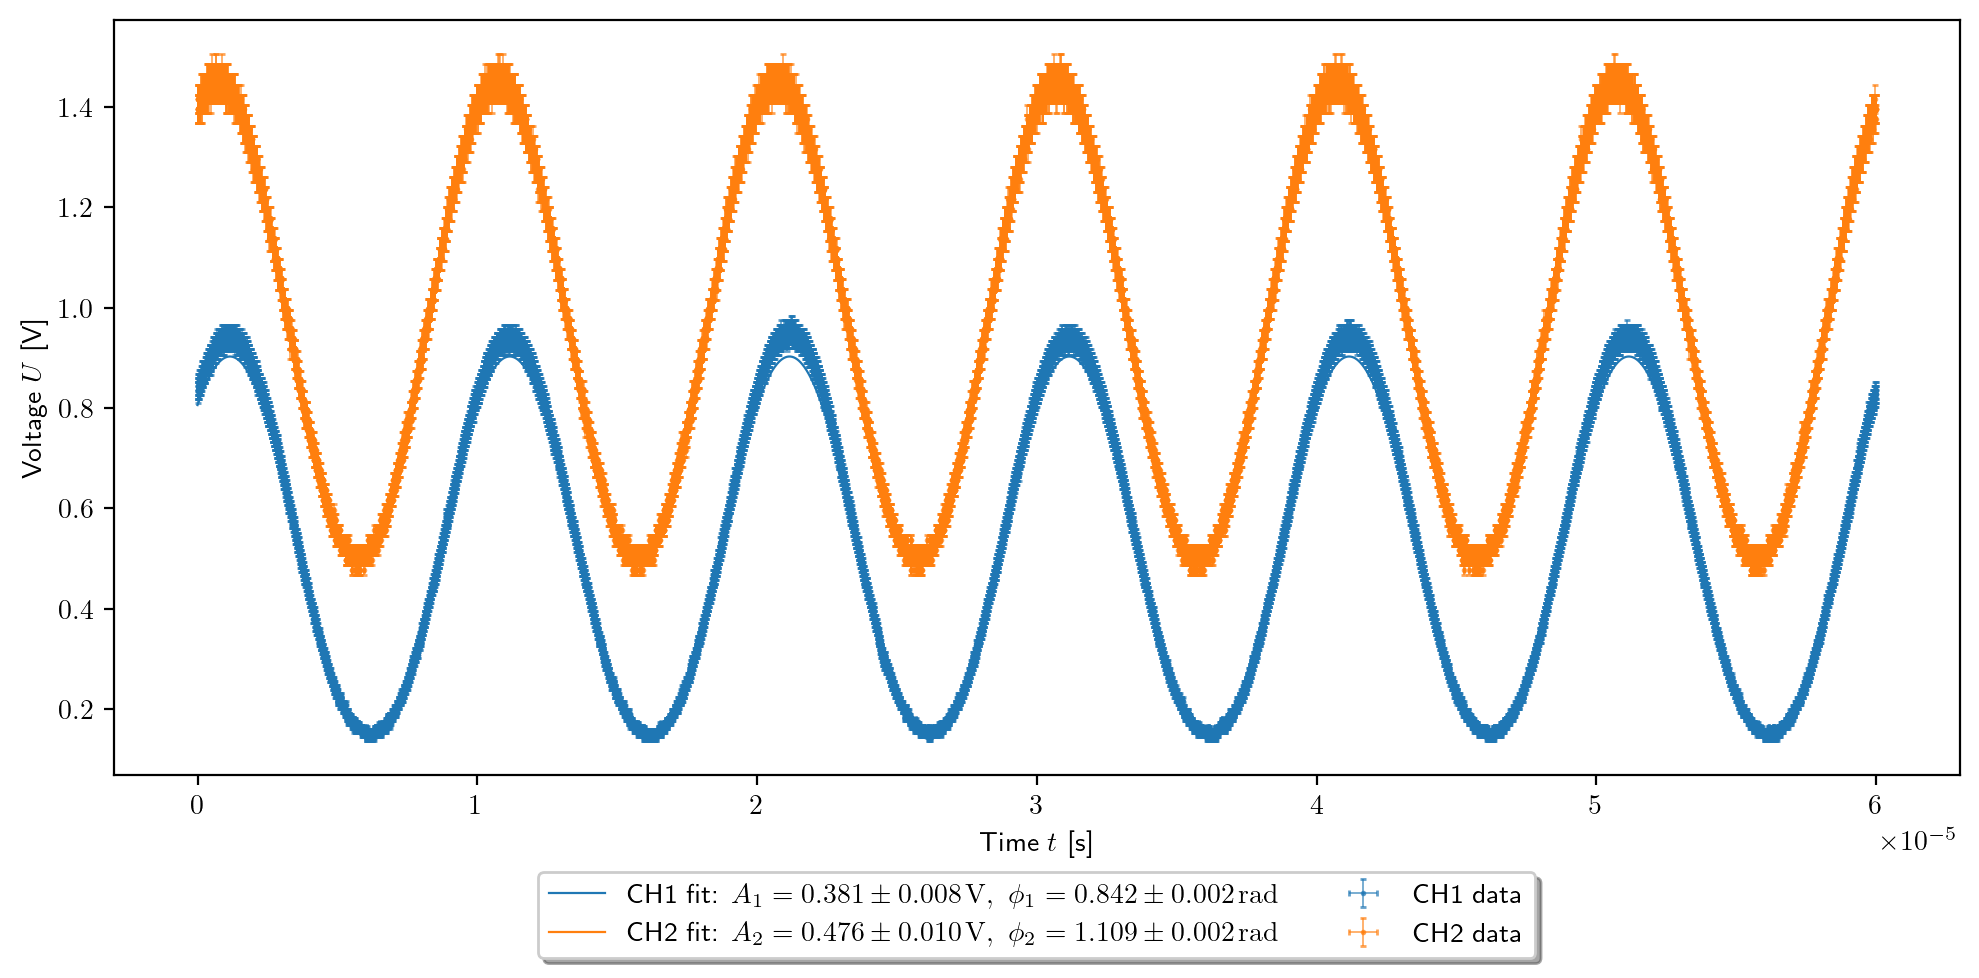

===== BODE VALUES =====
Modulation frequency f = 1.00e+05 Hz

A1 = 0.3812 ± 0.0076 V
A2 = 0.4755 ± 0.0095 V

A_rel = 1.2475 ± 0.0353
A_rel (dB) = 1.92 ± 0.25 dB

delta phi = 0.2672 ± 0.0027 rad


In [34]:
A5_100_ch1 = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/GROUP3/AOM_16.CSV" #insert path name, if code is reused please modify
data_ch1 = pd.read_csv(A5_100_ch1, header=None, skiprows=1, names=["time", "CH1"])
time_ch1 = data_ch1["time"]
time_ch1 = time_ch1 - time_ch1[0]
signal_ch1 = data_ch1["CH1"]
time_ch1_err = time_ch1 * 50e-6 
signal_ch1_err = 0.02 * np.abs(signal_ch1) 
A5_100_ch2 = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/GROUP3/AOM_17.CSV" #insert path name, if code is reused please modify
data_ch2 = pd.read_csv(A5_100_ch2, header=None, skiprows=1, names=["time", "CH1"])
time_ch2 = data_ch2["time"]
time_ch2 = time_ch2 - time_ch2[0]
signal_ch2 = data_ch2["CH1"]
time_ch2_err = time_ch2 * 50e-6 
signal_ch2_err = 0.02 * np.abs(signal_ch2) 

def sinus(t, A, phi, C, f):
    return A * np.sin(2*np.pi*f*t + phi) + C

f_mod = 100e3

A_guess = (np.max(signal_ch1) - np.min(signal_ch1)) / 2
phi_guess = 0
C_guess = np.mean(signal_ch1)

popt1, pcov1 = curve_fit(
    lambda t, A, phi, C: sinus(t, A, phi, C, f_mod),
    time_ch1,
    signal_ch1,
    p0=[A_guess, phi_guess, C_guess],
    sigma=signal_ch1_err,
    absolute_sigma=True
)


A1, phi1, C1 = popt1
A1_err = np.sqrt(pcov1[0, 0])
A1_err = np.sqrt(A1_err**2 + (0.02*A1)**2)
phi1_err = np.sqrt(pcov1[1, 1])

A_guess = (np.max(signal_ch2) - np.min(signal_ch2)) / 2
phi_guess = 0
C_guess = np.mean(signal_ch2)

popt2, pcov2 = curve_fit(
    lambda t, A, phi, C: sinus(t, A, phi, C, f_mod),
    time_ch2,
    signal_ch2,
    p0=[A_guess, phi_guess, C_guess],
    sigma=signal_ch2_err,
    absolute_sigma=True
)

A2, phi2, C2 = popt2
A2_err = np.sqrt(pcov2[0, 0])
A2_err = np.sqrt(A2_err**2 + (0.02*A2)**2)

phi2_err = np.sqrt(pcov2[1, 1])

A_rel = A2 / A1
A_rel_err = A_rel * np.sqrt(
    (A1_err / A1)**2 + (A2_err / A2)**2
)
phi1_err_fit = np.sqrt(pcov1[1, 1])
phi2_err_fit = np.sqrt(pcov2[1, 1])

t_rep1 = np.max(time_ch1)  
t_rep2 = np.max(time_ch2)

sigma_t1 = t_rep1 * 50e-6
sigma_t2 = t_rep2 * 50e-6

phi1_err_time = 2*np.pi*f_mod*sigma_t1
phi2_err_time = 2*np.pi*f_mod*sigma_t2

# error of the phase
phi1_err = np.sqrt(phi1_err_fit**2 + phi1_err_time**2)
phi2_err = np.sqrt(phi2_err_fit**2 + phi2_err_time**2)

t_fit = np.linspace(
    max(time_ch1.min(), time_ch2.min()),
    min(time_ch1.max(), time_ch2.max()),
    5000
)

label_ch1_fit = (
    rf"CH1 fit: $A_1 = {A1:.3f}\pm{A1_err:.3f}\,\mathrm{{V}},\ "
    rf"\phi_1 = {phi1:.3f}\pm{phi1_err:.3f}\,\mathrm{{rad}}$"
)

label_ch2_fit = (
    rf"CH2 fit: $A_2 = {A2:.3f}\pm{A2_err:.3f}\,\mathrm{{V}},\ "
    rf"\phi_2 = {phi2:.3f}\pm{phi2_err:.3f}\,\mathrm{{rad}}$"
)



plt.figure(figsize=(10, 5), dpi=200)

# ---- CH1 ----
plt.errorbar(
    time_ch1, signal_ch1,
    xerr=time_ch1_err, yerr=signal_ch1_err,
    fmt=".", markersize=2,
    elinewidth=0.6, capsize=1,
    alpha=0.7,
    label="CH1 data"
)

plt.plot(
    t_fit,
    sinus(t_fit, A1, phi1, C1, f_mod),
    "-", color="tab:blue", linewidth=0.8,
    label=label_ch1_fit
)

# ---- CH2 ----
plt.errorbar(
    time_ch2, signal_ch2,
    xerr=time_ch2_err, yerr=signal_ch2_err,
    fmt=".", markersize=2,
    elinewidth=0.6, capsize=1,
    alpha=0.7,
    label="CH2 data"
)

plt.plot(
    t_fit,
    sinus(t_fit, A2, phi2, C2, f_mod),
    "-", color="tab:orange", linewidth=0.8,
    label=label_ch2_fit
)

plt.xlabel(r"Time $t$ [s]")
plt.ylabel(r"Voltage $U$ [V]")
#plt.title(f"Sinus fit at f = {f_mod/1e3:.1f} kHz")
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.11), fancybox=True, shadow=True, ncol=2)
plt.tight_layout()
plt.savefig("A5_100.pdf")
plt.show()

# -------------------------------
# Bode-values
# -------------------------------

# difference of phase
delta_phi = phi2 - phi1
delta_phi_err = np.sqrt(phi1_err**2 + phi2_err**2)

# amplitude in dB 
A_rel_dB = 20 * np.log10(A_rel)
A_rel_dB_err = (20 / np.log(10)) * (A_rel_err / A_rel)

print("===== BODE VALUES =====")
print(f"Modulation frequency f = {f_mod:.2e} Hz")
print("")
print(f"A1 = {A1:.4f} ± {A1_err:.4f} V")
print(f"A2 = {A2:.4f} ± {A2_err:.4f} V")
print("")
print(f"A_rel = {A_rel:.4f} ± {A_rel_err:.4f}")
print(f"A_rel (dB) = {A_rel_dB:.2f} ± {A_rel_dB_err:.2f} dB")
print("")
print(f"delta phi = {delta_phi:.4f} ± {delta_phi_err:.4f} rad")
print("=======================")

#### 500 kHz Measurement 

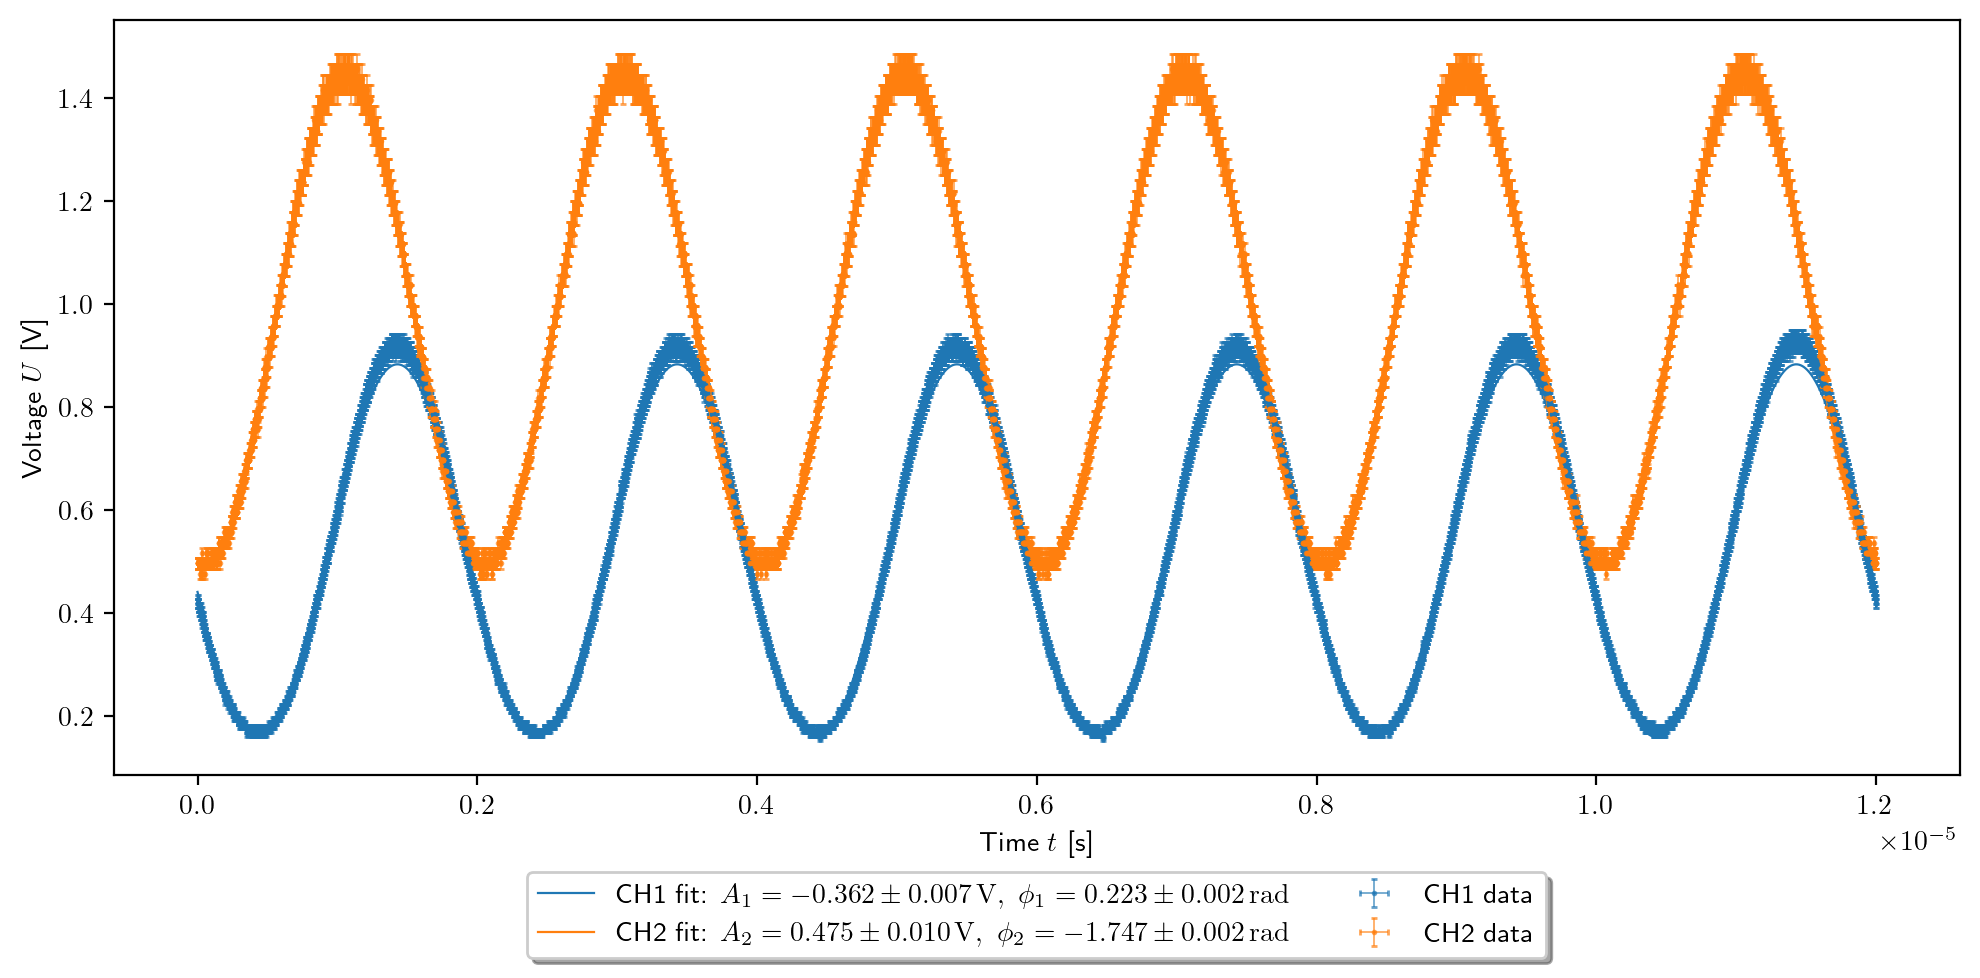

===== BODE VALUES =====
Modulation frequency f = 5.00e+05 Hz

A1 = -0.3617 ± 0.0072 V
A2 = 0.4753 ± 0.0095 V

A_rel = 1.3141 ± 0.0372
A_rel (dB) = 2.37 ± 0.25 dB

delta phi = -1.9698 ± 0.0027 rad


In [35]:
A5_500_ch1 = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/GROUP3/AOM_18.CSV" #insert path name, if code is reused please modify
data_ch1 = pd.read_csv(A5_500_ch1, header=None, skiprows=1, names=["time", "CH1"])
time_ch1 = data_ch1["time"]
time_ch1 = time_ch1 - time_ch1[0]
signal_ch1 = data_ch1["CH1"]
time_ch1_err = time_ch1 * 50e-6 
signal_ch1_err = 0.02 * np.abs(signal_ch1) 
A5_500_ch2 = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/GROUP3/AOM_19.CSV" #insert path name, if code is reused please modify
data_ch2 = pd.read_csv(A5_500_ch2, header=None, skiprows=1, names=["time", "CH1"])
time_ch2 = data_ch2["time"]
time_ch2 = time_ch2 - time_ch2[0]
signal_ch2 = data_ch2["CH1"]
time_ch2_err = time_ch2 * 50e-6 
signal_ch2_err = 0.02 * np.abs(signal_ch2) 

def sinus(t, A, phi, C, f):
    return A * np.sin(2*np.pi*f*t + phi) + C

f_mod = 500e3

A_guess = (np.max(signal_ch1) - np.min(signal_ch1)) / 2
phi_guess = 0
C_guess = np.mean(signal_ch1)

popt1, pcov1 = curve_fit(
    lambda t, A, phi, C: sinus(t, A, phi, C, f_mod),
    time_ch1,
    signal_ch1,
    p0=[A_guess, phi_guess, C_guess],
    sigma=signal_ch1_err,
    absolute_sigma=True
)


A1, phi1, C1 = popt1
A1_err = np.sqrt(pcov1[0, 0])
A1_err = np.sqrt(A1_err**2 + (0.02*A1)**2)
phi1_err = np.sqrt(pcov1[1, 1])

A_guess = (np.max(signal_ch2) - np.min(signal_ch2)) / 2
phi_guess = 0
C_guess = np.mean(signal_ch2)

popt2, pcov2 = curve_fit(
    lambda t, A, phi, C: sinus(t, A, phi, C, f_mod),
    time_ch2,
    signal_ch2,
    p0=[A_guess, phi_guess, C_guess],
    sigma=signal_ch2_err,
    absolute_sigma=True
)

A2, phi2, C2 = popt2
A2_err = np.sqrt(pcov2[0, 0])
A2_err = np.sqrt(A2_err**2 + (0.02*A2)**2)

phi2_err = np.sqrt(pcov2[1, 1])

A_rel = A2 / A1
A_rel_err = A_rel * np.sqrt(
    (A1_err / A1)**2 + (A2_err / A2)**2
)
phi1_err_fit = np.sqrt(pcov1[1, 1])
phi2_err_fit = np.sqrt(pcov2[1, 1])

t_rep1 = np.max(time_ch1)  
t_rep2 = np.max(time_ch2)

sigma_t1 = t_rep1 * 50e-6
sigma_t2 = t_rep2 * 50e-6

phi1_err_time = 2*np.pi*f_mod*sigma_t1
phi2_err_time = 2*np.pi*f_mod*sigma_t2

# error phase
phi1_err = np.sqrt(phi1_err_fit**2 + phi1_err_time**2)
phi2_err = np.sqrt(phi2_err_fit**2 + phi2_err_time**2)

t_fit = np.linspace(
    max(time_ch1.min(), time_ch2.min()),
    min(time_ch1.max(), time_ch2.max()),
    5000
)

label_ch1_fit = (
    rf"CH1 fit: $A_1 = {A1:.3f}\pm{A1_err:.3f}\,\mathrm{{V}},\ "
    rf"\phi_1 = {phi1:.3f}\pm{phi1_err:.3f}\,\mathrm{{rad}}$"
)

label_ch2_fit = (
    rf"CH2 fit: $A_2 = {A2:.3f}\pm{A2_err:.3f}\,\mathrm{{V}},\ "
    rf"\phi_2 = {phi2:.3f}\pm{phi2_err:.3f}\,\mathrm{{rad}}$"
)



plt.figure(figsize=(10, 5), dpi=200)

# ---- CH1 ----
plt.errorbar(
    time_ch1, signal_ch1,
    xerr=time_ch1_err, yerr=signal_ch1_err,
    fmt=".", markersize=2,
    elinewidth=0.6, capsize=1,
    alpha=0.7,
    label="CH1 data"
)

plt.plot(
    t_fit,
    sinus(t_fit, A1, phi1, C1, f_mod),
    "-", color="tab:blue", linewidth=0.8,
    label=label_ch1_fit
)

# ---- CH2 ----
plt.errorbar(
    time_ch2, signal_ch2,
    xerr=time_ch2_err, yerr=signal_ch2_err,
    fmt=".", markersize=2,
    elinewidth=0.6, capsize=1,
    alpha=0.7,
    label="CH2 data"
)

plt.plot(
    t_fit,
    sinus(t_fit, A2, phi2, C2, f_mod),
    "-", color="tab:orange", linewidth=0.8,
    label=label_ch2_fit
)

plt.xlabel(r"Time $t$ [s]")
plt.ylabel(r"Voltage $U$ [V]")
#plt.title(f"Sinus fit at f = {f_mod/1e3:.1f} kHz")
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.11), fancybox=True, shadow=True, ncol=2)
plt.tight_layout()
plt.savefig("A5_500.pdf")
plt.show()

# -------------------------------
# Bode-values
# -------------------------------
A1_mag = np.abs(A1)
A2_mag = np.abs(A2)

# phase difference
delta_phi = phi2 - phi1
delta_phi_err = np.sqrt(phi1_err**2 + phi2_err**2)

# amplitude in dB
A_rel = A2_mag / A1_mag
A_rel_err = A_rel * np.sqrt((A1_err/A1_mag)**2 + (A2_err/A2_mag)**2)

A_rel_dB = 20*np.log10(A_rel)
A_rel_dB_err = (20/np.log(10))*(A_rel_err/A_rel)


print("===== BODE VALUES =====")
print(f"Modulation frequency f = {f_mod:.2e} Hz")
print("")
print(f"A1 = {A1:.4f} ± {A1_err:.4f} V")
print(f"A2 = {A2:.4f} ± {A2_err:.4f} V")
print("")
print(f"A_rel = {A_rel:.4f} ± {A_rel_err:.4f}")
print(f"A_rel (dB) = {A_rel_dB:.2f} ± {A_rel_dB_err:.2f} dB")
print("")
print(f"delta phi = {delta_phi:.4f} ± {delta_phi_err:.4f} rad")
print("=======================")

### Loop over all values and signals and plots

In [36]:
base_path = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/GROUP3/"

measurements = [
    (10e3, 14, 15),
    (100e3, 16, 17),
    (500e3, 18, 19),
    (1e6, 20, 21),
    (1.5e6, 22, 23),
    (1.7e6, 24, 25),
    (1.9e6, 26, 27),
    (2.0e6, 28, 29),
    (2.1e6, 30, 31),
    (2.2e6, 32, 33),
    (2.3e6, 34, 35),
    (2.4e6, 36, 37),
    (2.5e6, 38, 39),
    (3.0e6, 40, 41),
    (3.5e6, 42, 43),
    (4.0e6, 44, 45),
    (4.5e6, 46, 47),
    (5.0e6, 48, 49),
    (5.5e6, 50, 51),
    (6.0e6, 52, 53),
    (7.0e6, 54, 55),
    (8.0e6, 56, 57),
    (9.0e6, 58, 59),
    (10e6, 60, 61),
    (11e6, 62, 63),
    #(12e6, 64, 65),
]

def sinus(t, A, phi, C, f):
    return A * np.sin(2*np.pi*f*t + phi) + C

def load_channel(file_number):
    data = pd.read_csv(
        f"{base_path}AOM_{file_number}.CSV",
        header=None, skiprows=1, names=["time", "signal"]
    )
    t = data["time"] - data["time"].iloc[0]
    s = data["signal"]

    t_err = t * 50e-6
    s_err = np.sqrt((0.02*np.abs(s))**2 + 0.002**2)

    return t, s, t_err, s_err

def evaluate_frequency(f_mod, ch1_num, ch2_num):

    # --- Load data ---
    t1, s1, t1_err, s1_err = load_channel(ch1_num)
    t2, s2, t2_err, s2_err = load_channel(ch2_num)

    # --- Fit CH1 ---
    p0 = [(s1.max()-s1.min())/2, 0, s1.mean()]
    popt1, pcov1 = curve_fit(
        lambda t, A, phi, C: sinus(t, A, phi, C, f_mod),
        t1, s1, p0=p0, sigma=s1_err, absolute_sigma=True
    )
    A1, phi1, C1 = popt1
    A1_err = np.sqrt(pcov1[0,0]) + 0.02*np.abs(A1)
    phi1_err_fit = np.sqrt(pcov1[1,1])

    # --- Fit CH2 ---
    p0 = [(s2.max()-s2.min())/2, 0, s2.mean()]
    popt2, pcov2 = curve_fit(
        lambda t, A, phi, C: sinus(t, A, phi, C, f_mod),
        t2, s2, p0=p0, sigma=s2_err, absolute_sigma=True
    )
    A2, phi2, C2 = popt2
    A2_err = np.sqrt(pcov2[0,0]) + 0.02*np.abs(A2)
    phi2_err_fit = np.sqrt(pcov2[1,1])

    # --- Phase time-base error ---
    sigma_t1 = t1.max() * 50e-6
    sigma_t2 = t2.max() * 50e-6

    phi1_err = np.sqrt(phi1_err_fit**2 + (2*np.pi*f_mod*sigma_t1)**2)
    phi2_err = np.sqrt(phi2_err_fit**2 + (2*np.pi*f_mod*sigma_t2)**2)

    # --- Bode values ---
    A_rel = np.abs(A2) / np.abs(A1)
    A_rel_err = A_rel * np.sqrt((A1_err/np.abs(A1))**2 + (A2_err/np.abs(A2))**2)

    delta_phi = phi2 - phi1
    delta_phi_err = np.sqrt(phi1_err**2 + phi2_err**2)

    # --- Plot ---
    t_fit = np.linspace(max(t1.min(), t2.min()), min(t1.max(), t2.max()), 5000)

        # labels
    label_ch1_fit = (
        rf"CH1 fit: $A_1={A1:.3f}\pm{A1_err:.3f}\,\mathrm{{V}},\ "
        rf"\phi_1={phi1:.3f}\pm{phi1_err:.3f}\,\mathrm{{rad}}$"
    )

    label_ch2_fit = (
        rf"CH2 fit: $A_2={A2:.3f}\pm{A2_err:.3f}\,\mathrm{{V}},\ "
        rf"\phi_2={phi2:.3f}\pm{phi2_err:.3f}\,\mathrm{{rad}}$"
    )

    # --- Plot ---
    t_fit = np.linspace(
        max(t1.min(), t2.min()),
        min(t1.max(), t2.max()),
        5000
    )

    plt.figure(figsize=(10, 5), dpi=200)

    # CH1
    plt.errorbar(
        t1, s1,
        yerr=s1_err,
        fmt=".", markersize=2,
        elinewidth=0.6, capsize=1,
        alpha=0.7,
        label="CH1 data"
    )
    plt.plot(
        t_fit,
        sinus(t_fit, A1, phi1, C1, f_mod),
        "-", linewidth=1.5,
        label=label_ch1_fit
    )

    # CH2
    plt.errorbar(
        t2, s2,
        yerr=s2_err,
        fmt=".", markersize=2,
        elinewidth=0.6, capsize=1,
        alpha=0.7,
        label="CH2 data"
    )
    plt.plot(
        t_fit,
        sinus(t_fit, A2, phi2, C2, f_mod),
        "-", linewidth=1.5,
        label=label_ch2_fit
    )

    plt.xlabel(r"Time $t$ [s]")
    plt.ylabel(r"Voltage $U$ [V]")
    # plt.title(f"Sinus fit at f = {f_mod/1e3:.1f} kHz")

    plt.grid(False)
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.11),
        fancybox=True,
        shadow=True,
        ncol=2
    )

    plt.tight_layout()
    plt.savefig(f"AOM_fit_{int(f_mod/1e3)}kHz.pdf")
    plt.close()


    return f_mod, A_rel, A_rel_err, delta_phi, delta_phi_err

f_list = []
Arel_list = []
Arel_err_list = []
phi_list = []
phi_err_list = []

for f_mod, ch1, ch2 in measurements:
    f, Arel, Arel_err, dphi, dphi_err = evaluate_frequency(f_mod, ch1, ch2)

    f_list.append(f)
    Arel_list.append(Arel*-1)
    Arel_err_list.append(Arel_err)
    phi_list.append(dphi)
    phi_err_list.append(dphi_err)


## creatinbg the Bode diagram

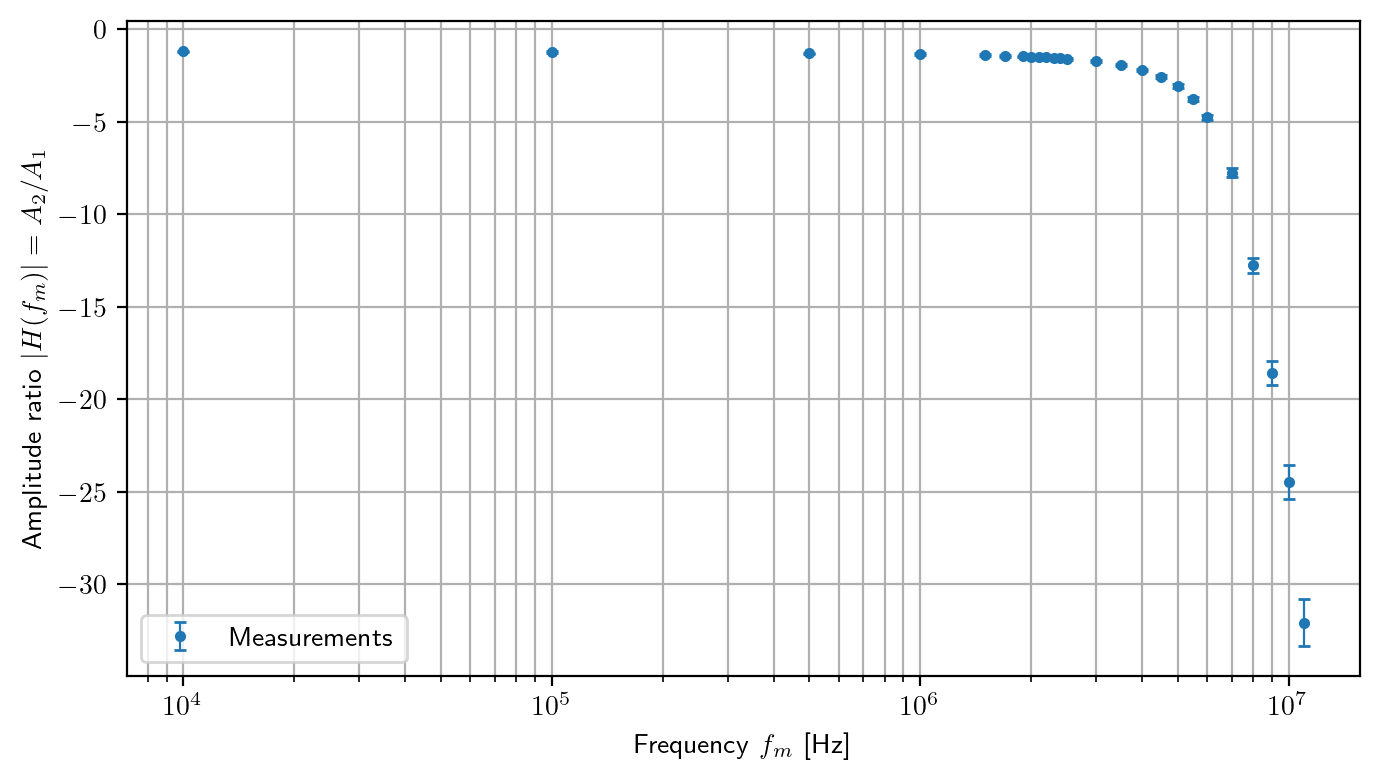

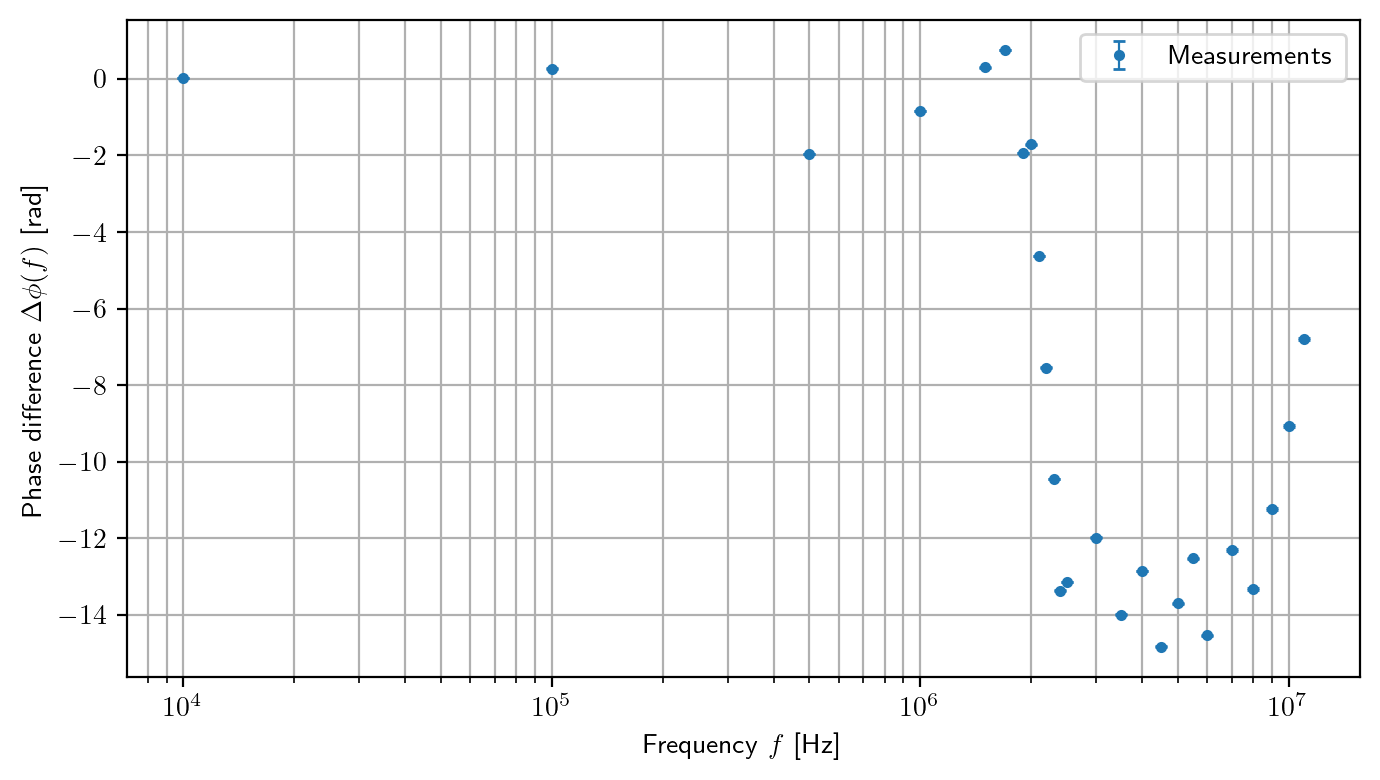

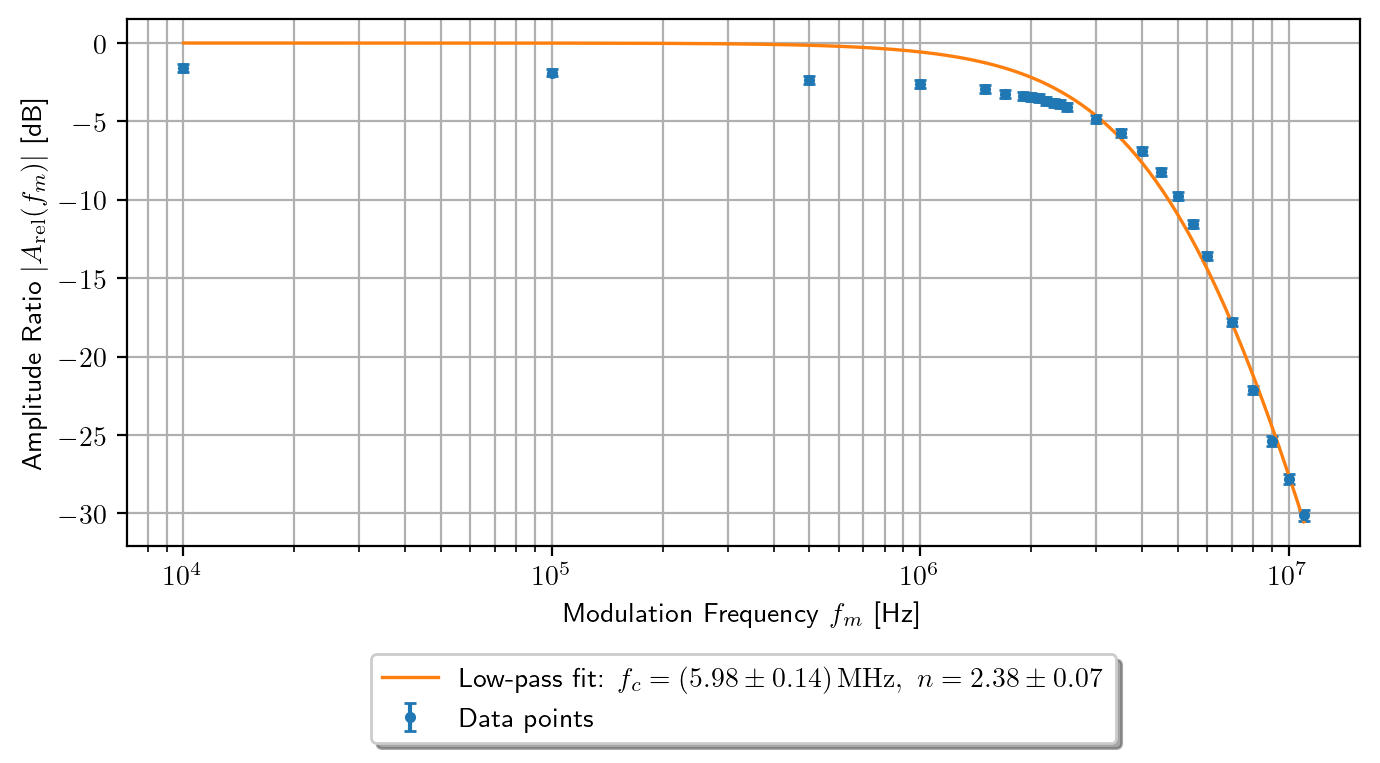

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# sorting
f = np.array(f_list, dtype=float)
H = np.array(Arel_list, dtype=float)
H_err = np.array(Arel_err_list, dtype=float)

idx = np.argsort(f)
f, H, H_err = f[idx], H[idx], H_err[idx]

def lowpass_linear(f, G, fc, n):
    return G / (1 + (f / fc)**2)**(n/2)

plt.figure(figsize=(7, 4), dpi=200)

plt.errorbar(
    f, H,
    yerr=H_err,
    fmt="o",
    markersize=3,
    elinewidth=0.8,
    capsize=2,
    label=r"Measurements"
)

plt.xscale("log")
plt.xlabel(r"Frequency $f_m$ [Hz]")
plt.ylabel(r"Amplitude ratio $|H(f_m)| = A_2/A_1$")
plt.grid(True, which="both")
plt.legend()

plt.tight_layout()
plt.savefig("Bode_amplitude_ratio.pdf", bbox_inches="tight")
plt.show()


phi = np.array(phi_list, dtype=float)
phi_err = np.array(phi_err_list, dtype=float)

phi, phi_err = phi[idx], phi_err[idx]

# unwrapping
phi_unwrapped = np.unwrap(phi)  

plt.figure(figsize=(7, 4), dpi=200)

plt.errorbar(
    f, phi_unwrapped,
    yerr=phi_err,
    fmt="o",
    markersize=3,
    elinewidth=0.8,
    capsize=2,
    label=r"Measurements"
)

plt.xscale("log")
plt.xlabel(r"Frequency $f$ [Hz]")
plt.ylabel(r"Phase difference $\Delta\phi(f)$ [rad]")
plt.grid(True, which="both")
plt.legend()

plt.tight_layout()
plt.savefig("Bode_phase_difference.pdf", bbox_inches="tight")
plt.show()

H_to_dB = H * -1
H_dB = 20*np.log10(H_to_dB)
H_dB_err = (20/np.log(10))*(H_err/H_to_dB)
H_dB = H_dB * -1

def lowpass_dB(f, fc, n):
    return -20 * n * np.log10(1 + (f / fc)**2)

from scipy.optimize import curve_fit

# startvalues
p0 = [1e6, 2]   

popt, pcov = curve_fit(
    lowpass_dB,
    f,
    H_dB,
    p0=p0,
    sigma=H_dB_err,
    absolute_sigma=True
)

fc_fit, n_fit = popt
fc_err, n_err = np.sqrt(np.diag(pcov))

f_fit = np.logspace(np.log10(f.min()), np.log10(f.max()), 500)
H_dB_fit = lowpass_dB(f_fit, fc_fit, n_fit)

plt.figure(figsize=(7,4), dpi=200)

plt.errorbar(
    f, H_dB,
    yerr=H_dB_err,
    fmt=".", capsize=2,
    label="Data points"
)

plt.plot(
    f_fit, H_dB_fit,
    "-", linewidth=1.2,
    label=rf"Low-pass fit: $f_c = ({fc_fit/1e6:.2f}\pm{fc_err/1e6:.2f})\,\mathrm{{MHz}},\ n = {n_fit:.2f}\pm{n_err:.2f}$"
)

plt.xscale("log")
plt.xlabel(r"Modulation Frequency $f_m$ [Hz]")
plt.ylabel(r"Amplitude Ratio $|A_\mathrm{rel}(f_m)|$ [dB]")
plt.grid(True, which="both")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    fancybox=True,
    shadow=True,
    ncol=1
)

plt.tight_layout()
plt.savefig("Bode_magnitude_dB.pdf", bbox_inches="tight")
plt.show()



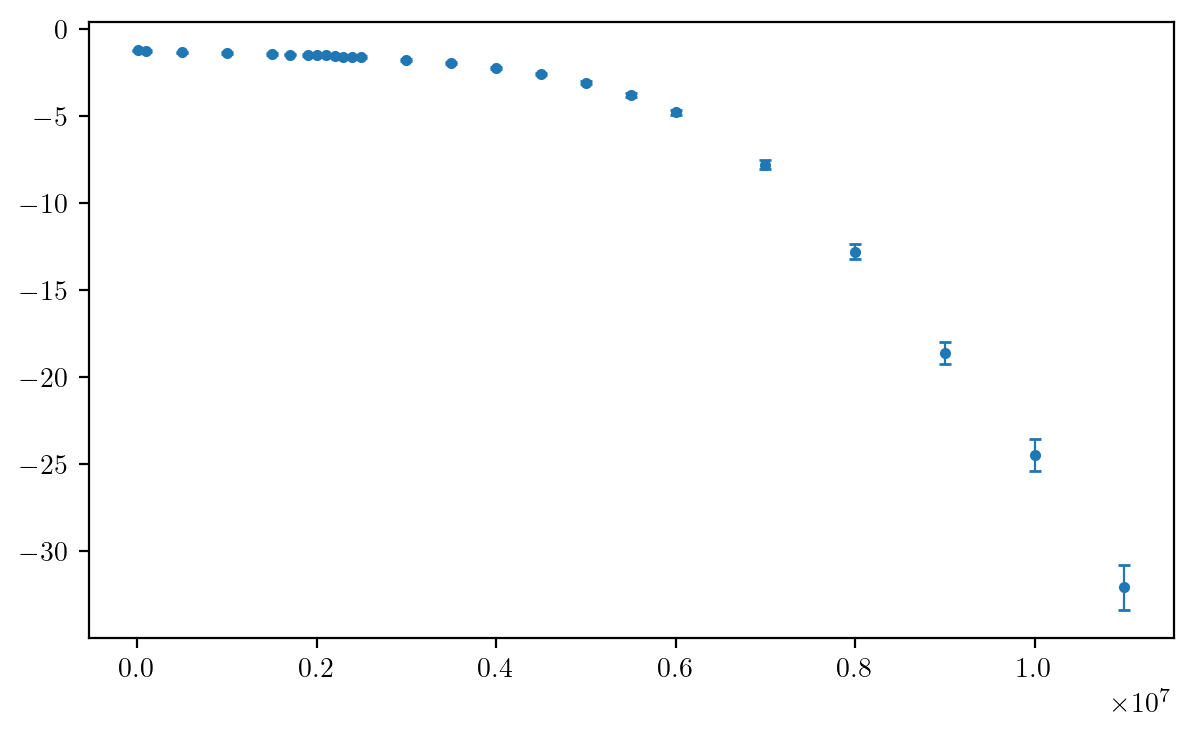

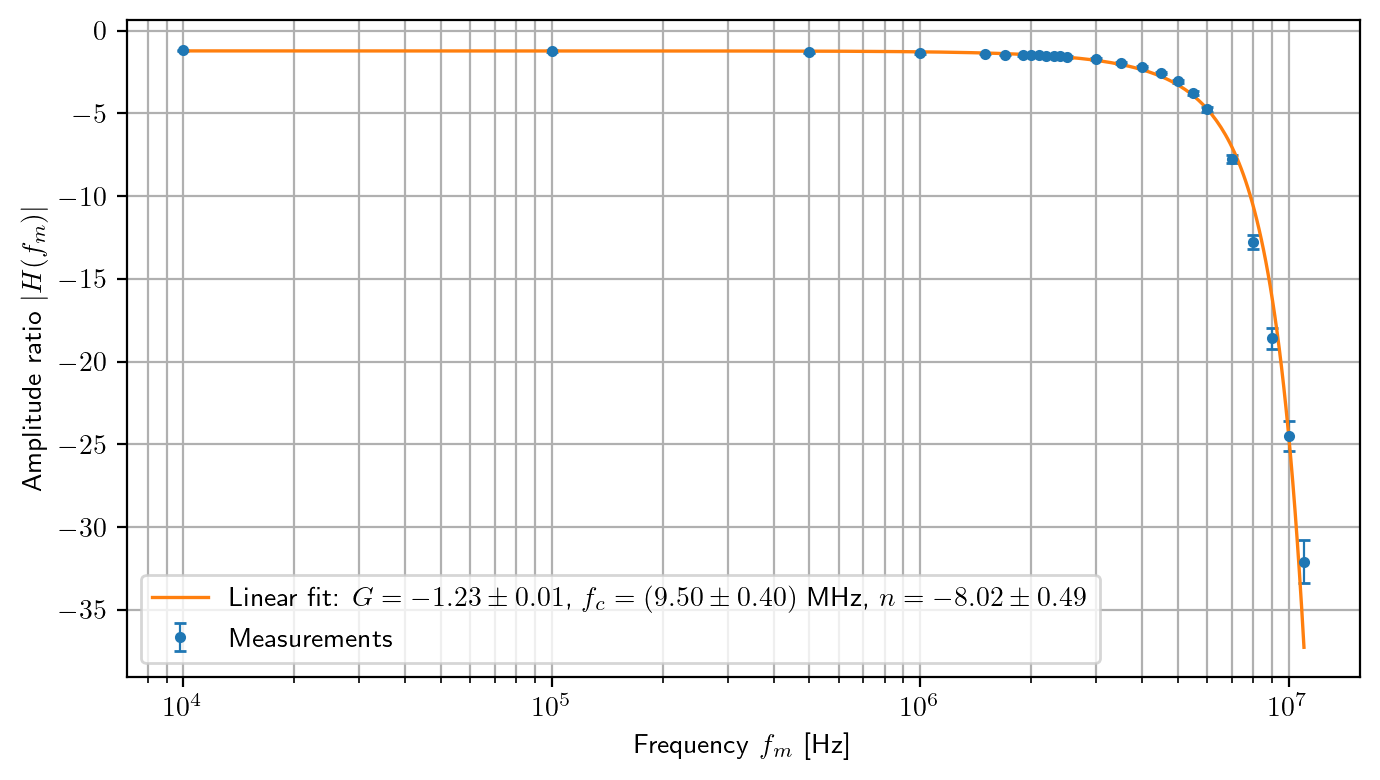

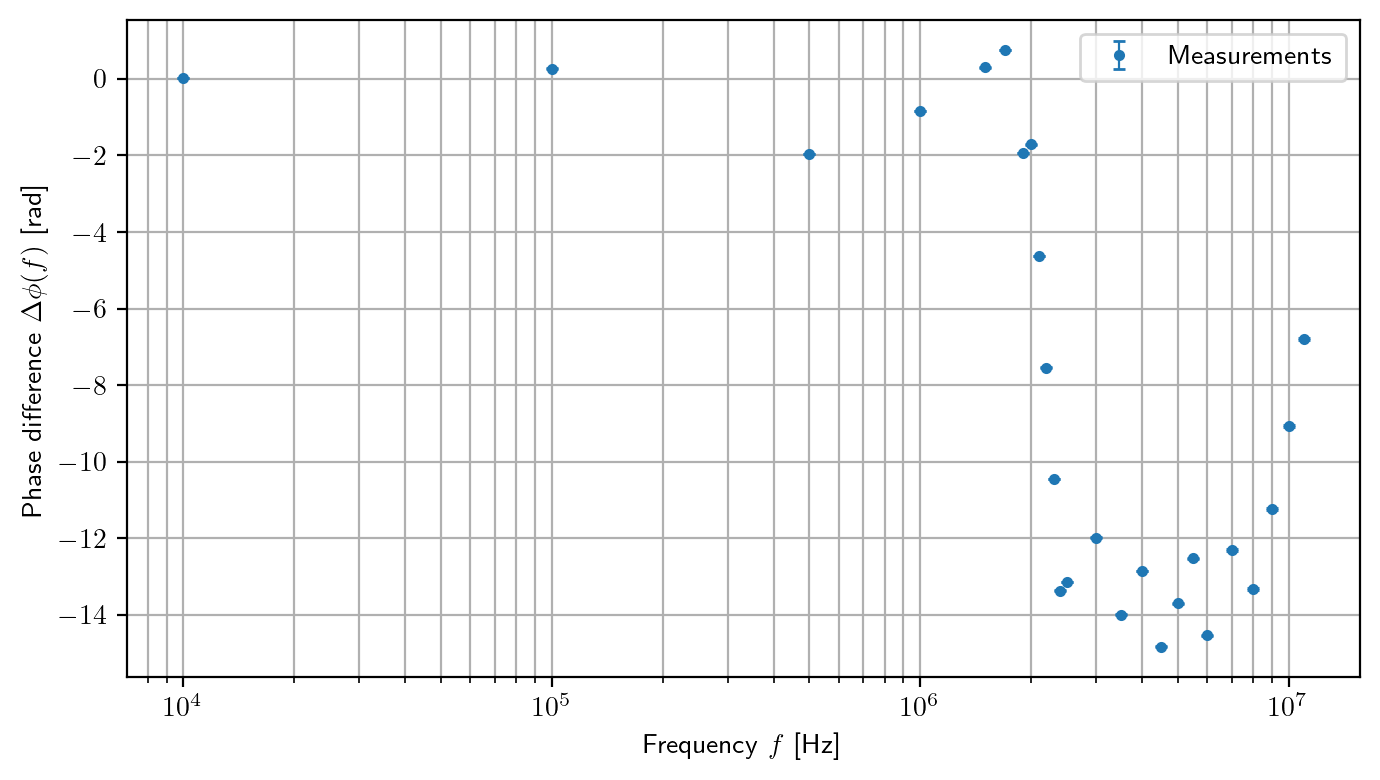

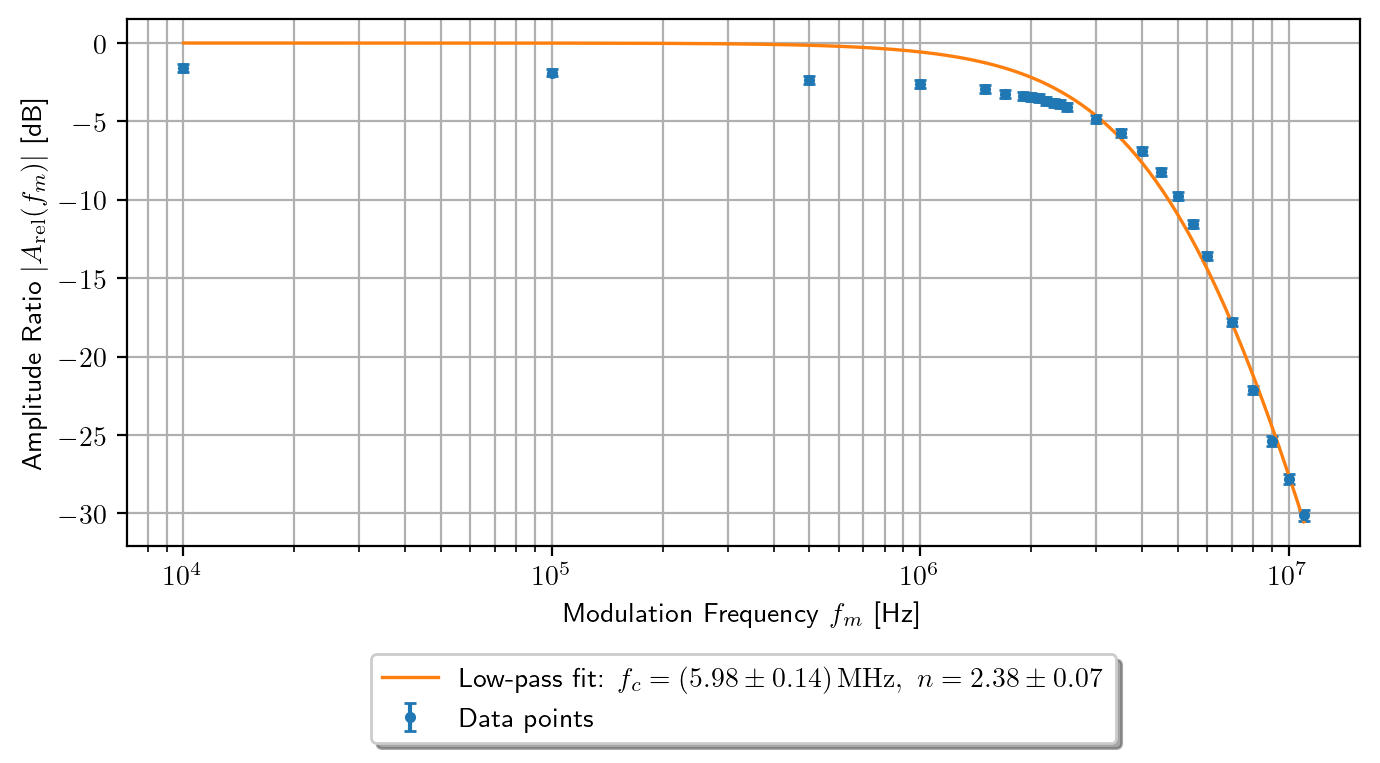

In [38]:
f = np.array(f_list, dtype=float)
H = np.array(Arel_list, dtype=float)
H_err = np.array(Arel_err_list, dtype=float)

idx = np.argsort(f)
f, H, H_err = f[idx], H[idx], H_err[idx]

def lowpass_linear(f, G, fc, n):
    return G / (1 + (f / fc)**2)**(n/2)

plt.figure(figsize=(7, 4), dpi=200)

plt.errorbar(
    f, H,
    yerr=H_err,
    fmt="o",
    markersize=3,
    elinewidth=0.8,
    capsize=2,
    label=r"Measurements"
)

# linear fit
p0_lin = [np.mean(H[:3]), 1e6, 2]   # Gain, fc, n

popt_lin, pcov_lin = curve_fit(
    lowpass_linear,
    f,
    H,
    p0=p0_lin,
    sigma=H_err,
    absolute_sigma=True
)

G_fit, fc_fit_lin, n_fit_lin = popt_lin
G_err, fc_err_lin, n_err_lin = np.sqrt(np.diag(pcov_lin))


f_fit = np.logspace(np.log10(f.min()), np.log10(f.max()), 500)
H_fit_lin = lowpass_linear(f_fit, G_fit, fc_fit_lin, n_fit_lin)


plt.figure(figsize=(7, 4), dpi=200)

plt.errorbar(
    f, H,
    yerr=H_err,
    fmt="o",
    markersize=3,
    elinewidth=0.8,
    capsize=2,
    label="Measurements"
)

plt.plot(
    f_fit, H_fit_lin,
    "-",
    linewidth=1.2,
    label=(
        rf"Linear fit: $G={G_fit:.2f}\pm{G_err:.2f}$, "
        rf"$f_c=({fc_fit_lin/1e6:.2f}\pm{fc_err_lin/1e6:.2f})$ MHz, "
        rf"$n={n_fit_lin:.2f}\pm{n_err_lin:.2f}$"
    )
)

plt.xscale("log")
plt.xlabel(r"Frequency $f_m$ [Hz]")
plt.ylabel(r"Amplitude ratio $|H(f_m)|$")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.savefig("Bode_amplitude_ratio_linear_with_fit.pdf", bbox_inches="tight")
plt.show()



phi = np.array(phi_list, dtype=float)
phi_err = np.array(phi_err_list, dtype=float)

phi, phi_err = phi[idx], phi_err[idx]

# unwrapping
phi_unwrapped = np.unwrap(phi) 

plt.figure(figsize=(7, 4), dpi=200)

plt.errorbar(
    f, phi_unwrapped,
    yerr=phi_err,
    fmt="o",
    markersize=3,
    elinewidth=0.8,
    capsize=2,
    label=r"Measurements"
)

plt.xscale("log")
plt.xlabel(r"Frequency $f$ [Hz]")
plt.ylabel(r"Phase difference $\Delta\phi(f)$ [rad]")
plt.grid(True, which="both")
plt.legend()

plt.tight_layout()
plt.savefig("Bode_phase_difference.pdf", bbox_inches="tight")
plt.show()

H_to_dB = H * -1
H_dB = 20*np.log10(H_to_dB)
H_dB_err = (20/np.log(10))*(H_err/H_to_dB)
H_dB = H_dB * -1

def lowpass_dB(f, fc, n):
    return -20 * n * np.log10(1 + (f / fc)**2)

from scipy.optimize import curve_fit


p0 = [1e6, 2]   

popt, pcov = curve_fit(
    lowpass_dB,
    f,
    H_dB,
    p0=p0,
    sigma=H_dB_err,
    absolute_sigma=True
)

fc_fit, n_fit = popt
fc_err, n_err = np.sqrt(np.diag(pcov))

f_fit = np.logspace(np.log10(f.min()), np.log10(f.max()), 500)
H_dB_fit = lowpass_dB(f_fit, fc_fit, n_fit)

plt.figure(figsize=(7,4), dpi=200)

plt.errorbar(
    f, H_dB,
    yerr=H_dB_err,
    fmt=".", capsize=2,
    label="Data points"
)

plt.plot(
    f_fit, H_dB_fit,
    "-", linewidth=1.2,
    label=rf"Low-pass fit: $f_c = ({fc_fit/1e6:.2f}\pm{fc_err/1e6:.2f})\,\mathrm{{MHz}},\ n = {n_fit:.2f}\pm{n_err:.2f}$"
)

plt.xscale("log")
plt.xlabel(r"Modulation Frequency $f_m$ [Hz]")
plt.ylabel(r"Amplitude Ratio $|A_\mathrm{rel}(f_m)|$ [dB]")
plt.grid(True, which="both")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    fancybox=True,
    shadow=True,
    ncol=1
)

plt.tight_layout()
plt.savefig("Bode_magnitude_dB.pdf", bbox_inches="tight")
plt.show()



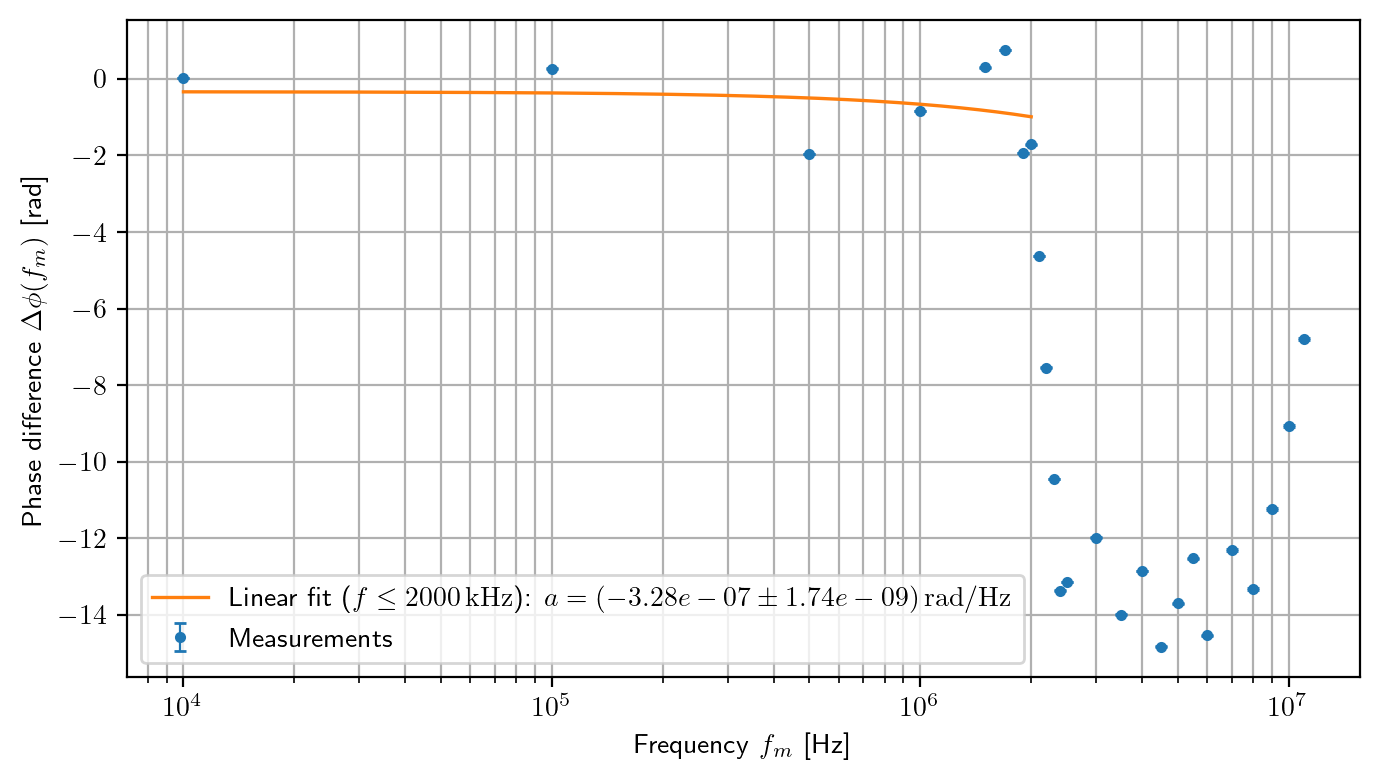

===== PHASE FIT RESULTS =====
a   = (-3.277e-07 ± 1.743e-09) rad/Hz
tau   = (52.16 ± 0.28) ns


In [39]:
#preparing data
f = np.array(f_list, dtype=float)
phi = np.array(phi_list, dtype=float)
phi_err = np.array(phi_err_list, dtype=float)

idx = np.argsort(f)
f, phi, phi_err = f[idx], phi[idx], phi_err[idx]

#unwrapping
phi_unwrapped = np.unwrap(phi)

# chosing the linear area
f_max_linear = 20e5  # 800 kHz
mask = f <= f_max_linear

f_lin = f[mask]
phi_lin = phi_unwrapped[mask]
phi_err_lin = phi_err[mask]

# linear model
def linear_phase(f, a, b):
    return a * f + b


p0 = [ -1e-6, 0.0 ]   

popt, pcov = curve_fit(
    linear_phase,
    f_lin,
    phi_lin,
    p0=p0,
    sigma=phi_err_lin,
    absolute_sigma=True
)

a_fit, b_fit = popt
a_err, b_err = np.sqrt(np.diag(pcov))

# time delay
tau = abs(a_fit) / (2*np.pi)
tau_err = a_err / (2*np.pi)


f_fit = np.linspace(f_lin.min(), f_lin.max(), 500)
phi_fit = linear_phase(f_fit, a_fit, b_fit)

plt.figure(figsize=(7, 4), dpi=200)

plt.errorbar(
    f, phi_unwrapped,
    yerr=phi_err,
    fmt="o",
    markersize=3,
    elinewidth=0.8,
    capsize=2,
    label="Measurements"
)

plt.plot(
    f_fit, phi_fit,
    "-", linewidth=1.2,
    label=(
        rf"Linear fit ($f \le {f_max_linear/1e3:.0f}\,\mathrm{{kHz}}$): "
        rf"$a = ({a_fit:.2e}\pm{a_err:.2e})\,\mathrm{{rad/Hz}}$"
    )
)

plt.xscale("log")
plt.xlabel(r"Frequency $f_m$ [Hz]")
plt.ylabel(r"Phase difference $\Delta\phi(f_m)$ [rad]")
plt.grid(True, which="both")
plt.legend()

plt.tight_layout()
plt.savefig("Bode_phase_difference_with_linear_fit.pdf", bbox_inches="tight")
plt.show()


print("===== PHASE FIT RESULTS =====")
print(f"a   = ({a_fit:.3e} ± {a_err:.3e}) rad/Hz")
print(f"tau   = ({tau*1e9:.2f} ± {tau_err*1e9:.2f}) ns")
print("=============================")


### now the final one -> the one before was wrong

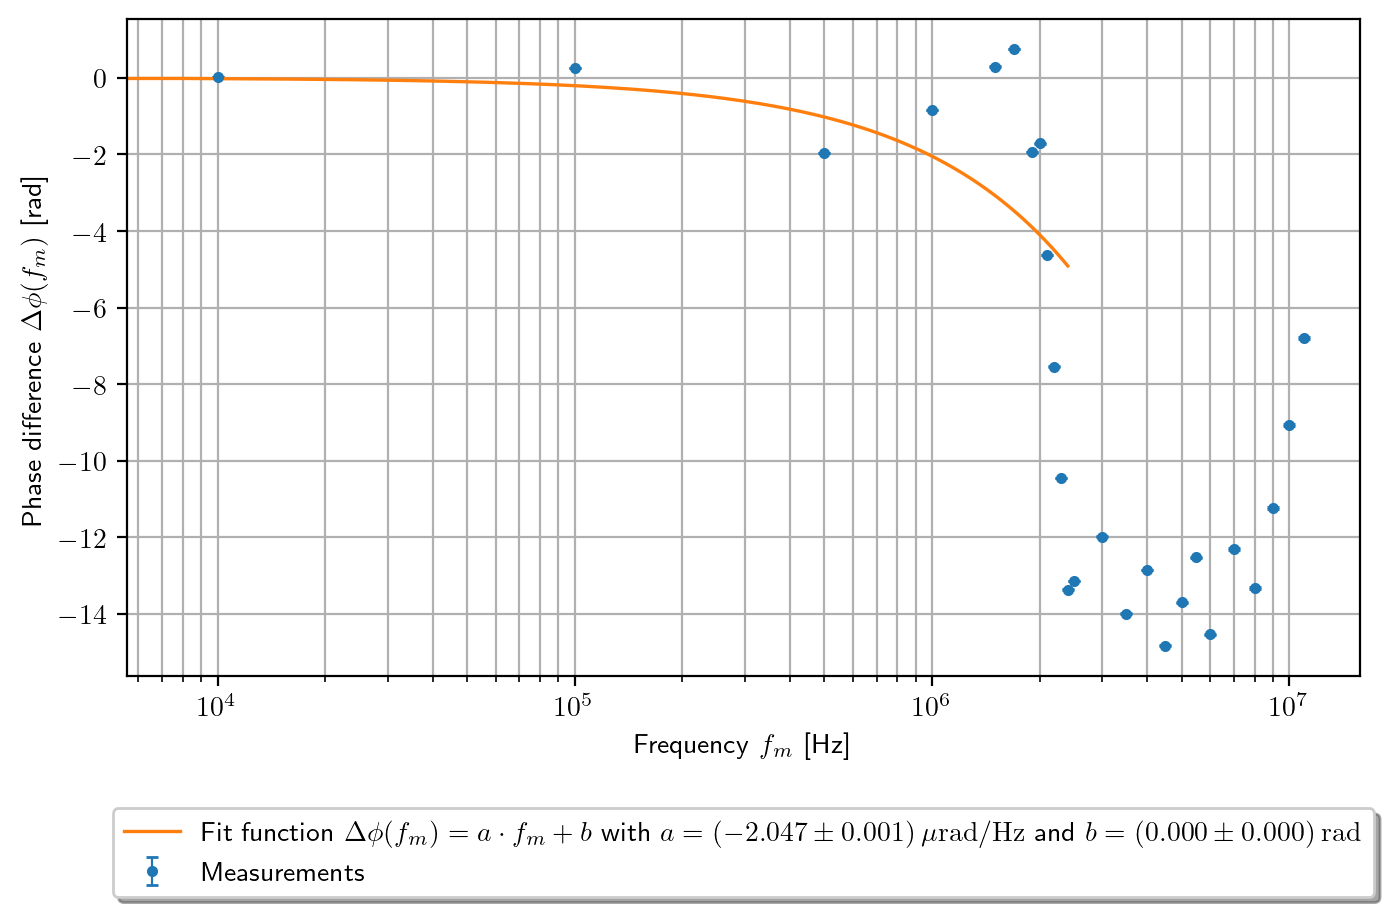

===== PHASE FIT RESULTS =====
0.0–2.4 MHz: a = (-2.047e-06 ± 8.909e-10) rad/Hz, tau = (325.8 ± 0.1) ns


In [42]:
# preparing data
f = np.array(f_list, dtype=float)
phi = np.array(phi_list, dtype=float)
phi_err = np.array(phi_err_list, dtype=float)

idx = np.argsort(f)
f, phi, phi_err = f[idx], phi[idx], phi_err[idx]


phi_unwrapped = np.unwrap(phi)


def linear_phase(f, a, b):
    return a * f + b

def linear_phase_free(f, a, b):
    return a * f + b

def linear_phase_zero(f, a):
    return a * f


ranges = [
    (0.0, 2.4e6),  
]

colors = ["C1", "C2", "C3"]
fit_results = []

for i, ((fmin, fmax), color) in enumerate(zip(ranges, colors)):

    mask = (f >= fmin) & (f <= fmax)
    f_lin = f[mask]
    phi_lin = phi_unwrapped[mask]
    phi_err_lin = phi_err[mask]

    if len(f_lin) < 3:
        fit_results.append(None)
        continue

    if i == 0:
        p0 = [-1e-6]
        popt, pcov = curve_fit(
            linear_phase_zero,
            f_lin,
            phi_lin,
            p0=p0,
            sigma=phi_err_lin,
            absolute_sigma=True
        )

        a_fit = popt[0]
        a_err = np.sqrt(pcov[0, 0])
        b_fit = 0.0
        b_err = 0.0

    else:
        p0 = [-1e-6, 0.0]
        popt, pcov = curve_fit(
            linear_phase_free,
            f_lin,
            phi_lin,
            p0=p0,
            sigma=phi_err_lin,
            absolute_sigma=True
        )

        a_fit, b_fit = popt
        a_err, b_err = np.sqrt(np.diag(pcov))

    tau = abs(a_fit) / (2*np.pi)
    tau_err = a_err / (2*np.pi)

    fit_results.append((fmin, fmax, a_fit, a_err, b_fit, b_err, tau, tau_err))

#fit_results = []

# -------------------------
# 5) Fits durchführen
# -------------------------
#for (fmin, fmax), color in zip(ranges, colors):

#    mask = (f >= fmin) & (f <= fmax)

#    f_lin = f[mask]
#    phi_lin = phi_unwrapped[mask]
#    phi_err_lin = phi_err[mask]

    # Sicherheit
#    if len(f_lin) < 3:
#        fit_results.append(None)
#        continue

#    p0 = [-1e-6, 0.0]

#    popt, pcov = curve_fit(
#        linear_phase,
#        f_lin,
#        phi_lin,
#        p0=p0,
#        sigma=phi_err_lin,
#        absolute_sigma=True
#    )

#    a_fit, b_fit = popt
#    a_err, b_err = np.sqrt(np.diag(pcov))

#    tau = abs(a_fit) / (2*np.pi)
#    tau_err = a_err / (2*np.pi)

#    fit_results.append((fmin, fmax, a_fit, a_err, tau, tau_err))


plt.figure(figsize=(7, 4), dpi=200)

plt.errorbar(
    f, phi_unwrapped,
    yerr=phi_err,
    fmt="o",
    markersize=3,
    elinewidth=0.8,
    capsize=2,
    label="Measurements"
)

for res, color in zip(fit_results, colors):
    if res is None:
        continue

    fmin, fmax, a_fit, a_err, b_fit, b_err, tau, tau_err = res

    f_plot = np.linspace(fmin, fmax, 300)

    if b_fit == 0.0:
        phi_plot = linear_phase_zero(f_plot, a_fit)
    else:
        phi_plot = linear_phase_free(f_plot, a_fit, b_fit)

    plt.plot(
        f_plot, phi_plot,
        "-", linewidth=1.2, color=color,
        label=rf"Fit function $\Delta \phi(f_m)=a \cdot f_m + b$ with $a = ({a_fit*1e6:.3f} \pm {a_err*1e6:.3f})\: \mathrm{{\mu rad/Hz}}$ and $b = ({b_fit:.3f} \pm {b_err:.3f})\:\mathrm{{rad}}$"
    )


plt.xscale("log")
plt.xlabel(r"Frequency $f_m$ [Hz]")
plt.ylabel(r"Phase difference $\Delta\phi(f_m)$ [rad]")
plt.grid(True, which="both")
#plt.legend()

plt.tight_layout()
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    fancybox=True,
    shadow=True,
    ncol=1
)
plt.savefig("Bode_phase_difference_three_linear_fits.pdf", bbox_inches="tight")
plt.show()


print("===== PHASE FIT RESULTS =====")
for res in fit_results:
    if res is None:
        continue
    fmin, fmax, a_fit, a_err, b_fit, b_err, tau, tau_err = res
    print(
        f"{fmin/1e6:.1f}–{fmax/1e6:.1f} MHz: "
        f"a = ({a_fit:.3e} ± {a_err:.3e}) rad/Hz, "
        f"tau = ({tau*1e9:.1f} ± {tau_err*1e9:.1f}) ns"
    )
print("=============================")


## Exercise 6: Modulated Rectangular Signal

Delay tau_rect = 0.373 µs
Rise time T_R = 132.9 ns
σ_tau ≈ 0.41 ns
σ_T_R ≈ 0.41 ns


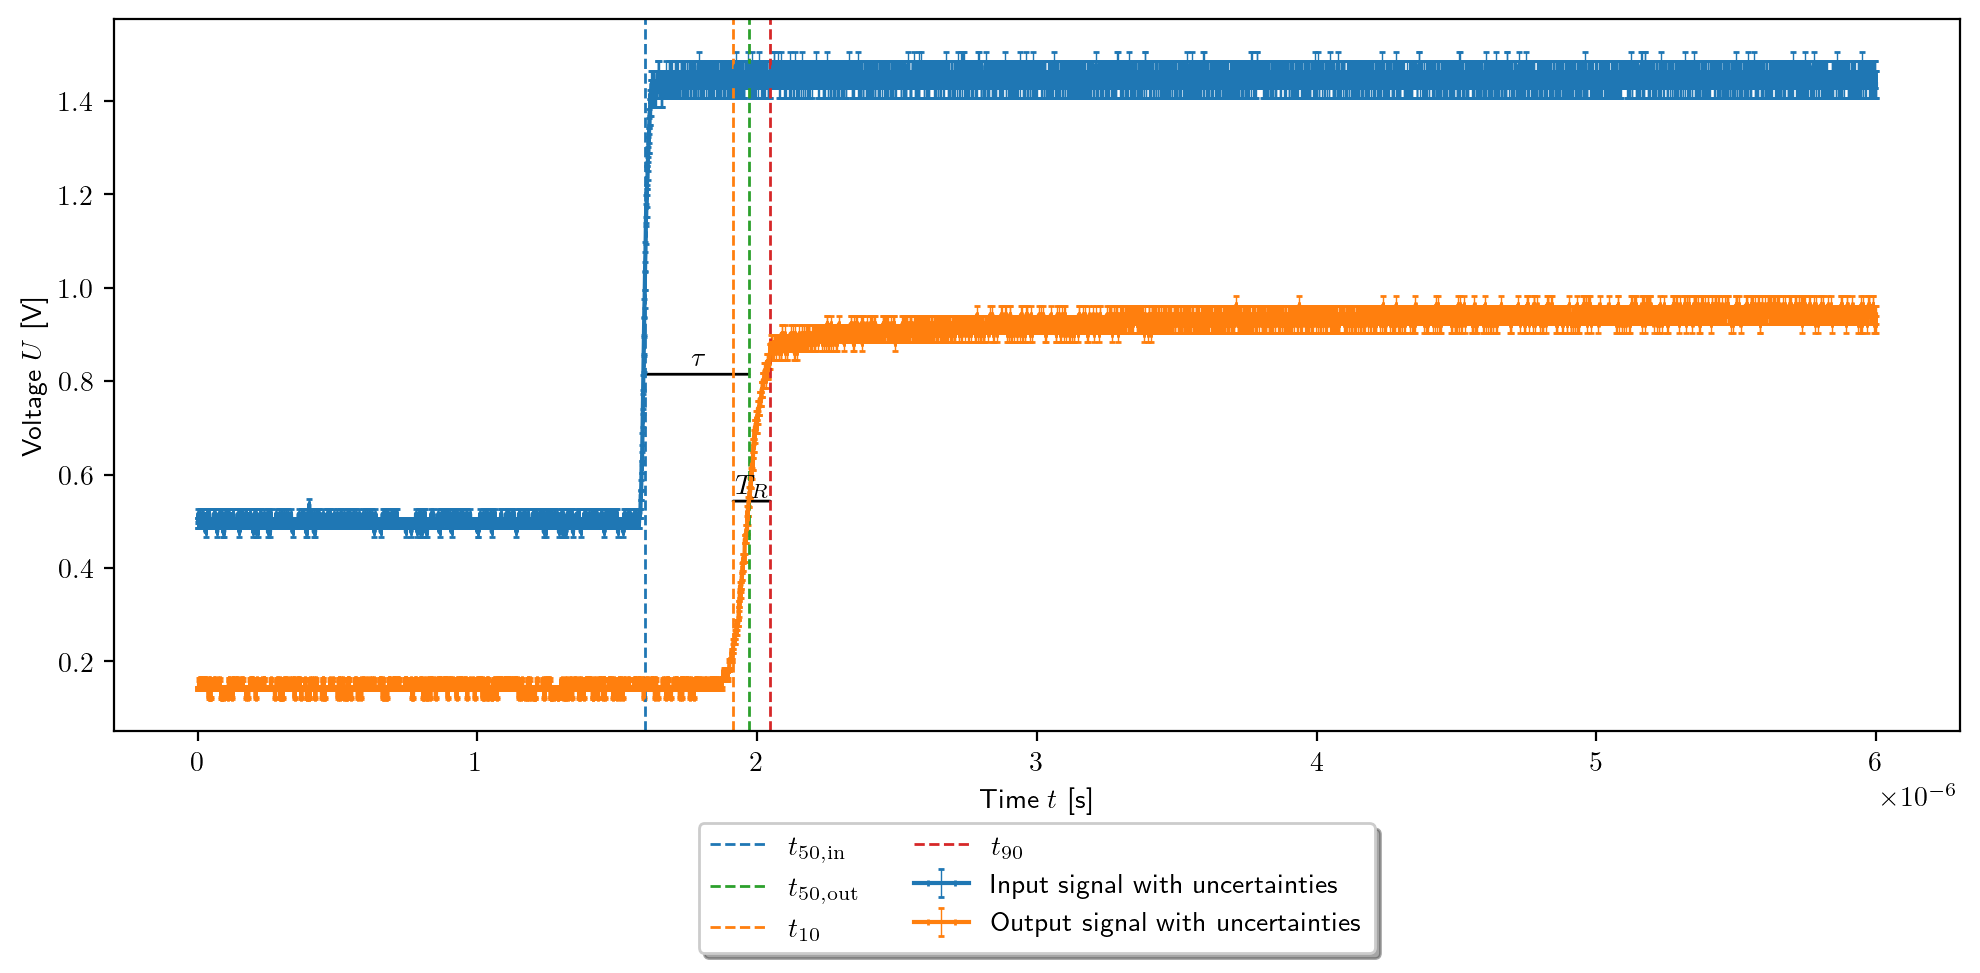

In [43]:
A6_CH1 = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/GROUP3/AOM_65.CSV" #insert path name, if code is reused please modify
data_CH1 = pd.read_csv(A6_CH1, header=None, skiprows=1, names=["time", "CH1"])
time_CH1 = data_CH1["time"]
time_CH1 = time_CH1 - time_CH1[0]
ch1 = data_CH1["CH1"]
time_err_CH1 = time_CH1 * 50e-6      # 50 ppm absolute
ch1_err = 0.02 * np.abs(ch1) 

A6_CH2 = "/Users/zarahaigner/Documents/Physik_Master_1/FP_2/AOM/AOM_66.CSV" #insert path name, if code is reused please modify
data_CH2 = pd.read_csv(A6_CH2, header=None, skiprows=1, names=["time", "CH1"])
time_CH2 = data_CH2["time"]
time_CH2 = time_CH2 - time_CH2[0]
ch2 = data_CH2["CH1"]
time_err_CH2 = time_CH2 * 50e-6    # 50 ppm absolute
ch2_err = 0.02 * np.abs(ch2) 

def find_threshold_time(time, signal, threshold):
    """
    Finds the time when 'signal' crosses 'threshold' (rising edge),
    using linear interpolation.
    """
    for i in range(len(signal) - 1):
        if signal[i] < threshold <= signal[i + 1]:
            # linear interpolation
            t1, t2 = time[i], time[i + 1]
            y1, y2 = signal[i], signal[i + 1]
            return t1 + (threshold - y1) * (t2 - t1) / (y2 - y1)
    return np.nan

def compute_levels(signal):
    U_low = np.mean(signal[:100])      
    U_high = np.mean(signal[-100:])    
    return U_low, U_high

# CH2 = reference (Input), CH1 = delayed signal (Output)


Ulow_2, Uhigh_2 = compute_levels(ch2)
Ulow_1, Uhigh_1 = compute_levels(ch1)


U50_2 = 0.5 * (Ulow_2 + Uhigh_2)
U50_1 = 0.5 * (Ulow_1 + Uhigh_1)

U10_1 = Ulow_1 + 0.1 * (Uhigh_1 - Ulow_1)
U90_1 = Ulow_1 + 0.9 * (Uhigh_1 - Ulow_1)


t50_2 = find_threshold_time(time_CH2, ch2, U50_2)
t50_1 = find_threshold_time(time_CH1, ch1, U50_1)

t10_1 = find_threshold_time(time_CH1, ch1, U10_1)
t90_1 = find_threshold_time(time_CH1, ch1, U90_1)


tau_rect = t50_1 - t50_2
TR_rect = t90_1 - t10_1

print(f"Delay tau_rect = {tau_rect*1e6:.3f} µs")
print(f"Rise time T_R = {TR_rect*1e9:.1f} ns")

dt_CH1 = np.mean(np.diff(time_CH1))
dt_CH2 = np.mean(np.diff(time_CH2))
dt = 0.5 * (dt_CH1 + dt_CH2)

sigma_tau = np.sqrt(2) * dt / np.sqrt(12)
sigma_TR = np.sqrt(2) * dt / np.sqrt(12)

print(f"σ_tau ≈ {sigma_tau*1e9:.2f} ns")
print(f"σ_T_R ≈ {sigma_TR*1e9:.2f} ns")


plt.figure(figsize=(10,5), dpi=200)

plt.errorbar(
    time_CH2,
    ch2,
    xerr=time_err_CH2,#
    yerr=ch2_err,
    #fmt='-',
    markersize=1,
    elinewidth=0.5,
    capsize=1,
    label=r"Input signal with uncertainties"
)
plt.errorbar(
    time_CH1,
    ch1,
    xerr=time_err_CH1,
    yerr=ch1_err,
    #fmt='-',
    markersize=1,
    elinewidth=0.5,
    capsize=1,
    label=r"Output signal with uncertainties"
)





plt.axvline(t50_2, color='C0', linestyle='--', linewidth=1, label=r'$t_{50,\mathrm{in}}$')
plt.axvline(t50_1, color='C2', linestyle='--', linewidth=1, label=r'$t_{50,\mathrm{out}}$')

plt.axvline(t10_1, color='C1', linestyle='--', linewidth=1, label=r'$t_{10}$')
plt.axvline(t90_1, color='C3', linestyle='--', linewidth=1, label=r'$t_{90}$')



from matplotlib.patches import FancyArrowPatch

def horizontal_arrow(x1, x2, y, label):
    arrow = FancyArrowPatch(
        (x1, y), (x2, y),
        arrowstyle='-',
        linewidth=1,
        color='k',
        shrinkA=0,
        shrinkB=0
    )
    plt.gca().add_patch(arrow)
    plt.text(
        0.5 * (x1 + x2),
        y * 1.01,
        label,
        ha='center',
        va='bottom',
        fontsize=10
    )

y_tau = U50_1 * 1.50   # 3 % höher
horizontal_arrow(t50_2, t50_1, y_tau, r'$\tau$')




# Rise time
y_TR = U10_1 + 0.5 * (U90_1 - U10_1)
horizontal_arrow(t10_1, t90_1, y_TR, r'$T_R$')




plt.xlabel(r"Time $t$ [s]")
#plt.xlim(10000,2000000)
plt.ylabel(r"Voltage $U$ [V]")
#plt.ylim(0.4,0.55)
#plt.xlim(0.2,1*10e5)#,2*10e5)
#plt.title("Signalverlauf")
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.11), fancybox=True, shadow=True, ncol=2)
plt.tight_layout()
plt.savefig("A6.pdf")
plt.show()